## Homework 5: Transfer Learning with MobileNetV2 on the Intel Image Dataset

**Due: Sunday, October 4, 2026, at 11:59 PM ET**

There is a grace period until **2:00 AM ET**. After that, late submissions are penalized **10% for each 24-hour period**. After **5 days**, the score is 0.

In this assignment, you will use a modern pretrained CNN, **MobileNetV2**, to classify the **Intel Image Dataset**, which contains 6 scene classes.

You will begin by using MobileNetV2 as a **frozen feature extractor**, training only a new classification head. You will then explore progressively more flexible transfer-learning strategies by making all or part of the pretrained backbone trainable.

To make experimentation practical, the notebook provides a `DATA_FRACTION` setting. During development, you may use a smaller fraction of the dataset to test ideas and compare configurations more quickly. Before recording your final results, set:

```python
DATA_FRACTION = 1.0
```

and rerun the complete notebook using the full dataset.

Because MobileNetV2 was pretrained on ImageNet, the images are processed using `mobilenet_v2.preprocess_input`, which scales the input pixels to the range expected by the pretrained network.

The goal is to understand **why transfer learning works**, how to design a useful **classification head**, and how choices such as **learning rate**, **learning-rate control with `ReduceLROnPlateau`**, **regularization**, and **which pretrained layers are allowed to change** affect model performance.

### Learning Objectives

By the end of this homework, you should be able to:

* Use a pretrained CNN as a **frozen feature extractor**.
* Design and compare different **classification heads** on top of a pretrained backbone.
* Experiment efficiently using a reduced dataset before running final models on the full dataset.
* Understand the difference between a **frozen backbone** and making some or all pretrained layers trainable.
* Use practical training controls including:

  * fixed **learning rates**,
  * `ReduceLROnPlateau`,
  * `EarlyStopping`,
  * **Dropout** and **L2 regularization**,
  * and **Batch Normalization** in classification heads.
* Compare strategies that make:

  * the **entire backbone** trainable,
  * only the **last N layers** trainable,
  * or only the **top K MobileNetV2 blocks** trainable.

### Baseline Model

The starting backbone is:

```python
MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

With `pooling="avg"`, MobileNetV2 already applies **Global Average Pooling** and outputs a **1280-dimensional feature vector** for each image.

The baseline classification head consists of a single:

```python
Dense(num_classes, activation="softmax")
```

layer for the 6 Intel classes.

**Do not add another pooling layer when `pooling="avg"` is used.**

### The Five Problems

1. **Problem 1 — Frozen Backbone:**
   Keep MobileNetV2 frozen and redesign only the **classification head**. Try at least three head designs and experiment with training hyperparameters.

2. **Problem 2 — Fully Trainable Backbone:**
   Use one of your best head architectures from Problem 1, make the **entire MobileNetV2 backbone trainable**, and experiment with appropriately small learning rates and other training choices.

3. **Problem 3 — Unfreeze the Last N Layers:**
   Keep most of MobileNetV2 frozen while allowing only the **last N layers** to be updated.

4. **Problem 4 — Unfreeze the Top K Blocks:**
   Instead of selecting individual layers, make only the **top K MobileNetV2 blocks or stages** trainable and compare the results.

5. **Problem 5 -- Final Reflection**

Use your **HW4 CNN results as a reference point**. Transfer learning may or may not outperform every model you developed in HW4; the important goal is to understand how the different transfer-learning strategies affect training behavior and model performance.



## 1. Setup and Data Loading


In [1]:
# -------- Standard library --------
import os
import time
import random
from collections import Counter

# Quiet TensorFlow logs (set BEFORE importing TF)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# -------- Third-party --------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

import tensorflow as tf
from tensorflow.keras import layers,models, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback,EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    GlobalMaxPooling2D,
    Input,
    MaxPooling2D,
    ReLU,
    SeparableConv2D,
)

from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.preprocessing.image import load_img, img_to_array



he = initializers.HeNormal()
l2reg = regularizers.l2(1e-4)

# Reproducibility settings
# -------------------------
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)

def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


### Utility function to plot learning curves and keep track of all results

- Call `print_results()` to see listing of all results logged so far

In [2]:

def plot_learning_curves(hist, title, verbose=True):
    
    val_losses = hist.history['val_loss']
    min_val_loss = min(val_losses)
    min_val_epoch = val_losses.index(min_val_loss)
    val_acc_at_min_loss = hist.history['val_accuracy'][min_val_epoch]

    epochs = range(1, len(val_losses) + 1)  # epoch numbers starting at 1

    fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    # --- Loss Plot ---
    axs[0].plot(epochs, hist.history['loss'], label='train loss')
    axs[0].plot(epochs, hist.history['val_loss'], label='val loss')
    axs[0].scatter(min_val_epoch + 1, min_val_loss, color='red', marker='x', s=50, label='min val loss')
    axs[0].set_title(f'{title} - Categorical Cross-Entropy Loss')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid(True)

    # --- Accuracy Plot ---
    axs[1].plot(epochs, hist.history['accuracy'], label='train acc')
    axs[1].plot(epochs, hist.history['val_accuracy'], label='val acc')
    axs[1].scatter(min_val_epoch + 1, val_acc_at_min_loss, color='red', marker='x', s=50, label='acc @ min val loss')
    axs[1].set_title(f'{title} - Accuracy')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    if verbose:
        print(f"Final Training Loss:            {hist.history['loss'][-1]:.4f}")
        print(f"Final Training Accuracy:        {hist.history['accuracy'][-1]:.4f}")
        print(f"Final Validation Loss:          {hist.history['val_loss'][-1]:.4f}")
        print(f"Final Validation Accuracy:      {hist.history['val_accuracy'][-1]:.4f}")
        print(f"Minimum Validation Loss:        {min_val_loss:.4f} (Epoch {min_val_epoch + 1})")
        print(f"Validation Accuracy @ Min Loss: {val_acc_at_min_loss:.4f}")

    results[title] = (val_acc_at_min_loss,min_val_epoch + 1)

results = {}

def print_results():
    for title, (acc, ep) in sorted(results.items(), 
                                   key=lambda kv: kv[1][0],   # kv[1] is (acc, epoch); [0] is acc
                                   reverse=True
                                  ):
        print(f"{title:<40}\t{acc:.4f}\t{ep}")

###  Wrapper for training and testing

#### Assumptions:   
- Early stopping is default, add other callbacks as needed
- Training and testing sets already defined, accessed here as global variables

In [3]:
# Uses globals: train_ds, val_ds, test_ds

def train_and_test(model, 
                   epochs=500,
                   lr_schedule=1e-3,
                   optimizer="Adam",
                   title="Learning Curves",
                   batch_size=64,  # kept for API compatibility; ignored if datasets are batched
                   use_early_stopping=True,
                   patience=8,
                   min_delta=1e-4,
                   callbacks=None,
                   verbose=1,
                   return_history=False):

    print(f"\n{title}\n")

    # Choose optimizer
    if optimizer == "Adam":
        opt = Adam(learning_rate=lr_schedule)
    else:
        opt = optimizer  # assume already an optimizer instance

    # Compile
    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=patience,
        min_delta=min_delta,
        restore_best_weights=True,
        verbose=verbose
    )

    extra_cbs = callbacks or []
    cbs = ([early_stop] if use_early_stopping else []) + extra_cbs

    start = time.time()

    history = model.fit(
        train_ds,
        epochs=epochs,
        validation_data=val_ds,
        callbacks=cbs,
        verbose=verbose
    )

    # Best epoch consistent with EarlyStopping monitor
    best_epoch = int(np.argmin(history.history["val_loss"]))
    best_acc   = history.history["val_accuracy"][best_epoch]

    plot_learning_curves(history, title=title)

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    print(f"\nTest Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(f"\nValidation-Test Gap (accuracy): {abs(best_acc - test_accuracy):.6f}")

    end = time.time()
    print(f"\nExecution Time: " + format_hms(end - start))

    if return_history:
        return history


### Load the Intel Image Classification Dataset  



In [4]:
path      = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, "seg_train/seg_train")
test_dir  = os.path.join(path, "seg_test/seg_test")

In [5]:
# --------------------------------------------------
# DATASET SIZE
#
# For faster experimentation on a slower computer,
# you may reduce DATA_FRACTION (for example, to 0.25).
#
# IMPORTANT: Set DATA_FRACTION = 1.0 and rerun the
# complete notebook before recording your final results.
# --------------------------------------------------

DATA_FRACTION = 1.0

AUTOTUNE = tf.data.AUTOTUNE

def stratified_subsample(filepaths, labels, fraction=1.0, seed=42):
    """
    Keep the same fraction of examples from each class.
    fraction=1.0 uses the complete dataset.
    """
    if fraction >= 1.0:
        return filepaths, labels

    rng = np.random.default_rng(seed)

    keep_idx = []

    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        rng.shuffle(idx)

        n_keep = max(1, int(len(idx) * fraction))
        keep_idx.extend(idx[:n_keep])

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)

    return filepaths[keep_idx], labels[keep_idx]

def list_files_and_labels(directory, class_names=None, exts=(".jpg", ".jpeg", ".png")):
    """
    Returns:
      filepaths: np.array[str]
      labels:    np.array[int32]
      class_names_used: list[str] in deterministic order
    """
    if class_names is None:
        class_names = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
    else:
        # keep only classes that exist in this directory, preserve given order
        class_names = [c for c in class_names if os.path.isdir(os.path.join(directory, c))]

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    filepaths = []
    labels = []

    for cname in class_names:
        folder = os.path.join(directory, cname)
        for fname in sorted(os.listdir(folder)):  # deterministic within class
            if fname.lower().endswith(exts):
                filepaths.append(os.path.join(folder, fname))
                labels.append(class_to_idx[cname])

    return np.array(filepaths), np.array(labels, dtype=np.int32), class_names


def stratified_split_indices(y, val_frac=0.2, seed=42):
    """
    Deterministic stratified split over indices.
    Returns: train_idx, val_idx (np arrays)
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    n = len(y)

    train_idx_list = []
    val_idx_list = []

    classes = np.unique(y)
    for c in classes:
        idx = np.flatnonzero(y == c)
        rng.shuffle(idx)
        n_val = int(np.floor(len(idx) * val_frac))
        val_idx_list.append(idx[:n_val])
        train_idx_list.append(idx[n_val:])

    train_idx = np.concatenate(train_idx_list)
    val_idx = np.concatenate(val_idx_list)

    # Optional: shuffle each split deterministically so batches mix classes
    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return train_idx, val_idx


def make_image_dataset(filepaths, labels, img_size=(150, 150), batch_size=32,
                       shuffle=False, seed=42, cache_to_disk=None):
    """
    Builds a tf.data.Dataset that loads images lazily from disk.
    - filepaths: np array of strings
    - labels:    np array of int32
    """
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        # shuffle file *references* (cheap), not image tensors
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed, reshuffle_each_iteration=True)

    def _load_and_preprocess(path, label):
        # read bytes -> decode -> resize -> float32 -> MobileNetV2 preprocessing
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.image.resize(img, img_size, method="bilinear")
        img = tf.cast(img, tf.float32)
        img = preprocess_input(img)
        return img, label

    ds = ds.map(_load_and_preprocess, num_parallel_calls=AUTOTUNE)

    if cache_to_disk is not None:
        # Disk caching avoids RAM blowups; /tmp is fine in Colab
        ds = ds.cache(cache_to_disk)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


# -------------------------
# Example usage for Intel dataset
# -------------------------

IMG_SIZE      = (150, 150)
INPUT_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE    = 32
VAL_FRAC      = 0.2
SEED          = random_seed  # use your existing seed


# 1) List train files/labels deterministically
train_files, train_labels, class_names = list_files_and_labels(train_dir)

num_classes = len(class_names)

# Optional: use a smaller stratified subset while developing/debugging
train_files, train_labels = stratified_subsample(
    train_files,
    train_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

# 2) Stratified deterministic train/validation split
train_idx, val_idx = stratified_split_indices(
    train_labels,
    val_frac=VAL_FRAC,
    seed=SEED,
)

# 3) Slice file lists
files_train = train_files[train_idx]
y_train     = train_labels[train_idx]

files_val   = train_files[val_idx]
y_val       = train_labels[val_idx]

# 4) Build datasets
train_ds = make_image_dataset(
    files_train,
    y_train,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    cache_to_disk=None,
)

val_ds = make_image_dataset(
    files_val,
    y_val,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)

# 5) Test set
test_files, test_labels, _ = list_files_and_labels(
    test_dir,
    class_names=class_names,
)

# Use the same fraction for quick development runs
test_files, test_labels = stratified_subsample(
    test_files,
    test_labels,
    fraction=DATA_FRACTION,
    seed=SEED,
)

test_ds = make_image_dataset(
    test_files,
    test_labels,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    cache_to_disk=None,
)



### Examine The Dataset

In [6]:

def show_counts_from_labels(name, labels, class_names):
    c = Counter(labels.tolist())
    counts = {class_names[k]: c.get(k, 0) for k in range(len(class_names))}
    print(f"{name} per-class counts:", counts)

print("class_names:", class_names)
print("train examples:", len(files_train), "val examples:", len(files_val), "test examples:", len(test_files))

show_counts_from_labels("train", y_train, class_names)
show_counts_from_labels("val",   y_val,   class_names)
show_counts_from_labels("test",  test_labels, class_names)


class_names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
train examples: 11230 val examples: 2804 test examples: 3000
train per-class counts: {'buildings': 1753, 'forest': 1817, 'glacier': 1924, 'mountain': 2010, 'sea': 1820, 'street': 1906}
val per-class counts: {'buildings': 438, 'forest': 454, 'glacier': 480, 'mountain': 502, 'sea': 454, 'street': 476}
test per-class counts: {'buildings': 437, 'forest': 474, 'glacier': 553, 'mountain': 525, 'sea': 510, 'street': 501}


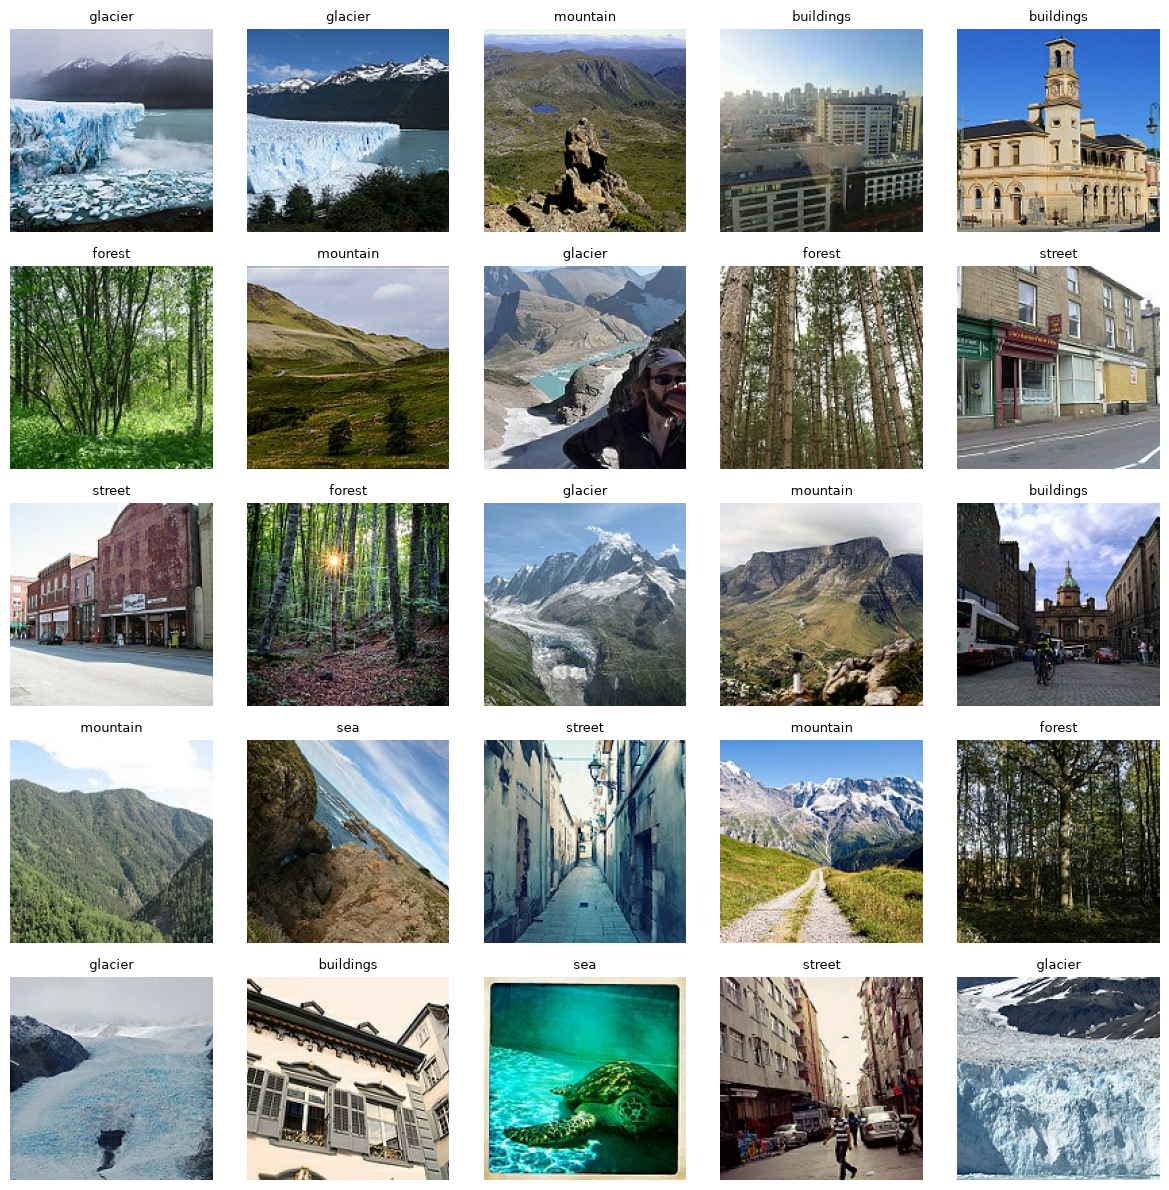

In [7]:
# Show 25 sample images

plt.figure(figsize=(12, 12))

images, labels = next(iter(train_ds))

for i in range(25):
    ax = plt.subplot(5, 5, i + 1)

    # Convert MobileNetV2 [-1, 1] values back to [0, 1] for display
    img = (images[i].numpy() + 1.0) / 2.0

    plt.imshow(img)
    plt.title(class_names[int(labels[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


### Learning Rate Schedulers

In [8]:
# Must be input as callback in train_and_test(....   , callbacks=[reduce_lr] )

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # Quantity to be monitored.
    factor=0.5,            # Factor by which the learning rate will be reduced.
                           # new_lr = lr * factor
    patience=3,            # Number of epochs with no improvement
                           # after which learning rate will be reduced.
    min_delta=1e-4,        # Threshold for measuring the new optimum,
                           # to only focus on significant changes.
    cooldown=0,            # Number of epochs to wait before resuming
                           # normal operation after lr has been reduced.
    min_lr=1e-7,           # Lower bound on the learning rate.
    verbose=1,             # 0: quiet, 1: update messages.
)

### Prelude: Baseline Model

`MobileNetV2` is a lightweight CNN pretrained on the ImageNet dataset. We will use it as a source of high-quality visual features rather than training a convolutional network from scratch.

See the **Appendix** for additional information about `MobileNetV2`.

The baseline model defined below uses `MobileNetV2` as a frozen **feature extractor**. With `include_top=False` and built-in **Global Average Pooling**, the backbone produces a 1280-dimensional feature vector for each image.

The images have already been processed using `mobilenet_v2.preprocess_input`, which scales the pixel values to the range expected by the pretrained MobileNetV2 weights.

> **NOTE:** The standard MobileNetV2 ImageNet weights are associated with 224×224 images. We use 150×150 images to reduce training time. This is valid because, with `include_top=False`, the convolutional backbone can operate on different input image sizes.
>
> Keras may therefore issue a warning such as:
>
> `UserWarning: input_shape is undefined or non-square, ...`
>
> You may safely ignore this warning for this assignment.


In [9]:
# ALWAYS construct a new instance to avoid sharing layers across models.

def make_base_model_pooled(trainable=False):
    base = mobilenet_v2.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=INPUT_SHAPE,
        pooling="avg",
    )
    base.trainable = trainable
    return base


base = make_base_model_pooled()

print("Some statistics on the model:")
print("Total Keras layers:", len(base.layers))

# Count unique inverted-residual blocks by their prefix 'block_<n>'
block_ids = sorted({
    int(layer.name.split("_")[1])
    for layer in base.layers
    if layer.name.startswith("block_")
})
print("Conv Block IDs:", block_ids, "(count:", len(block_ids), ")")

# Check whether the final Conv_1 stage exists
has_conv1 = any(
    layer.name.startswith("Conv_1")
    for layer in base.layers
)

print("Has Conv_1 stage:", has_conv1)
print("Model Output Shape:", base.output_shape)

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(


Some statistics on the model:
Total Keras layers: 155
Conv Block IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16] (count: 16 )
Has Conv_1 stage: True
Model Output Shape: (None, 1280)


In [10]:
# Ha, this is very long!

base.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



Model Baseline

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.8598 - loss: 0.3854 - val_accuracy: 0.8891 - val_loss: 0.2995
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9102 - loss: 0.2484 - val_accuracy: 0.8991 - val_loss: 0.2758
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9209 - loss: 0.2142 - val_accuracy: 0.8919 - val_loss: 0.2996
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9292 - loss: 0.1938 - val_accuracy: 0.9012 - val_loss: 0.2793
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9349 - loss: 0.1765 - val_accuracy: 0.8791 - val_loss: 0.3571
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9379 - loss: 0.1655 - val_accuracy: 0.8969 - val_loss: 0.3018
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9417 - loss: 0.1542 - val_accuracy: 0.8916 - val_loss: 0.3050
Epoch 8/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9459 - loss: 0.1444 - val_accurac

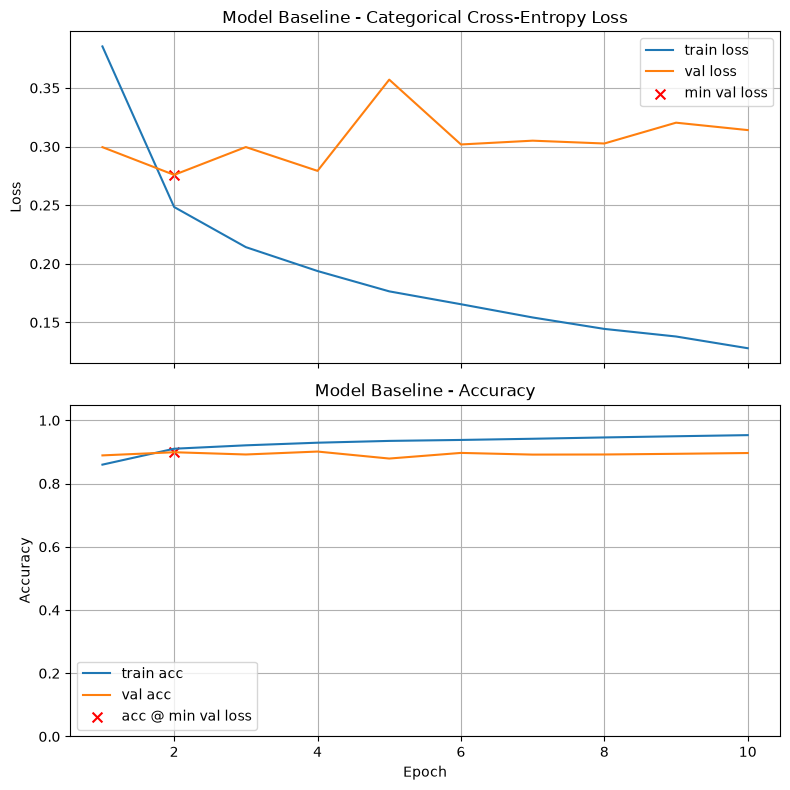

Final Training Loss:            0.1280
Final Training Accuracy:        0.9532
Final Validation Loss:          0.3141
Final Validation Accuracy:      0.8966
Minimum Validation Loss:        0.2758 (Epoch 2)
Validation Accuracy @ Min Loss: 0.8991

Test Loss: 0.2627
Test Accuracy: 0.9023

Validation-Test Gap (accuracy): 0.003261

Execution Time: 00:01:23


In [11]:
# Construct a fresh frozen MobileNetV2 backbone

base_model = make_base_model_pooled()

model_baseline = models.Sequential([
    base_model,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_baseline, title="Model Baseline")

### Problem 1 — Frozen MobileNetV2 (Feature Extractor): Redesign the Head

**Goal.** Keep the MobileNetV2 backbone **frozen** and try to improve accuracy by modifying **only the classification head**.

**Setup.**

```python
base = make_base_model_pooled(
    trainable=False
)  # MobileNetV2(include_top=False, pooling="avg")
```

This backbone already applies **Global Average Pooling** and outputs a **1280-D feature vector** for each image.

Do **not** unfreeze any backbone layers, and do **not** add another pooling layer.

### To Do

1. **Ask an AI helper** (e.g., ChatGPT):

   *“What are some more complex classification heads that could improve this model on the Intel Image Classification Dataset, without unfreezing the MobileNetV2 backbone?”*

2. **Implement at least three different head designs.** These may be AI-suggested or inspired by techniques used in HW4.

3. **Experiment with hyperparameters** for the different designs, such as:

   * learning rate
   * `EarlyStopping` settings
   * Dropout and/or L2 regularization
   * `ReduceLROnPlateau` on or off

4. **Train and compare** the three head designs using a reduced value of `DATA_FRACTION`.

   Use these runs to compare architectures and training behavior and to narrow down a reasonable final configuration.

5. **Select one configuration**, set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this full-data run when answering the graded questions.

6. **Answer the graded questions.**

### Notes / Constraints

* With `pooling="avg"`, the backbone output has shape **(None, 1280)**, so **do not add `GlobalAveragePooling2D()`** to the head.
* `BatchNormalization` may be used within the classification head.
* Keep the entire MobileNetV2 backbone frozen for all experiments in this problem.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.



/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.8726 - loss: 0.4136 - val_accuracy: 0.8927 - val_loss: 0.3393 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9168 - loss: 0.2824 - val_accuracy: 0.9062 - val_loss: 0.3167 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9313 - loss: 0.2424 - val_accuracy: 0.9069 - val_loss: 0.3270 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9402 - loss: 0.2218 - val_accuracy: 0.8944 - val_loss: 0.3452 - learning_rate: 0.0010
Epoch 5/500
349/351 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9470 - loss: 0.1997
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9469 - loss: 0.2000 - val_accuracy: 0.8934 - val_loss: 0.3573 - learning_rate: 0.0010
Epoch

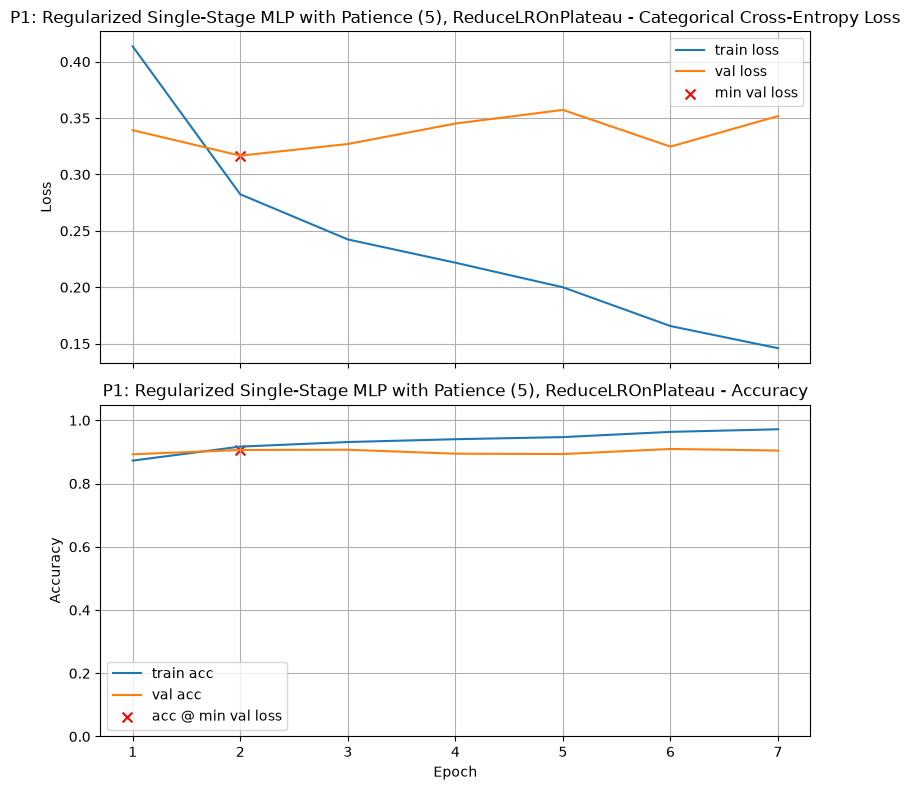

Final Training Loss:            0.1459
Final Training Accuracy:        0.9717
Final Validation Loss:          0.3518
Final Validation Accuracy:      0.9044
Minimum Validation Loss:        0.3167 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9062

Test Loss: 0.2863
Test Accuracy: 0.9107

Validation-Test Gap (accuracy): 0.004461

Execution Time: 00:01:09


In [12]:
# Construct a fresh frozen MobileNetV2 backbone

base_model1 = make_base_model_pooled()

model_reg_single_stage_MLP = models.Sequential([
    base_model1,
    Dense(256, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.35),
    Dense(num_classes, activation='softmax', kernel_regularizer=l2reg)  # use your Intel num_classes (6)
])

train_and_test(model_reg_single_stage_MLP, patience=5, callbacks=[reduce_lr], title="P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.8482 - loss: 0.5595 - val_accuracy: 0.9069 - val_loss: 0.3986 - learning_rate: 5.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9048 - loss: 0.3980 - val_accuracy: 0.9105 - val_loss: 0.3785 - learning_rate: 5.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9147 - loss: 0.3531 - val_accuracy: 0.9019 - val_loss: 0.3800 - learning_rate: 5.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9297 - loss: 0.3135 - val_accuracy: 0.9073 - val_loss: 0.3871 - learning_rate: 5.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9374 - loss: 0.2933
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9374 - loss: 0.2933 - val_accuracy: 0.9012 - val_loss: 0.3932 - le

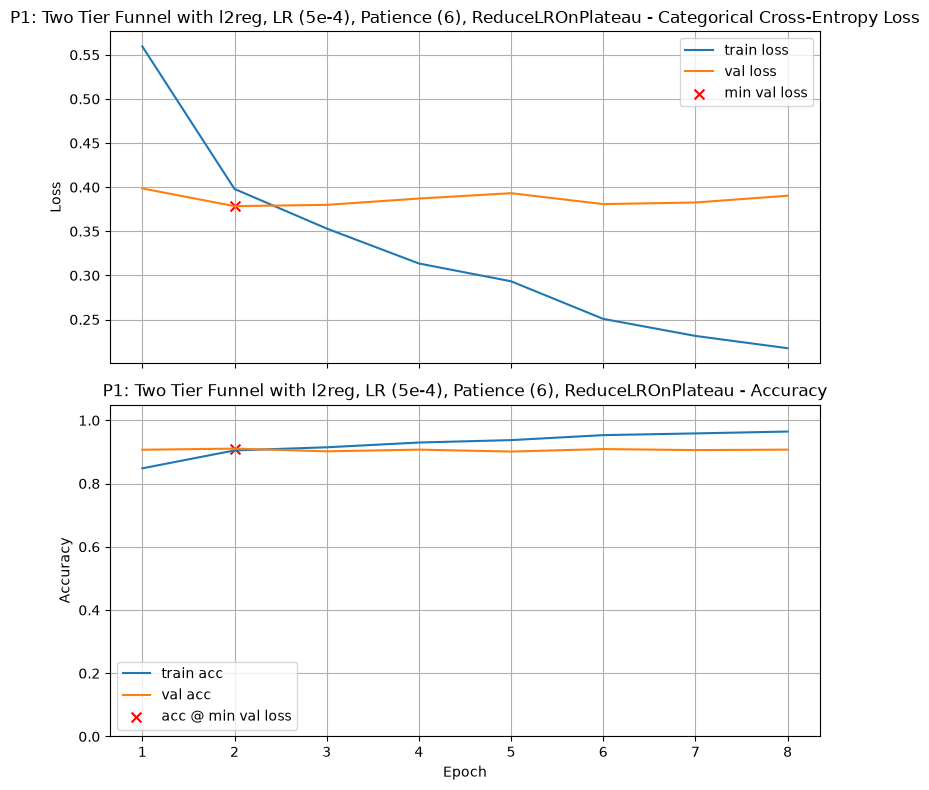

Final Training Loss:            0.2175
Final Training Accuracy:        0.9645
Final Validation Loss:          0.3903
Final Validation Accuracy:      0.9073
Minimum Validation Loss:        0.3785 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9105

Test Loss: 0.3639
Test Accuracy: 0.9083

Validation-Test Gap (accuracy): 0.002152

Execution Time: 00:01:27


In [13]:
# Construct a fresh frozen MobileNetV2 backbone

base_model2 = make_base_model_pooled()

model_two_tier_funnel = models.Sequential([
    base_model2,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel, lr_schedule=5e-4, patience=6, callbacks=[reduce_lr], title="P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Minimal Regularization with BatchNorm, DO (0.5), final dense (k_reg: l2(5e-4))

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.8052 - loss: 0.5972 - val_accuracy: 0.8902 - val_loss: 0.3182
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8738 - loss: 0.3861 - val_accuracy: 0.8973 - val_loss: 0.3080
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8823 - loss: 0.3440 - val_accuracy: 0.8951 - val_loss: 0.2995
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8850 - loss: 0.3331 - val_accuracy: 0.8987 - val_loss: 0.2880
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8870 - loss: 0.3243 - val_accuracy: 0.8969 - val_loss: 0.2918
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8907 - loss: 0.3150 - val_accuracy: 0.8969 - val_loss: 0.2949
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8940 - loss: 0.3065 - val_accuracy: 0.8927 - val_loss: 0.3050
Epoc

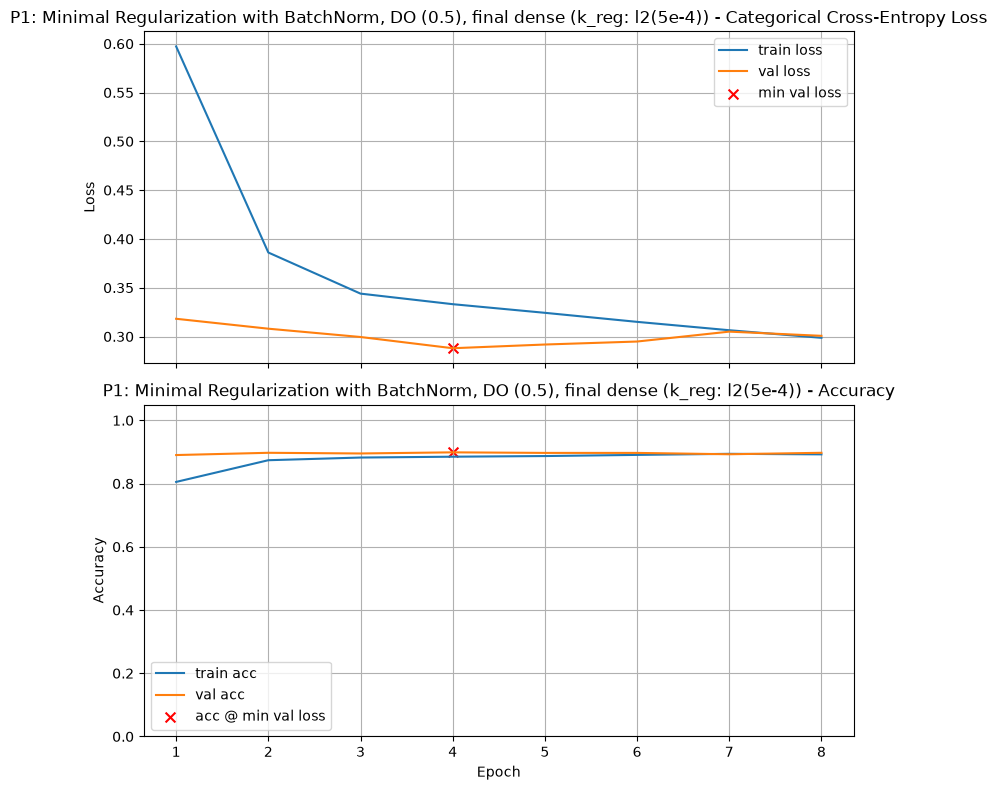

Final Training Loss:            0.2987
Final Training Accuracy:        0.8923
Final Validation Loss:          0.3007
Final Validation Accuracy:      0.8973
Minimum Validation Loss:        0.2880 (Epoch 4)
Validation Accuracy @ Min Loss: 0.8987

Test Loss: 0.2545
Test Accuracy: 0.9040

Validation-Test Gap (accuracy): 0.005284

Execution Time: 00:01:14


In [14]:
# Construct a fresh frozen MobileNetV2 backbone

base_model3 = make_base_model_pooled()

model_minimal_reg = models.Sequential([
    base_model3,
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax', kernel_regularizer=regularizers.l2(5e-4))  # use your Intel num_classes (6)
])

train_and_test(model_minimal_reg, patience=4, title="P1: Minimal Regularization with BatchNorm, DO (0.5), final dense (k_reg: l2(5e-4))")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.8255 - loss: 0.6717 - val_accuracy: 0.9051 - val_loss: 0.4179 - learning_rate: 5.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8923 - loss: 0.4482 - val_accuracy: 0.9119 - val_loss: 0.3933 - learning_rate: 5.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9099 - loss: 0.4003 - val_accuracy: 0.9094 - val_loss: 0.3959 - learning_rate: 5.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9175 - loss: 0.3740 - val_accuracy: 0.9055 - val_loss: 0.3936 - learning_rate: 5.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9277 - loss: 0.3365
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9277 - loss: 0.3365 - val_accuracy: 0.9058 - val_loss: 0.4009 - 

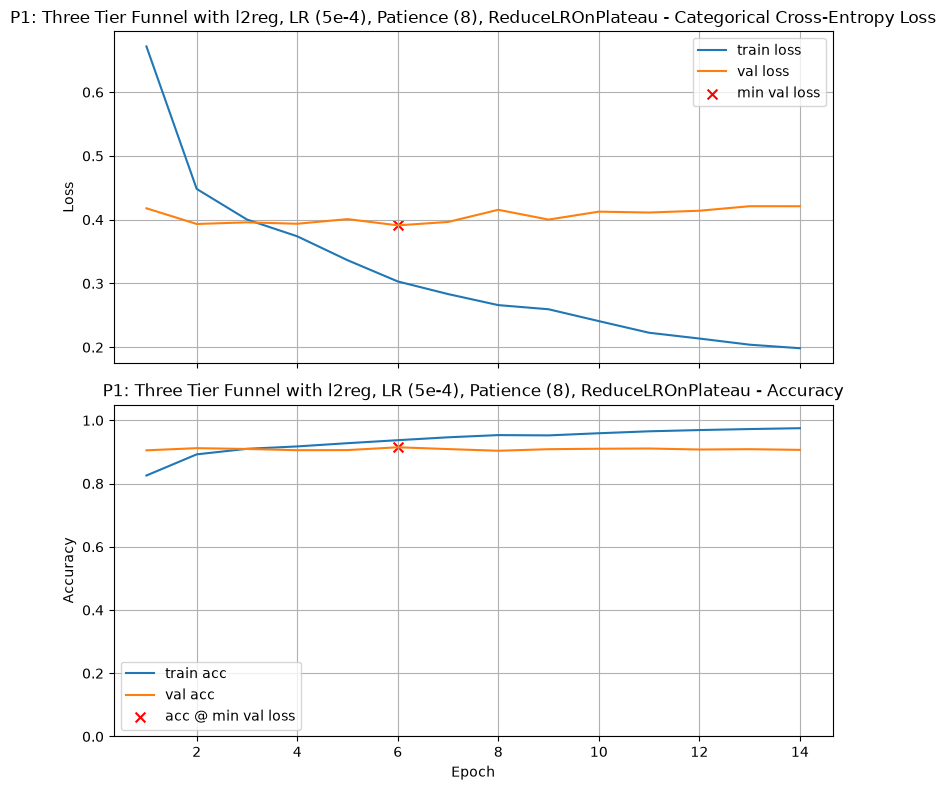

Final Training Loss:            0.1985
Final Training Accuracy:        0.9751
Final Validation Loss:          0.4211
Final Validation Accuracy:      0.9066
Minimum Validation Loss:        0.3911 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9148

Test Loss: 0.3563
Test Accuracy: 0.9163

Validation-Test Gap (accuracy): 0.001569

Execution Time: 00:02:45


In [15]:
# Construct a fresh frozen MobileNetV2 backbone

base_model4 = make_base_model_pooled()

model_three_tier_funnel = models.Sequential([
    base_model4,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel, lr_schedule=5e-4, patience=8, callbacks=[reduce_lr], title="P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.8525 - loss: 0.5560 - val_accuracy: 0.9044 - val_loss: 0.4004
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9063 - loss: 0.3872 - val_accuracy: 0.9048 - val_loss: 0.3901
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9178 - loss: 0.3530 - val_accuracy: 0.9016 - val_loss: 0.3871
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9288 - loss: 0.3139 - val_accuracy: 0.9051 - val_loss: 0.3871
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9360 - loss: 0.2959 - val_accuracy: 0.9016 - val_loss: 0.3975
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9443 - loss: 0.2711 - val_accuracy: 0.8951 - val_loss: 0.4286
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9538 - loss: 0.2485 - val_accuracy: 0.8991 - val_loss: 0.4045
Epoch 8/500
351/351 ━━━━━

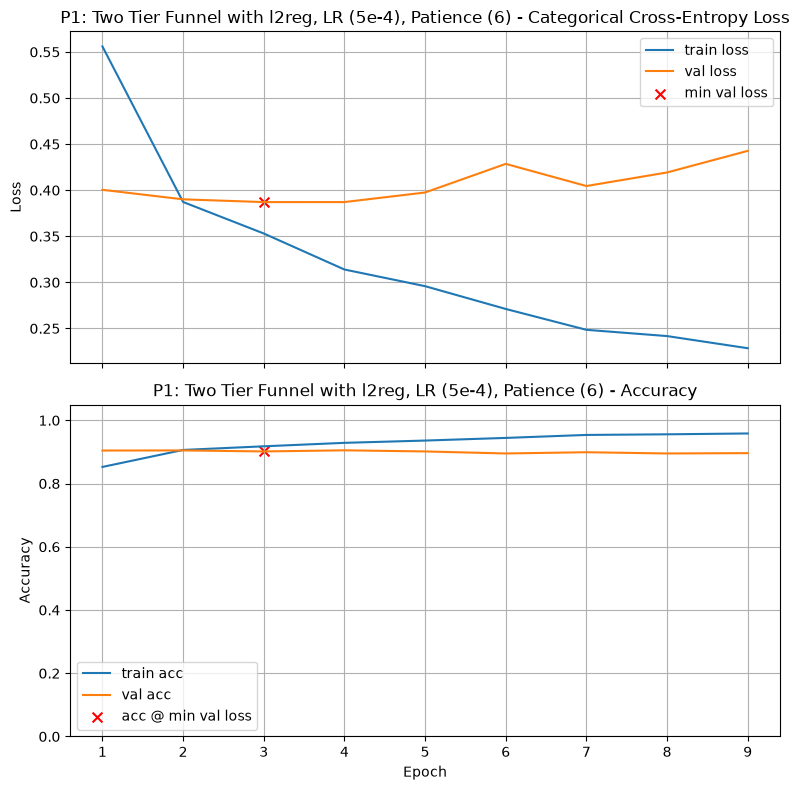

Final Training Loss:            0.2285
Final Training Accuracy:        0.9584
Final Validation Loss:          0.4427
Final Validation Accuracy:      0.8962
Minimum Validation Loss:        0.3871 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9016

Test Loss: 0.3521
Test Accuracy: 0.9113

Validation-Test Gap (accuracy): 0.009764

Execution Time: 00:01:37


In [16]:
# Construct a fresh frozen MobileNetV2 backbone

base_model5 = make_base_model_pooled()

model_two_tier_funnel2 = models.Sequential([
    base_model5,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel2, lr_schedule=5e-4, patience=6, title="P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 39ms/step - accuracy: 0.8275 - loss: 0.6762 - val_accuracy: 0.8959 - val_loss: 0.4289
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8987 - loss: 0.4412 - val_accuracy: 0.9083 - val_loss: 0.3997
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9072 - loss: 0.4046 - val_accuracy: 0.9012 - val_loss: 0.4020
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9177 - loss: 0.3694 - val_accuracy: 0.9091 - val_loss: 0.3958
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9283 - loss: 0.3355 - val_accuracy: 0.9091 - val_loss: 0.3947
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9352 - loss: 0.3125 - val_accuracy: 0.9087 - val_loss: 0.4024
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9391 - loss: 0.3050 - val_accuracy: 0.9016 - val_loss: 0.3983
Epoch 8/500
351/351 ━━━

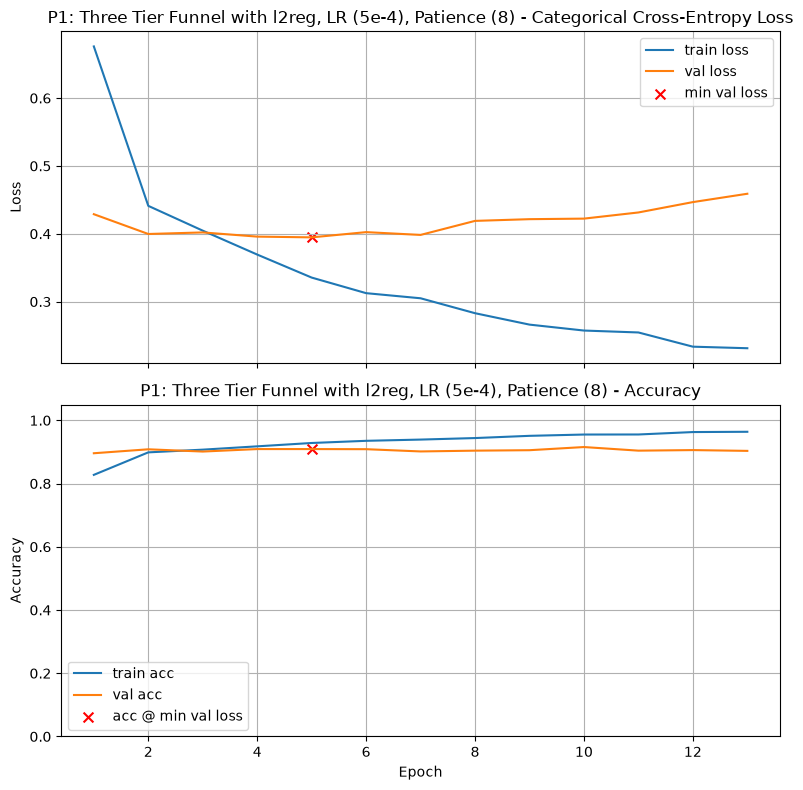

Final Training Loss:            0.2313
Final Training Accuracy:        0.9638
Final Validation Loss:          0.4590
Final Validation Accuracy:      0.9034
Minimum Validation Loss:        0.3947 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9091

Test Loss: 0.3623
Test Accuracy: 0.9150

Validation-Test Gap (accuracy): 0.005942

Execution Time: 00:02:33


In [17]:
# Construct a fresh frozen MobileNetV2 backbone

base_model6 = make_base_model_pooled()

model_three_tier_funnel2 = models.Sequential([
    base_model6,
    Dense(512, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel2, lr_schedule=5e-4, patience=8, title="P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Regularized Single-Stage MLP with Patience (6), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8715 - loss: 0.4146 - val_accuracy: 0.9012 - val_loss: 0.3292 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9144 - loss: 0.2909 - val_accuracy: 0.9019 - val_loss: 0.3127 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9321 - loss: 0.2450 - val_accuracy: 0.8962 - val_loss: 0.3322 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9423 - loss: 0.2173 - val_accuracy: 0.9005 - val_loss: 0.3444 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9484 - loss: 0.2001
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9484 - loss: 0.2001 - val_accuracy: 0.8994 - val_loss: 0.3625 - learning_rate: 0.0010
Epoc

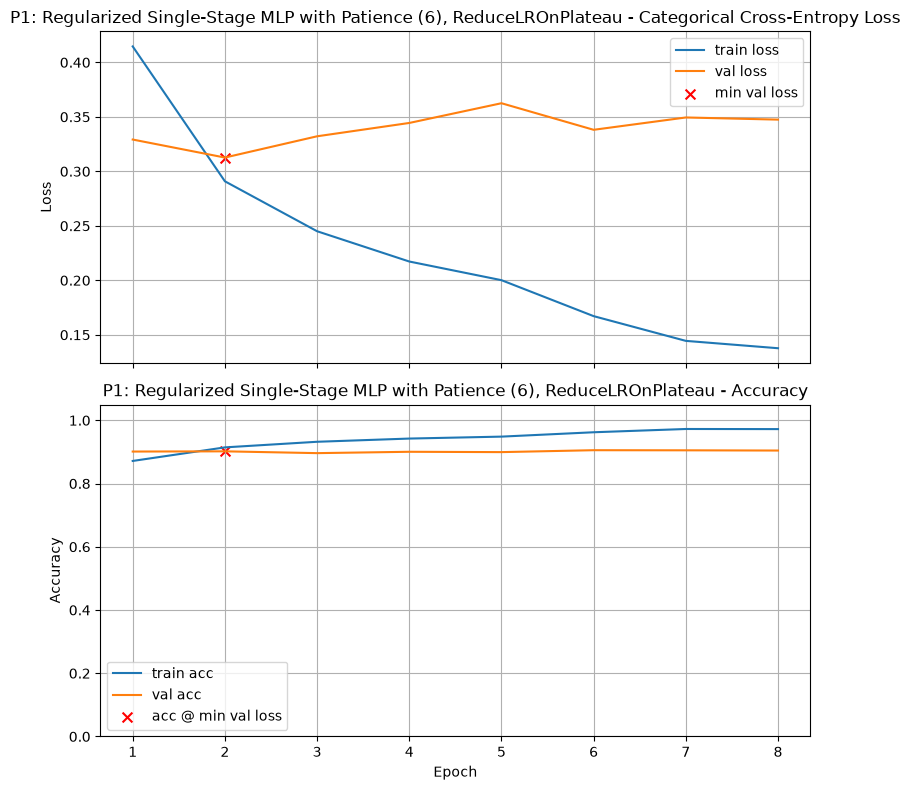

Final Training Loss:            0.1377
Final Training Accuracy:        0.9722
Final Validation Loss:          0.3475
Final Validation Accuracy:      0.9044
Minimum Validation Loss:        0.3127 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9019

Test Loss: 0.2827
Test Accuracy: 0.9160

Validation-Test Gap (accuracy): 0.014074

Execution Time: 00:01:21


In [18]:
# Construct a fresh frozen MobileNetV2 backbone

base_model7 = make_base_model_pooled()

model_reg_single_stage_MLP2 = models.Sequential([
    base_model7,
    Dense(256, kernel_initializer=he, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.35),
    Dense(num_classes, activation='softmax', kernel_regularizer=l2reg)  # use your Intel num_classes (6)
])

train_and_test(model_reg_single_stage_MLP2, patience=6, callbacks=[reduce_lr], title="P1: Regularized Single-Stage MLP with Patience (6), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Minimal with BatchNorm, DO (0.5)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.8025 - loss: 0.6064 - val_accuracy: 0.8944 - val_loss: 0.3089
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.8735 - loss: 0.3771 - val_accuracy: 0.9005 - val_loss: 0.2924
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.8813 - loss: 0.3439 - val_accuracy: 0.9080 - val_loss: 0.2806
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8893 - loss: 0.3129 - val_accuracy: 0.9005 - val_loss: 0.2817
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8890 - loss: 0.3177 - val_accuracy: 0.9009 - val_loss: 0.2872
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8967 - loss: 0.3005 - val_accuracy: 0.8959 - val_loss: 0.2938
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.8947 - loss: 0.2952 - val_accuracy: 0.9026 - val_loss: 0.2963
Epoch 7: early stopping
Restoring model weights fr

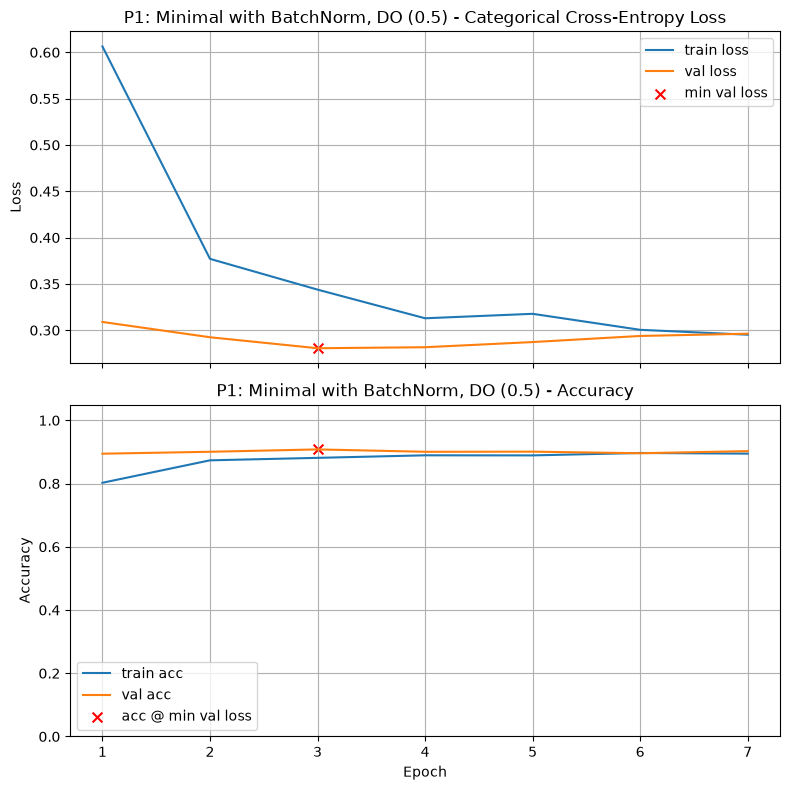

Final Training Loss:            0.2952
Final Training Accuracy:        0.8947
Final Validation Loss:          0.2963
Final Validation Accuracy:      0.9026
Minimum Validation Loss:        0.2806 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9080

Test Loss: 0.2574
Test Accuracy: 0.9013

Validation-Test Gap (accuracy): 0.006655

Execution Time: 00:01:07


In [19]:
# Construct a fresh frozen MobileNetV2 backbone

base_model8 = make_base_model_pooled()

model_minimal = models.Sequential([
    base_model8,
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_minimal, patience=4, title="P1: Minimal with BatchNorm, DO (0.5)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.8576 - loss: 0.4094 - val_accuracy: 0.9019 - val_loss: 0.2717 - learning_rate: 5.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9046 - loss: 0.2661 - val_accuracy: 0.9016 - val_loss: 0.2619 - learning_rate: 5.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9213 - loss: 0.2161 - val_accuracy: 0.9058 - val_loss: 0.2563 - learning_rate: 5.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9358 - loss: 0.1834 - val_accuracy: 0.9091 - val_loss: 0.2638 - learning_rate: 5.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9402 - loss: 0.1634 - val_accuracy: 0.9076 - val_loss: 0.2791 - learning_rate: 5.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9466 - loss: 0.1440
Epoch 6: ReduceLROnPlateau reducing learni

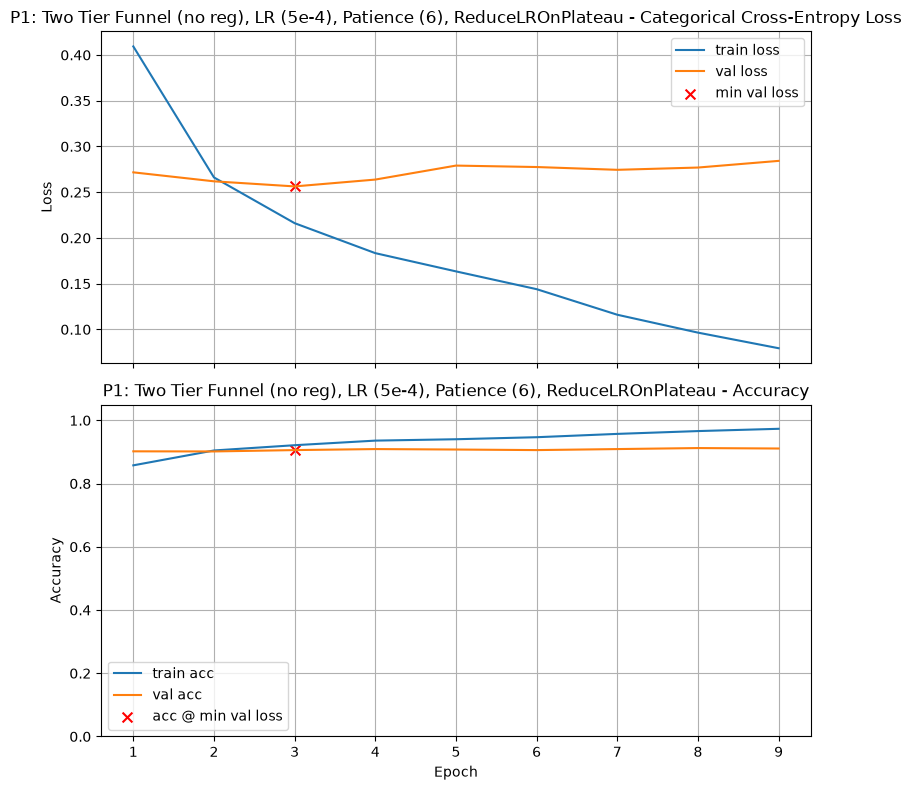

Final Training Loss:            0.0794
Final Training Accuracy:        0.9732
Final Validation Loss:          0.2842
Final Validation Accuracy:      0.9108
Minimum Validation Loss:        0.2563 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9058

Test Loss: 0.2244
Test Accuracy: 0.9177

Validation-Test Gap (accuracy): 0.011818

Execution Time: 00:01:36


In [20]:
# Construct a fresh frozen MobileNetV2 backbone

base_model9 = make_base_model_pooled()

model_two_tier_funnel_no_reg = models.Sequential([
    base_model9,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg, lr_schedule=5e-4, patience=6, callbacks=[reduce_lr], title="P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.8547 - loss: 0.4121 - val_accuracy: 0.9044 - val_loss: 0.2693
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9048 - loss: 0.2602 - val_accuracy: 0.9098 - val_loss: 0.2602
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9227 - loss: 0.2137 - val_accuracy: 0.9112 - val_loss: 0.2551
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9300 - loss: 0.1894 - val_accuracy: 0.9034 - val_loss: 0.2675
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9409 - loss: 0.1625 - val_accuracy: 0.9026 - val_loss: 0.2664
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9457 - loss: 0.1471 - val_accuracy: 0.9073 - val_loss: 0.2620
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9525 - loss: 0.1265 - val_accuracy: 0.9044 - val_loss: 0.2849
Epoch 8/500
351/351 ━━━━━━━

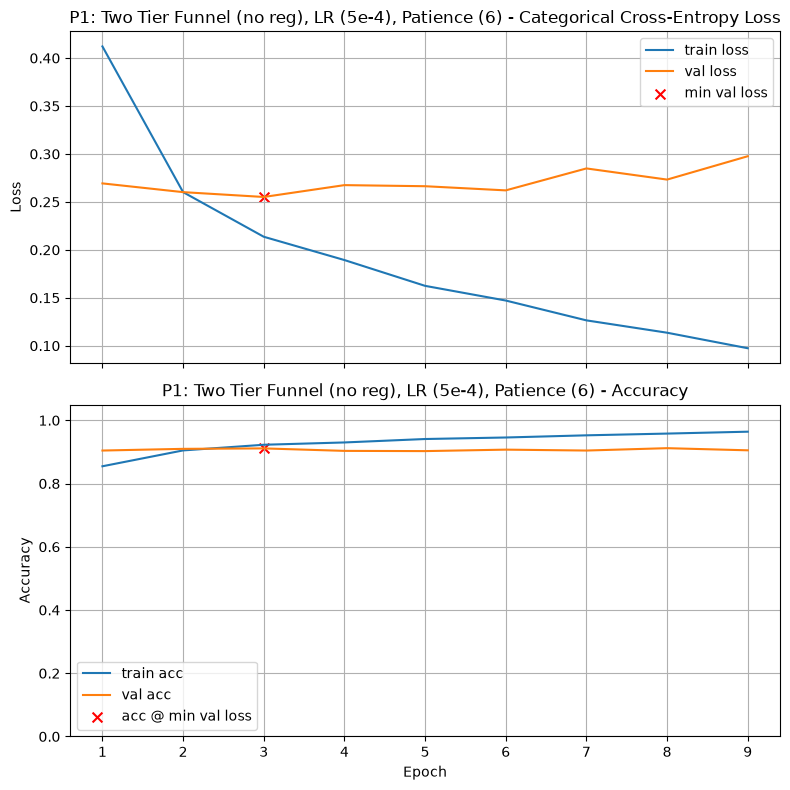

Final Training Loss:            0.0974
Final Training Accuracy:        0.9640
Final Validation Loss:          0.2976
Final Validation Accuracy:      0.9051
Minimum Validation Loss:        0.2551 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9112

Test Loss: 0.2361
Test Accuracy: 0.9133

Validation-Test Gap (accuracy): 0.002135

Execution Time: 00:01:36


In [21]:
# Construct a fresh frozen MobileNetV2 backbone

base_model10 = make_base_model_pooled()

model_two_tier_funnel_no_reg2 = models.Sequential([
    base_model10,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg2, lr_schedule=5e-4, patience=6, title="P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.8332 - loss: 0.5126 - val_accuracy: 0.9044 - val_loss: 0.2739
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8966 - loss: 0.3001 - val_accuracy: 0.9055 - val_loss: 0.2609
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9118 - loss: 0.2543 - val_accuracy: 0.9119 - val_loss: 0.2540
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9215 - loss: 0.2259 - val_accuracy: 0.9080 - val_loss: 0.2570
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9289 - loss: 0.2002 - val_accuracy: 0.8991 - val_loss: 0.2742
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9368 - loss: 0.1737 - val_accuracy: 0.9123 - val_loss: 0.2622
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9385 - loss: 0.1649 - val_accuracy: 0.9058 - val_loss: 0.2783
Epoch 8/500
351/351 ━━━━━

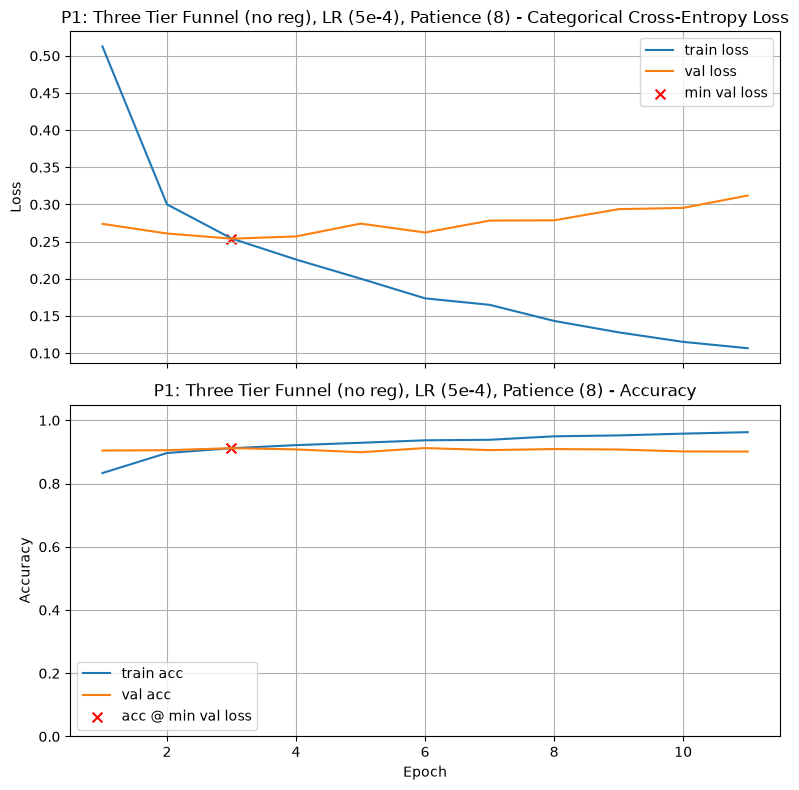

Final Training Loss:            0.1065
Final Training Accuracy:        0.9625
Final Validation Loss:          0.3120
Final Validation Accuracy:      0.9012
Minimum Validation Loss:        0.2540 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9119

Test Loss: 0.2299
Test Accuracy: 0.9087

Validation-Test Gap (accuracy): 0.003245

Execution Time: 00:02:12


In [22]:
# Construct a fresh frozen MobileNetV2 backbone

base_model11 = make_base_model_pooled()

model_three_tier_funnel_no_reg = models.Sequential([
    base_model11,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel_no_reg, lr_schedule=5e-4, patience=8, title="P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.8319 - loss: 0.5066 - val_accuracy: 0.9012 - val_loss: 0.2759 - learning_rate: 5.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8939 - loss: 0.3061 - val_accuracy: 0.9105 - val_loss: 0.2582 - learning_rate: 5.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9111 - loss: 0.2544 - val_accuracy: 0.9055 - val_loss: 0.2581 - learning_rate: 5.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9203 - loss: 0.2203 - val_accuracy: 0.9130 - val_loss: 0.2502 - learning_rate: 5.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9283 - loss: 0.1942 - val_accuracy: 0.9119 - val_loss: 0.2573 - learning_rate: 5.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9378 - loss: 0.1706 - val_accuracy: 0.9098 - val_loss: 0.26

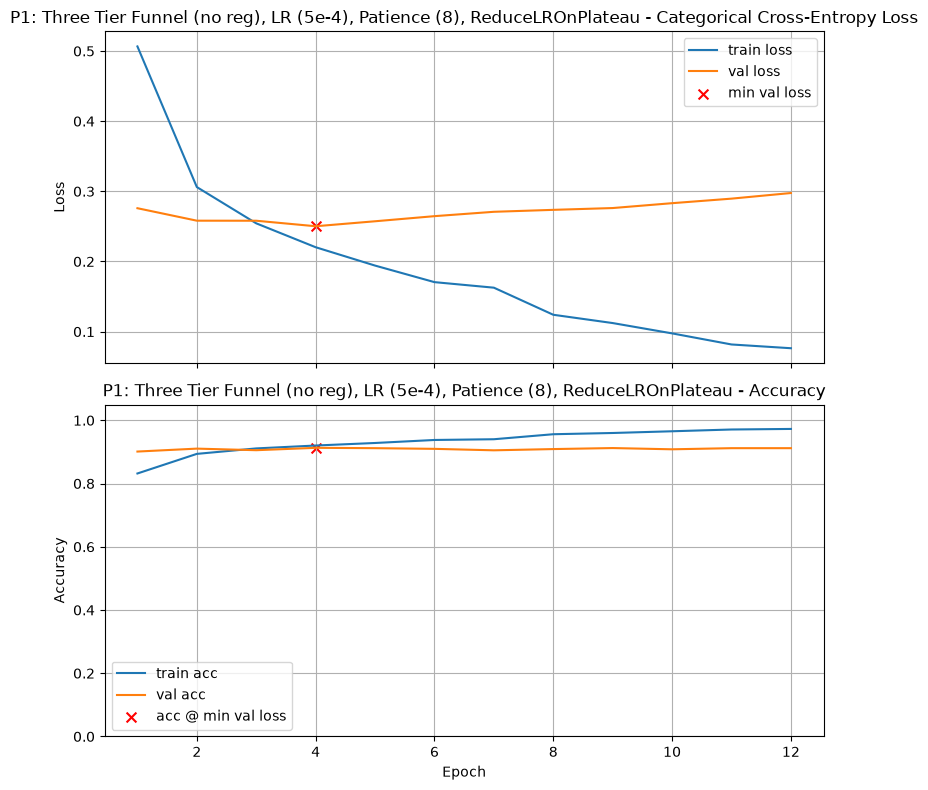

Final Training Loss:            0.0763
Final Training Accuracy:        0.9728
Final Validation Loss:          0.2976
Final Validation Accuracy:      0.9119
Minimum Validation Loss:        0.2502 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9130

Test Loss: 0.2322
Test Accuracy: 0.9157

Validation-Test Gap (accuracy): 0.002685

Execution Time: 00:02:24


In [23]:
# Construct a fresh frozen MobileNetV2 backbone

base_model12 = make_base_model_pooled()

model_three_tier_funnel_no_reg2 = models.Sequential([
    base_model12,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(64),
    BatchNormalization(),
    ReLU(),
    Dropout(0.1),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_three_tier_funnel_no_reg2, lr_schedule=5e-4, patience=8, callbacks=[reduce_lr], title="P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.7727 - loss: 0.6607 - val_accuracy: 0.8827 - val_loss: 0.3318
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8817 - loss: 0.3540 - val_accuracy: 0.8955 - val_loss: 0.2947
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8958 - loss: 0.3071 - val_accuracy: 0.9023 - val_loss: 0.2753
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9066 - loss: 0.2733 - val_accuracy: 0.9083 - val_loss: 0.2659
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9118 - loss: 0.2469 - val_accuracy: 0.9026 - val_loss: 0.2650
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9207 - loss: 0.2261 - val_accuracy: 0.9083 - val_loss: 0.2561
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9277 - loss: 0.2072 - val_accuracy: 0.9087 - val_loss: 0.2561
Epoch 8/500
351/351 ━━━━━━━

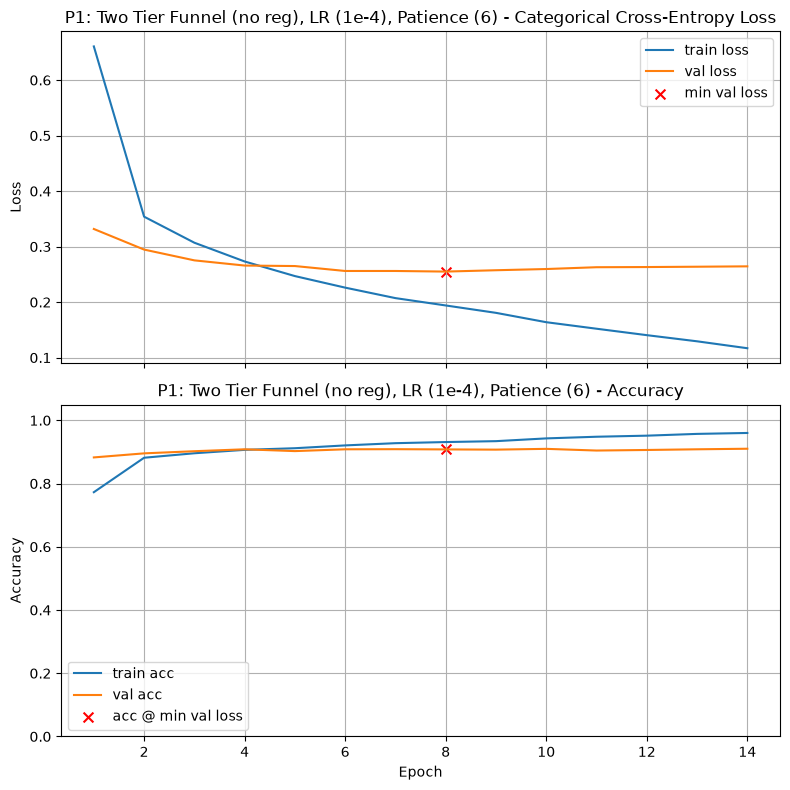

Final Training Loss:            0.1170
Final Training Accuracy:        0.9600
Final Validation Loss:          0.2645
Final Validation Accuracy:      0.9101
Minimum Validation Loss:        0.2551 (Epoch 8)
Validation Accuracy @ Min Loss: 0.9080

Test Loss: 0.2278
Test Accuracy: 0.9153

Validation-Test Gap (accuracy): 0.007345

Execution Time: 00:02:30


In [24]:
# Construct a fresh frozen MobileNetV2 backbone

base_model13 = make_base_model_pooled()

model_two_tier_funnel_no_reg3 = models.Sequential([
    base_model13,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg3, lr_schedule=1e-4, patience=6, title="P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.7723 - loss: 0.6617 - val_accuracy: 0.8880 - val_loss: 0.3213
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8812 - loss: 0.3558 - val_accuracy: 0.9023 - val_loss: 0.2794
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8946 - loss: 0.3095 - val_accuracy: 0.9073 - val_loss: 0.2644
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9032 - loss: 0.2734 - val_accuracy: 0.9087 - val_loss: 0.2611
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9102 - loss: 0.2501 - val_accuracy: 0.9108 - val_loss: 0.2512
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9201 - loss: 0.2293 - val_accuracy: 0.9073 - val_loss: 0.2539
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9238 - loss: 0.2157 - val_accuracy: 0.9144 - val_loss: 0.2454
Epoch 8/500
351/351 ━━━━━━━

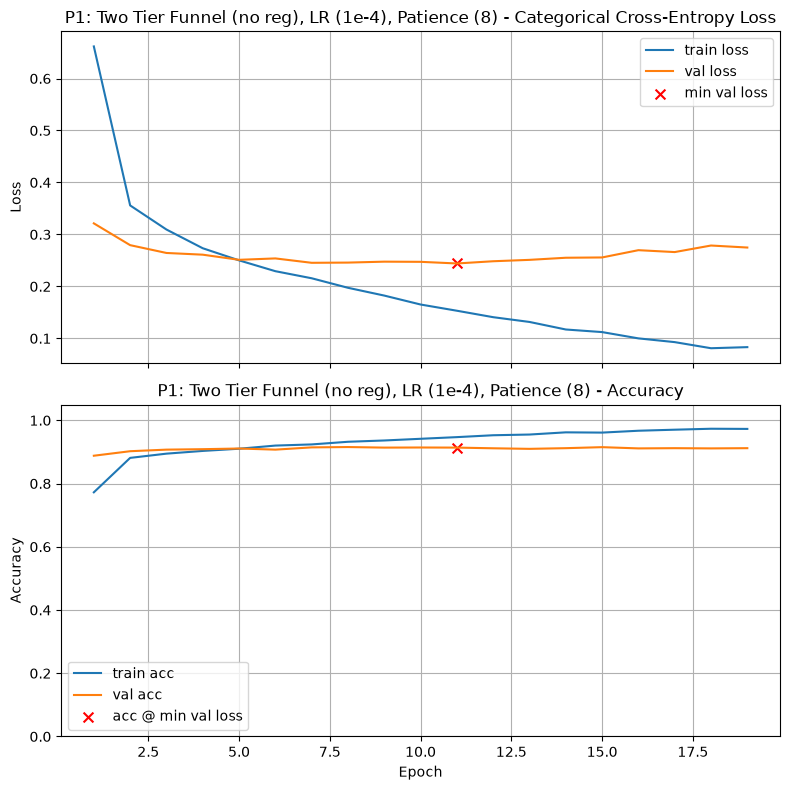

Final Training Loss:            0.0832
Final Training Accuracy:        0.9728
Final Validation Loss:          0.2748
Final Validation Accuracy:      0.9119
Minimum Validation Loss:        0.2442 (Epoch 11)
Validation Accuracy @ Min Loss: 0.9137

Test Loss: 0.2206
Test Accuracy: 0.9177

Validation-Test Gap (accuracy): 0.003972

Execution Time: 00:03:20


In [25]:
# Construct a fresh frozen MobileNetV2 backbone

base_model14 = make_base_model_pooled()

model_two_tier_funnel_no_reg4 = models.Sequential([
    base_model14,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg4, lr_schedule=1e-4, patience=8, title="P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.7823 - loss: 0.6586 - val_accuracy: 0.8941 - val_loss: 0.3215 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8766 - loss: 0.3606 - val_accuracy: 0.9019 - val_loss: 0.2837 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.8892 - loss: 0.3111 - val_accuracy: 0.9041 - val_loss: 0.2699 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9006 - loss: 0.2791 - val_accuracy: 0.9087 - val_loss: 0.2590 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9137 - loss: 0.2495 - val_accuracy: 0.9048 - val_loss: 0.2550 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9197 - loss: 0.2314 - val_accuracy: 0.9048 - val_loss: 0.2539

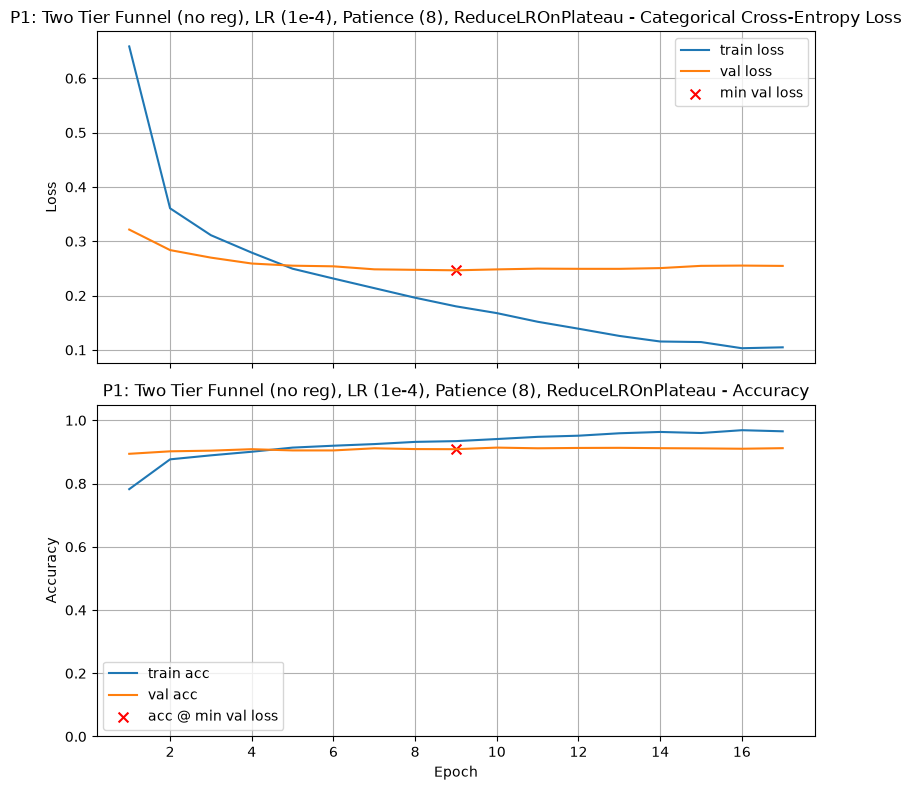

Final Training Loss:            0.1048
Final Training Accuracy:        0.9653
Final Validation Loss:          0.2546
Final Validation Accuracy:      0.9119
Minimum Validation Loss:        0.2465 (Epoch 9)
Validation Accuracy @ Min Loss: 0.9087

Test Loss: 0.2234
Test Accuracy: 0.9130

Validation-Test Gap (accuracy): 0.004298

Execution Time: 00:03:02


In [26]:
# Construct a fresh frozen MobileNetV2 backbone

base_model15 = make_base_model_pooled()

model_two_tier_funnel_no_reg5 = models.Sequential([
    base_model15,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_no_reg5, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.7752 - loss: 0.7259 - val_accuracy: 0.8927 - val_loss: 0.4148 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8787 - loss: 0.4478 - val_accuracy: 0.9012 - val_loss: 0.3785 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8944 - loss: 0.3959 - val_accuracy: 0.9051 - val_loss: 0.3623 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9050 - loss: 0.3663 - val_accuracy: 0.9091 - val_loss: 0.3520 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9118 - loss: 0.3415 - val_accuracy: 0.9076 - val_loss: 0.3508 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9205 - loss: 0.3211 - val_accuracy: 0.9105 - val_loss: 0.34

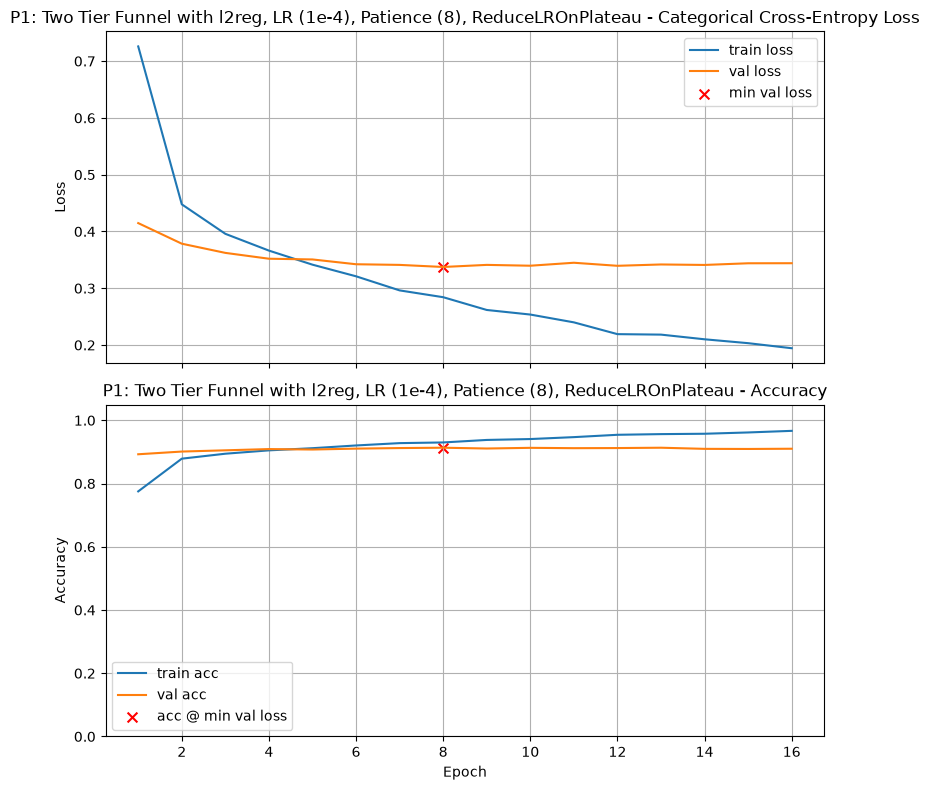

Final Training Loss:            0.1944
Final Training Accuracy:        0.9667
Final Validation Loss:          0.3441
Final Validation Accuracy:      0.9101
Minimum Validation Loss:        0.3375 (Epoch 8)
Validation Accuracy @ Min Loss: 0.9133

Test Loss: 0.3118
Test Accuracy: 0.9147

Validation-Test Gap (accuracy): 0.001329

Execution Time: 00:02:54


In [27]:
# Construct a fresh frozen MobileNetV2 backbone

base_model16 = make_base_model_pooled()

model_two_tier_funnel_with_reg = models.Sequential([
    base_model16,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(model_two_tier_funnel_with_reg, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau")

In [12]:
# Manually adding results after consistent kernel crashing to save progress

results.update({
    'P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau': (0.9148, 6),
    'P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)': (0.9137, 11),
    'P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau': (0.9133, 8),
    'P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8), ReduceLROnPlateau': (0.9130, 4),
    'P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)': (0.9119,	3),
    'P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6)': (0.9112, 3),
    'P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau': (0.9105, 2),
    'P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)': (0.9091, 5),
    'P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau': (0.9087, 9),
    'P1: Minimal with BatchNorm, DO (0.5)': (0.9080, 3),
    'P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)': (0.9080, 8),
    'P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau': (0.9062, 2),
    'P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau':	(0.9058, 3),
    'P1: Regularized Single-Stage MLP with Patience (6), ReduceLROnPlateau': (0.9019, 2),
    'P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6)': (0.9016,	3),
    'Model Baseline': (0.8991, 2),
    'P1: Minimal Regularization with BatchNorm, DO (0.5), final dense (k_reg: l2(5e-4))': (0.8987, 4)
})

In [13]:
print_results()

P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau	0.9148	6
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)	0.9137	11
P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlateau	0.9133	8
P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8), ReduceLROnPlateau	0.9130	4
P1: Three Tier Funnel (no reg), LR (5e-4), Patience (8)	0.9119	3
P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6)	0.9112	3
P1: Two Tier Funnel with l2reg, LR (5e-4), Patience (6), ReduceLROnPlateau	0.9105	2
P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8)	0.9091	5
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8), ReduceLROnPlateau	0.9087	9
P1: Minimal with BatchNorm, DO (0.5)    	0.9080	3
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (6)	0.9080	8
P1: Regularized Single-Stage MLP with Patience (5), ReduceLROnPlateau	0.9062	2
P1: Two Tier Funnel (no reg), LR (5e-4), Patience (6), ReduceLROnPlateau	0.9058	3
P1: Regularized Single-Stage MLP with Patience 

# Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which head architecture worked best for you, and what does that suggest about the role of head design and hyperparameters when the backbone is frozen?

**Instructions:**

- Write a single paragraph (3–5 sentences).
- Identify the head architecture and experiment that performed best.
- Briefly compare it with the other experiments, referring to specific design choices (e.g., dense layers, dropout) and hyperparameters (e.g., learning rate, ReduceLROnPlateau).
- Explain which of these differences you think were most important, based on your observed training and validation results.
- Conclude with what your experiments suggest about designing classification heads when the backbone is frozen.


**Your paragraph here (5pts):**

> 

**Validation Accuracy here (15 pts):**

In [14]:
# Set a1 to the validation accuracy found by your best model for this problem. 

a1 = results['P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau'][0]             # Replace 0.0 with your answer

In [15]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem         

print(f'a1 = {a1:.4f}') 


a1 = 0.9148


## Problem Two — Training MobileNetV2 with the Backbone Unfrozen

**Goal.** Use the architecture of one of your best heads from Problem 1, but now make the MobileNetV2 backbone trainable so that the entire network can adapt to the Intel Image dataset.

**Setup.** Build a new MobileNetV2 backbone with `trainable=True`. It already applies Global Average Pooling and outputs a 1280-D vector, so do not add another pooling layer.

```python
base = make_base_model_pooled(
    trainable=True
)  # MobileNetV2(include_top=False, pooling="avg")
```

### To Do

1. **Design at least three experiments** with the MobileNetV2 backbone fully unfrozen. Use the architecture of one of your best heads from Problem 1 and vary one or more of the following:

   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * training stability,
   * convergence behavior,
   * and validation performance trends.

   Use these runs to **narrow down reasonable configurations**, not to identify a single “optimal” setting.

3. **Select one configuration**, set `DATA_FRACTION = 1.0`, rerun the notebook to train on the full dataset, and use this run when answering the graded questions.

### Notes

* Training a pretrained backbone generally requires a **much smaller learning rate** than training only a new classification head. Values such as \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points.
* Small changes in relative performance between experiments using a reduced dataset and the full dataset are expected.
* Each experiment should construct a **new model** so that experiments do not inherit weights from previous runs.



/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 138s 326ms/step - accuracy: 0.7793 - loss: 0.6357 - val_accuracy: 0.8951 - val_loss: 0.2993 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 278ms/step - accuracy: 0.9036 - loss: 0.2983 - val_accuracy: 0.9058 - val_loss: 0.2731 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 104s 295ms/step - accuracy: 0.9245 - loss: 0.2303 - val_accuracy: 0.9155 - val_loss: 0.2525 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 272ms/step - accuracy: 0.9420 - loss: 0.1783 - val_accuracy: 0.9201 - val_loss: 0.2425 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.9534 - loss: 0.1400 - val_accuracy: 0.9133 - val_loss: 0.2754 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 272ms/step - accuracy: 0.9657 - loss: 0.1056 - val_accuracy: 0.8987 - val_loss: 0.3116 - learning_rate: 1.0000e-04
Ep

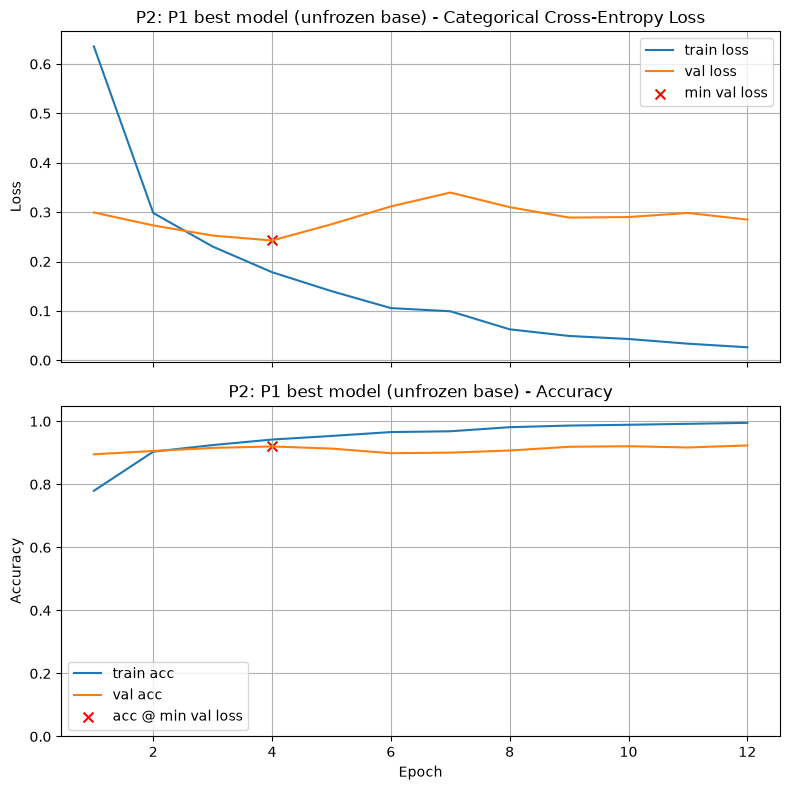

Final Training Loss:            0.0263
Final Training Accuracy:        0.9950
Final Validation Loss:          0.2849
Final Validation Accuracy:      0.9233
Minimum Validation Loss:        0.2425 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9201

Test Loss: 0.2201
Test Accuracy: 0.9250

Validation-Test Gap (accuracy): 0.004886

Execution Time: 00:20:02


In [31]:
model_unfrozen_baseline = make_base_model_pooled(trainable=True)

p1_best = models.Sequential([
    model_unfrozen_baseline,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (1e-5)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 157s 368ms/step - accuracy: 0.3699 - loss: 1.6394 - val_accuracy: 0.6487 - val_loss: 0.9590 - learning_rate: 1.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.6662 - loss: 0.9358 - val_accuracy: 0.8039 - val_loss: 0.5547 - learning_rate: 1.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.7876 - loss: 0.6560 - val_accuracy: 0.8463 - val_loss: 0.4316 - learning_rate: 1.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.8322 - loss: 0.5251 - val_accuracy: 0.8666 - val_loss: 0.3797 - learning_rate: 1.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.8606 - loss: 0.4528 - val_accuracy: 0.8805 - val_loss: 0.3529 - learning_rate: 1.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 271ms/step - accuracy: 0.8703 - loss: 0.4062 - val_accuracy: 0.8887 - val_loss: 0.3319 - learning_rate: 1.

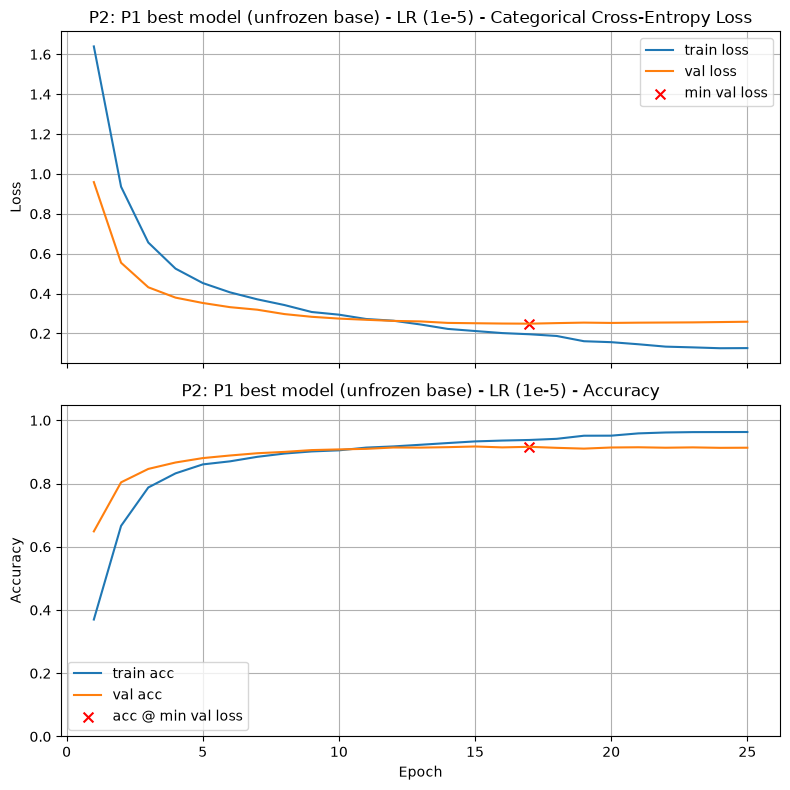

Final Training Loss:            0.1266
Final Training Accuracy:        0.9630
Final Validation Loss:          0.2588
Final Validation Accuracy:      0.9133
Minimum Validation Loss:        0.2491 (Epoch 17)
Validation Accuracy @ Min Loss: 0.9162

Test Loss: 0.2393
Test Accuracy: 0.9157

Validation-Test Gap (accuracy): 0.000525

Execution Time: 00:41:12


In [32]:
model_unfrozen_baseline2 = make_base_model_pooled(trainable=True)

p1_best2 = models.Sequential([
    model_unfrozen_baseline2,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best2, lr_schedule=1e-5, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - LR (1e-5)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 168s 396ms/step - accuracy: 0.6067 - loss: 1.0740 - val_accuracy: 0.8317 - val_loss: 0.4383 - learning_rate: 3.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 270ms/step - accuracy: 0.8583 - loss: 0.4549 - val_accuracy: 0.8820 - val_loss: 0.3231 - learning_rate: 3.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 270ms/step - accuracy: 0.8881 - loss: 0.3526 - val_accuracy: 0.8991 - val_loss: 0.2847 - learning_rate: 3.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 94s 269ms/step - accuracy: 0.9021 - loss: 0.2991 - val_accuracy: 0.9151 - val_loss: 0.2514 - learning_rate: 3.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.9147 - loss: 0.2664 - val_accuracy: 0.9173 - val_loss: 0.2454 - learning_rate: 3.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 271ms/step - accuracy: 0.9305 - loss: 0.2231 - val_accuracy: 0.9205 - val_loss: 0.2337 - learning_rate: 3.

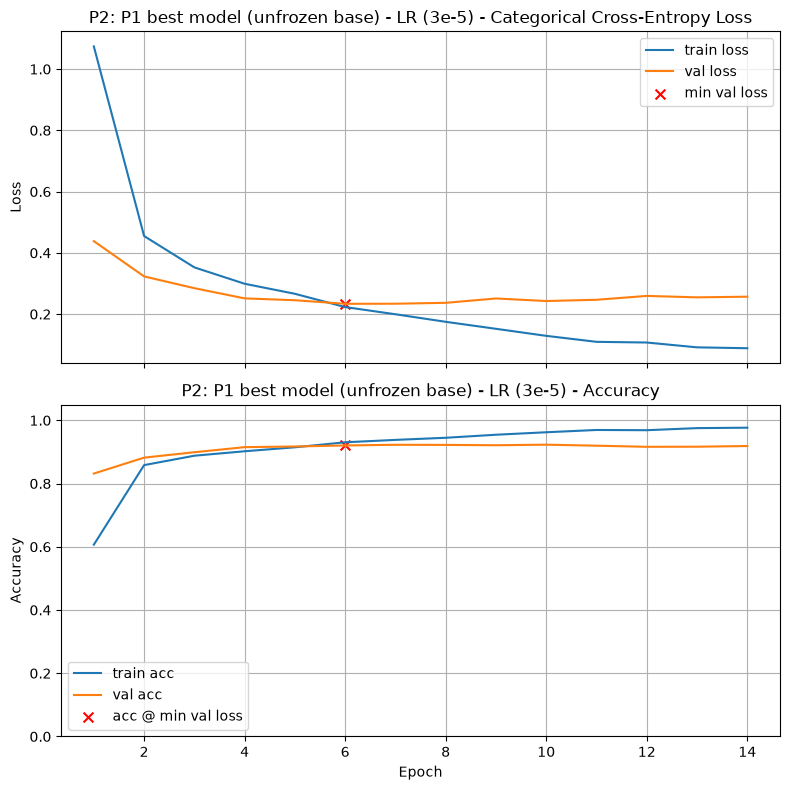

Final Training Loss:            0.0887
Final Training Accuracy:        0.9767
Final Validation Loss:          0.2569
Final Validation Accuracy:      0.9187
Minimum Validation Loss:        0.2337 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9205

Test Loss: 0.2260
Test Accuracy: 0.9230

Validation-Test Gap (accuracy): 0.002529

Execution Time: 00:23:25


In [33]:
model_unfrozen_baseline3 = make_base_model_pooled(trainable=True)

p1_best3 = models.Sequential([
    model_unfrozen_baseline3,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best3, lr_schedule=3e-5, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - LR (3e-5)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 185s 407ms/step - accuracy: 0.6338 - loss: 1.0305 - val_accuracy: 0.8399 - val_loss: 0.4507
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 272ms/step - accuracy: 0.8524 - loss: 0.4657 - val_accuracy: 0.8527 - val_loss: 0.4314
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.8868 - loss: 0.3569 - val_accuracy: 0.8759 - val_loss: 0.3531
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.9060 - loss: 0.2978 - val_accuracy: 0.9026 - val_loss: 0.2776
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.9189 - loss: 0.2539 - val_accuracy: 0.9098 - val_loss: 0.2626
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.9273 - loss: 0.2313 - val_accuracy: 0.9255 - val_loss: 0.2325
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 271ms/step - accuracy: 0.9359 - loss: 0.2101 - val_accuracy: 0.9208 - val_loss: 0.2342
Epoch 

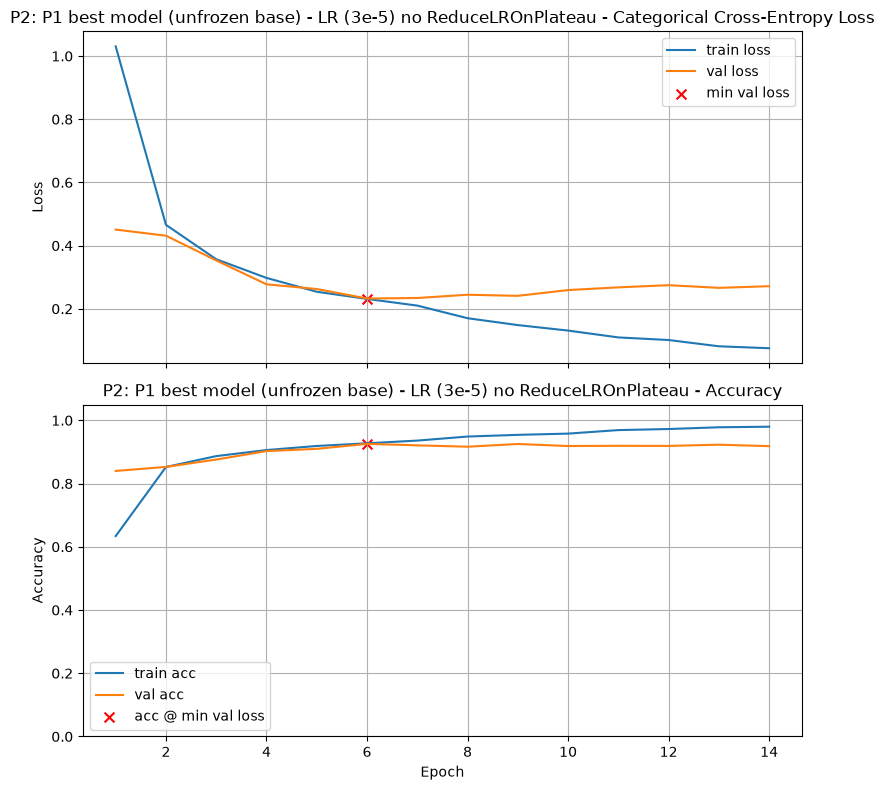

Final Training Loss:            0.0752
Final Training Accuracy:        0.9798
Final Validation Loss:          0.2716
Final Validation Accuracy:      0.9183
Minimum Validation Loss:        0.2325 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9255

Test Loss: 0.2286
Test Accuracy: 0.9203

Validation-Test Gap (accuracy): 0.005130

Execution Time: 00:23:49


In [34]:
model_unfrozen_baseline4 = make_base_model_pooled(trainable=True)

p1_best4 = models.Sequential([
    model_unfrozen_baseline4,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best4, lr_schedule=3e-5, patience=8, title="P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg on Dense 512

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 178s 419ms/step - accuracy: 0.6133 - loss: 1.1686 - val_accuracy: 0.8203 - val_loss: 0.5688 - learning_rate: 3.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 277ms/step - accuracy: 0.8511 - loss: 0.5419 - val_accuracy: 0.8670 - val_loss: 0.4530 - learning_rate: 3.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.8872 - loss: 0.4332 - val_accuracy: 0.9019 - val_loss: 0.3605 - learning_rate: 3.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 94s 267ms/step - accuracy: 0.9037 - loss: 0.3754 - val_accuracy: 0.9069 - val_loss: 0.3456 - learning_rate: 3.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 271ms/step - accuracy: 0.9199 - loss: 0.3332 - val_accuracy: 0.9162 - val_loss: 0.3211 - learning_rate: 3.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 272ms/step - accuracy: 0.9248 - loss: 0.3035 - val_accuracy: 0.9208 - val_loss: 0.312

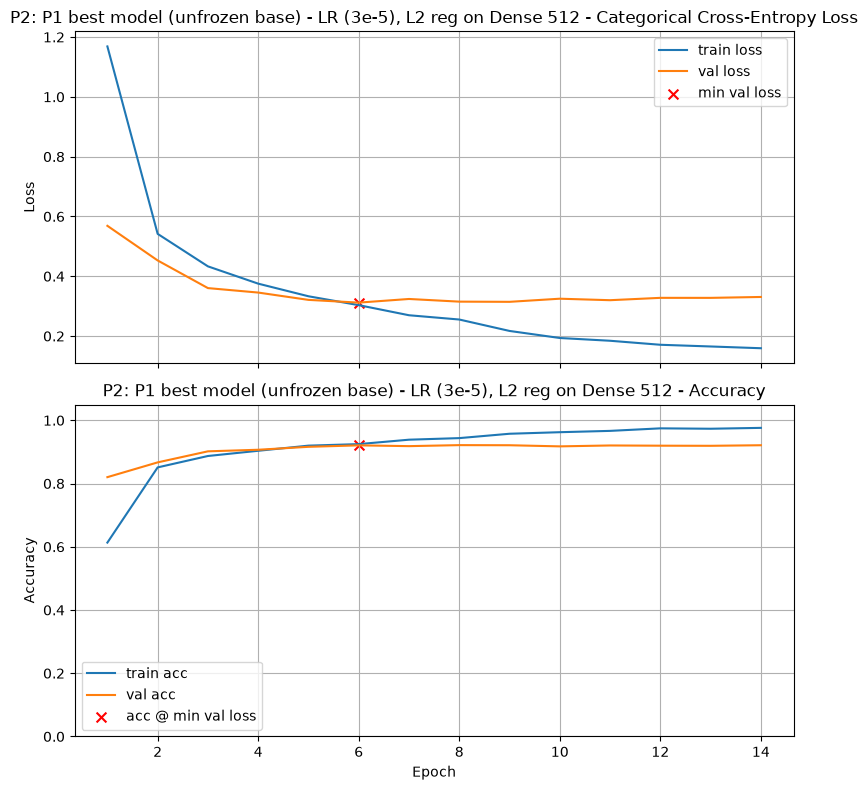

Final Training Loss:            0.1595
Final Training Accuracy:        0.9761
Final Validation Loss:          0.3309
Final Validation Accuracy:      0.9212
Minimum Validation Loss:        0.3120 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9208

Test Loss: 0.3005
Test Accuracy: 0.9217

Validation-Test Gap (accuracy): 0.000839

Execution Time: 00:23:42


In [35]:
model_unfrozen_baseline5 = make_base_model_pooled(trainable=True)

p1_best5 = models.Sequential([
    model_unfrozen_baseline5,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best5, lr_schedule=3e-5, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg on Dense 512")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 214s 488ms/step - accuracy: 0.6250 - loss: 1.1107 - val_accuracy: 0.8395 - val_loss: 0.4893
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 272ms/step - accuracy: 0.8567 - loss: 0.5263 - val_accuracy: 0.8827 - val_loss: 0.3988
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.8921 - loss: 0.4194 - val_accuracy: 0.8894 - val_loss: 0.3781
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 271ms/step - accuracy: 0.9021 - loss: 0.3651 - val_accuracy: 0.9087 - val_loss: 0.3374
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.9188 - loss: 0.3264 - val_accuracy: 0.9141 - val_loss: 0.3111
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.9321 - loss: 0.2912 - val_accuracy: 0.9194 - val_loss: 0.3011
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 272ms/step - accuracy: 0.9362 - loss: 0.2725 - val_accuracy: 0.9208 - v

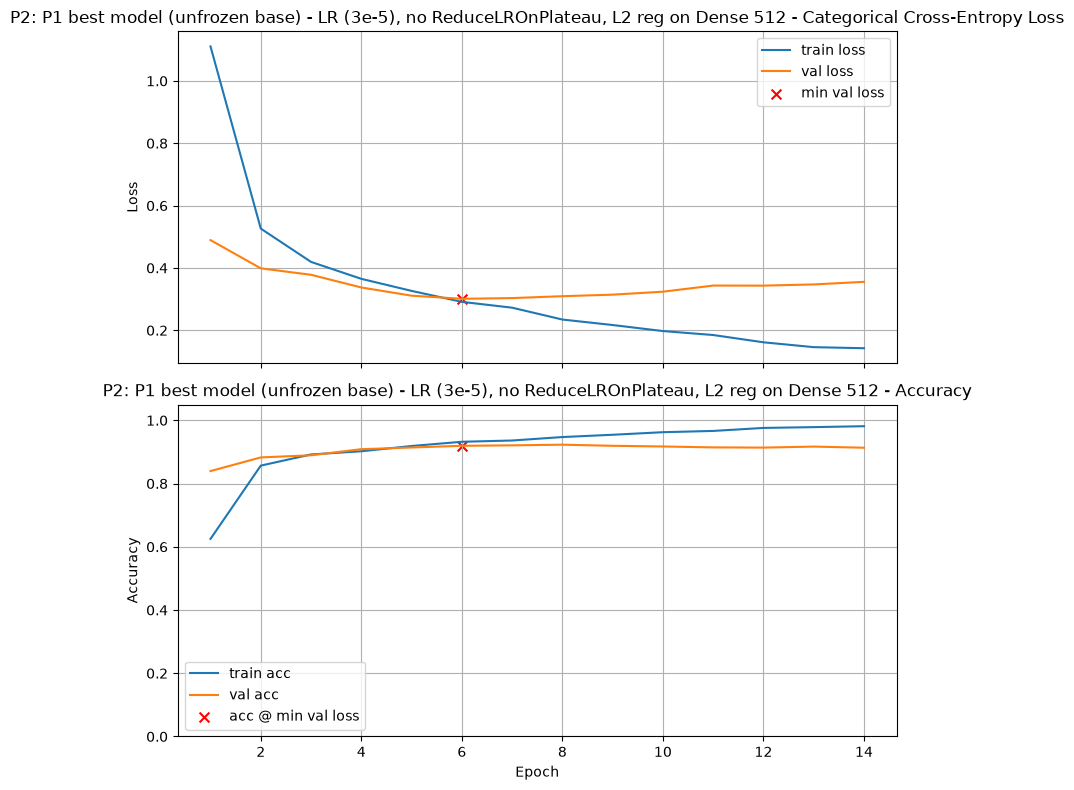

Final Training Loss:            0.1425
Final Training Accuracy:        0.9814
Final Validation Loss:          0.3555
Final Validation Accuracy:      0.9133
Minimum Validation Loss:        0.3011 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9194

Test Loss: 0.2930
Test Accuracy: 0.9173

Validation-Test Gap (accuracy): 0.002068

Execution Time: 00:24:19


In [36]:
model_unfrozen_baseline6 = make_base_model_pooled(trainable=True)

p1_best6 = models.Sequential([
    model_unfrozen_baseline6,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best6, lr_schedule=3e-5, patience=8, title="P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 255s 572ms/step - accuracy: 0.6199 - loss: 1.1338 - val_accuracy: 0.8449 - val_loss: 0.5023 - learning_rate: 3.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.8519 - loss: 0.5603 - val_accuracy: 0.8809 - val_loss: 0.4229 - learning_rate: 3.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 271ms/step - accuracy: 0.8805 - loss: 0.4526 - val_accuracy: 0.8976 - val_loss: 0.3773 - learning_rate: 3.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 272ms/step - accuracy: 0.9043 - loss: 0.3905 - val_accuracy: 0.8998 - val_loss: 0.3659 - learning_rate: 3.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 272ms/step - accuracy: 0.9206 - loss: 0.3438 - val_accuracy: 0.9205 - val_loss: 0.3322 - learning_rate: 3.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.9286 - loss: 0.3183 - val_accuracy: 0.9215 - val_loss: 0.3262 - learning_

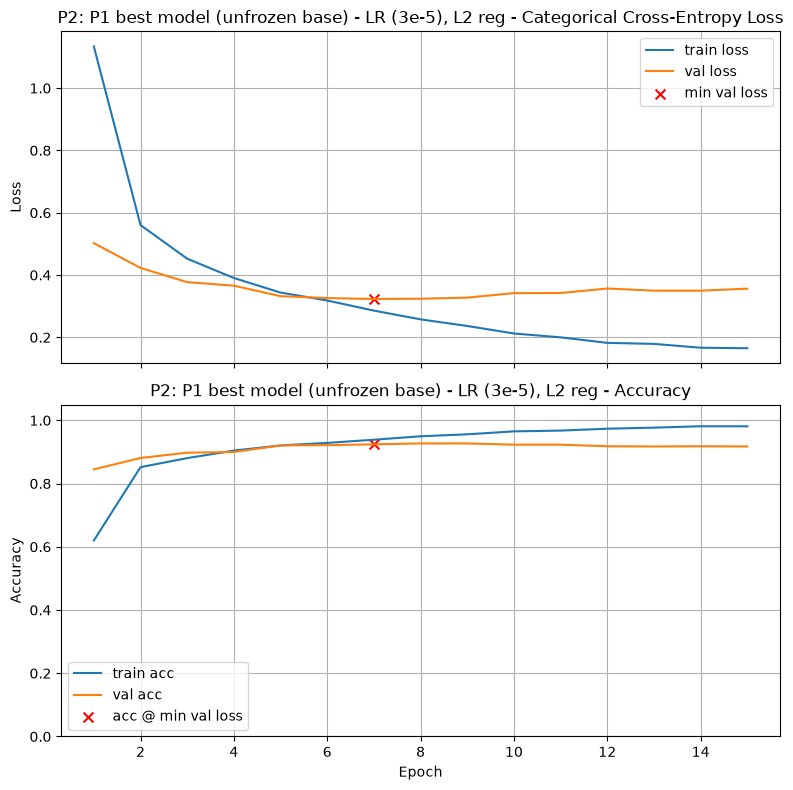

Final Training Loss:            0.1651
Final Training Accuracy:        0.9810
Final Validation Loss:          0.3563
Final Validation Accuracy:      0.9173
Minimum Validation Loss:        0.3232 (Epoch 7)
Validation Accuracy @ Min Loss: 0.9240

Test Loss: 0.3183
Test Accuracy: 0.9210

Validation-Test Gap (accuracy): 0.003037

Execution Time: 00:26:34


In [37]:
model_unfrozen_baseline7 = make_base_model_pooled(trainable=True)

p1_best7 = models.Sequential([
    model_unfrozen_baseline7,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best7, lr_schedule=3e-5, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 276s 667ms/step - accuracy: 0.6244 - loss: 1.1261 - val_accuracy: 0.8185 - val_loss: 0.5748
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - accuracy: 0.8553 - loss: 0.5422 - val_accuracy: 0.8695 - val_loss: 0.4605
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 275ms/step - accuracy: 0.8864 - loss: 0.4448 - val_accuracy: 0.8869 - val_loss: 0.4143
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - accuracy: 0.9055 - loss: 0.3856 - val_accuracy: 0.9069 - val_loss: 0.3573
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 277ms/step - accuracy: 0.9182 - loss: 0.3495 - val_accuracy: 0.9158 - val_loss: 0.3363
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 272ms/step - accuracy: 0.9315 - loss: 0.3109 - val_accuracy: 0.9148 - val_loss: 0.3418
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 95s 272ms/step - accuracy: 0.9382 - loss: 0.2921 - val_accuracy: 0.9119 - val_loss: 0.35

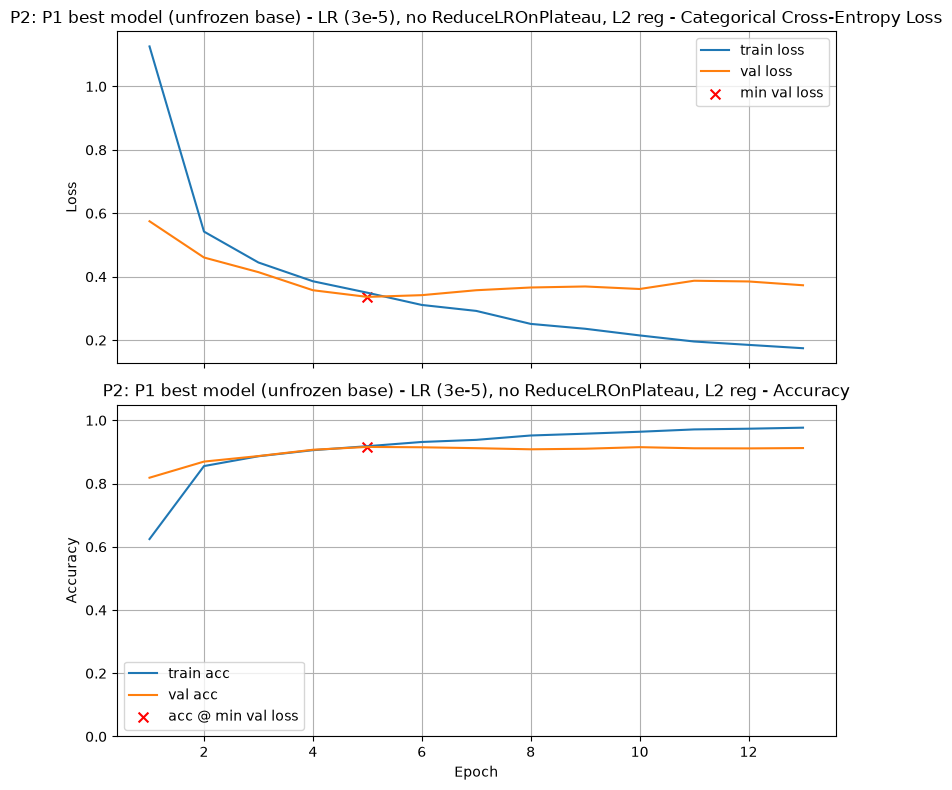

Final Training Loss:            0.1744
Final Training Accuracy:        0.9768
Final Validation Loss:          0.3730
Final Validation Accuracy:      0.9123
Minimum Validation Loss:        0.3363 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9158

Test Loss: 0.3237
Test Accuracy: 0.9167

Validation-Test Gap (accuracy): 0.000832

Execution Time: 00:23:53


In [38]:
model_unfrozen_baseline8 = make_base_model_pooled(trainable=True)

p1_best8 = models.Sequential([
    model_unfrozen_baseline8,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best8, lr_schedule=3e-5, patience=8, title="P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg, patience 3

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 333s 813ms/step - accuracy: 0.6365 - loss: 1.1007 - val_accuracy: 0.8406 - val_loss: 0.5150
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - accuracy: 0.8468 - loss: 0.5609 - val_accuracy: 0.8755 - val_loss: 0.4446
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.8871 - loss: 0.4486 - val_accuracy: 0.8951 - val_loss: 0.3948
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 275ms/step - accuracy: 0.9060 - loss: 0.3907 - val_accuracy: 0.9098 - val_loss: 0.3565
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.9167 - loss: 0.3532 - val_accuracy: 0.9158 - val_loss: 0.3445
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 272ms/step - accuracy: 0.9254 - loss: 0.3254 - val_accuracy: 0.9183 - val_loss: 0.3367
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - accuracy: 0.9397 - loss: 0.2870 - val_accuracy: 0.9198 - va

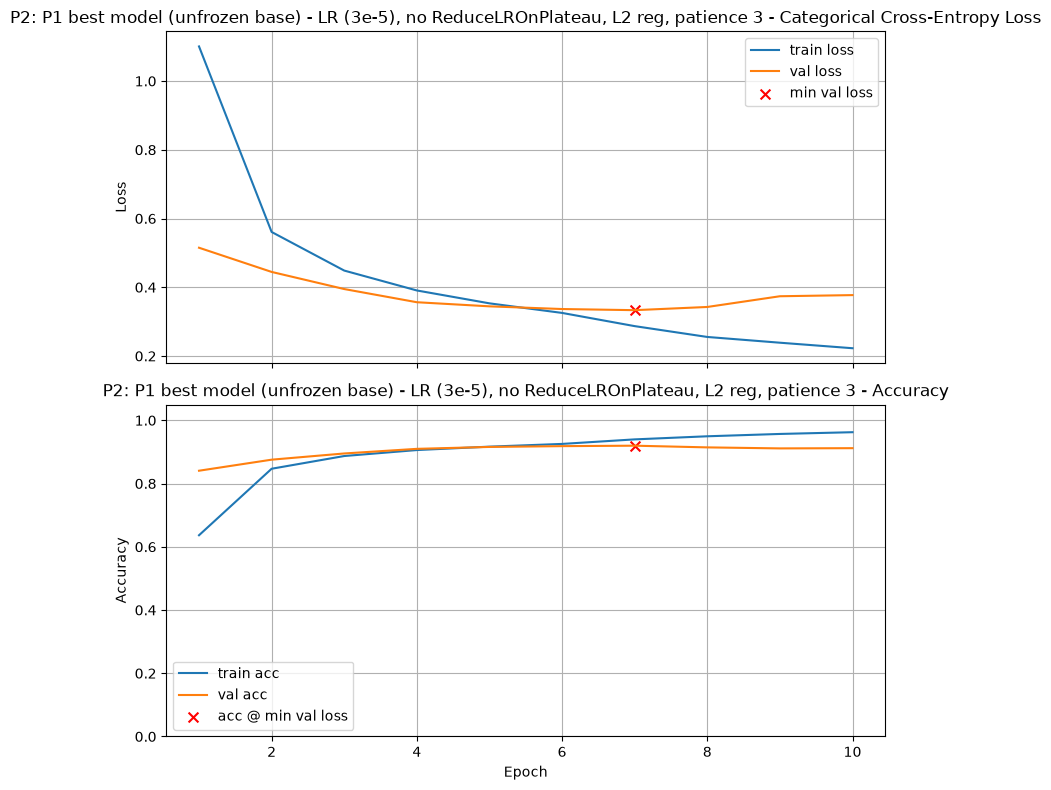

Final Training Loss:            0.2227
Final Training Accuracy:        0.9624
Final Validation Loss:          0.3772
Final Validation Accuracy:      0.9119
Minimum Validation Loss:        0.3334 (Epoch 7)
Validation Accuracy @ Min Loss: 0.9198

Test Loss: 0.3169
Test Accuracy: 0.9223

Validation-Test Gap (accuracy): 0.002576

Execution Time: 00:20:03


In [39]:
model_unfrozen_baseline9 = make_base_model_pooled(trainable=True)

p1_best9 = models.Sequential([
    model_unfrozen_baseline9,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best9, lr_schedule=3e-5, patience=3, title="P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg, patience 3")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-4), no ReduceLROnPlateau, L2 reg, patience 3

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 358s 864ms/step - accuracy: 0.8418 - loss: 0.5618 - val_accuracy: 0.8117 - val_loss: 0.7174
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 278ms/step - accuracy: 0.9092 - loss: 0.3652 - val_accuracy: 0.8531 - val_loss: 0.5479
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.9247 - loss: 0.3174 - val_accuracy: 0.8170 - val_loss: 0.6388
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.9240 - loss: 0.3121 - val_accuracy: 0.8573 - val_loss: 0.5604
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 274ms/step - accuracy: 0.9363 - loss: 0.2763 - val_accuracy: 0.7853 - val_loss: 0.8089
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


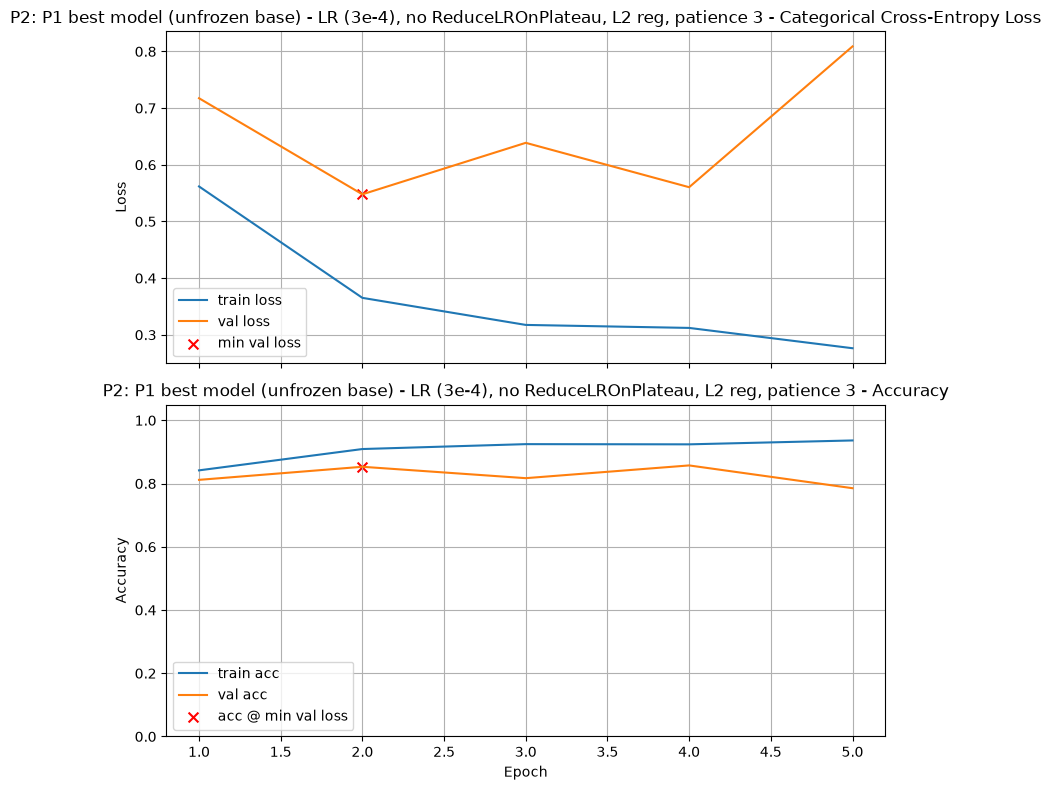

Final Training Loss:            0.2763
Final Training Accuracy:        0.9363
Final Validation Loss:          0.8089
Final Validation Accuracy:      0.7853
Minimum Validation Loss:        0.5479 (Epoch 2)
Validation Accuracy @ Min Loss: 0.8531

Test Loss: 0.5283
Test Accuracy: 0.8550

Validation-Test Gap (accuracy): 0.001933

Execution Time: 00:12:28


In [40]:
model_unfrozen_baseline10 = make_base_model_pooled(trainable=True)

p1_best10 = models.Sequential([
    model_unfrozen_baseline10,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best10, lr_schedule=3e-4, patience=3, title="P2: P1 best model (unfrozen base) - LR (3e-4), no ReduceLROnPlateau, L2 reg, patience 3")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - LR (3e-4), no ReduceLROnPlateau, patience 3

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 396s 950ms/step - accuracy: 0.8412 - loss: 0.4636 - val_accuracy: 0.7379 - val_loss: 0.8293
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 274ms/step - accuracy: 0.9111 - loss: 0.2674 - val_accuracy: 0.7361 - val_loss: 0.9047
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.9215 - loss: 0.2338 - val_accuracy: 0.7389 - val_loss: 1.1484
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 96s 273ms/step - accuracy: 0.9271 - loss: 0.2146 - val_accuracy: 0.6879 - val_loss: 1.2494
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


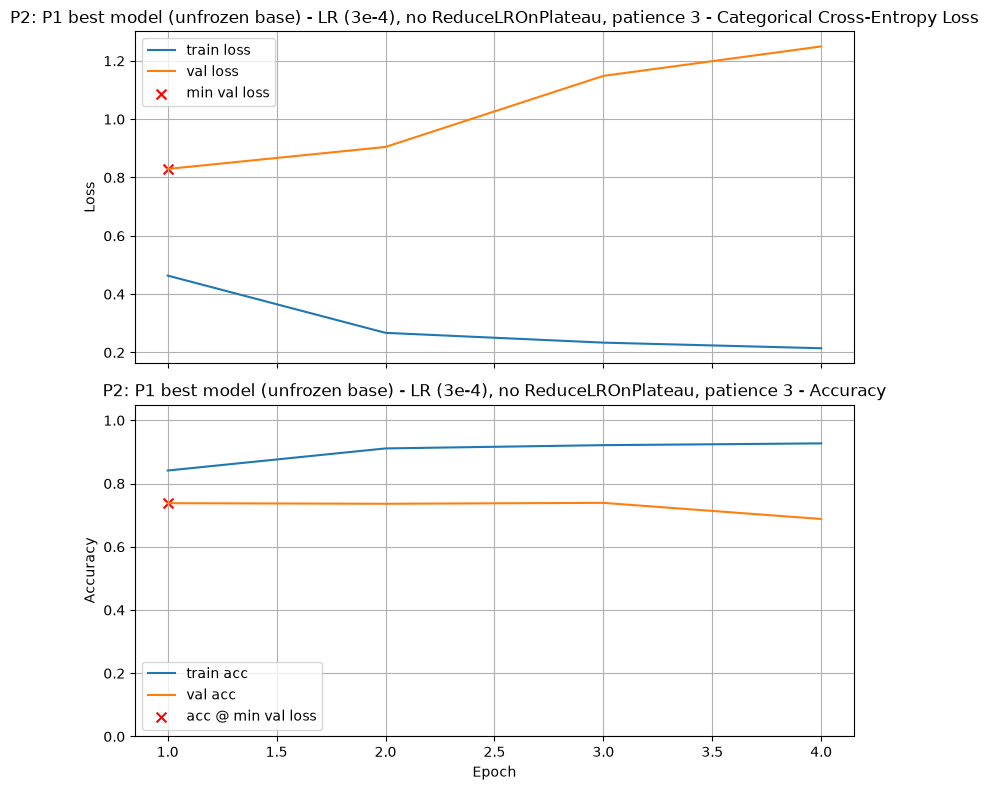

Final Training Loss:            0.2146
Final Training Accuracy:        0.9271
Final Validation Loss:          1.2494
Final Validation Accuracy:      0.6879
Minimum Validation Loss:        0.8293 (Epoch 1)
Validation Accuracy @ Min Loss: 0.7379

Test Loss: 0.8604
Test Accuracy: 0.7330

Validation-Test Gap (accuracy): 0.004874

Execution Time: 00:11:27


In [41]:
model_unfrozen_baseline11 = make_base_model_pooled(trainable=True)

p1_best11 = models.Sequential([
    model_unfrozen_baseline11,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best11, lr_schedule=3e-4, patience=3, title="P2: P1 best model (unfrozen base) - LR (3e-4), no ReduceLROnPlateau, patience 3")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - No Dropout

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 457s 1s/step - accuracy: 0.8397 - loss: 0.4704 - val_accuracy: 0.8994 - val_loss: 0.2968 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 275ms/step - accuracy: 0.9247 - loss: 0.2269 - val_accuracy: 0.8652 - val_loss: 0.4141 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 275ms/step - accuracy: 0.9500 - loss: 0.1547 - val_accuracy: 0.9141 - val_loss: 0.2563 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 281ms/step - accuracy: 0.9619 - loss: 0.1203 - val_accuracy: 0.9073 - val_loss: 0.3014 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 279ms/step - accuracy: 0.9736 - loss: 0.0893 - val_accuracy: 0.9141 - val_loss: 0.2816 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9732 - loss: 0.0815
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873

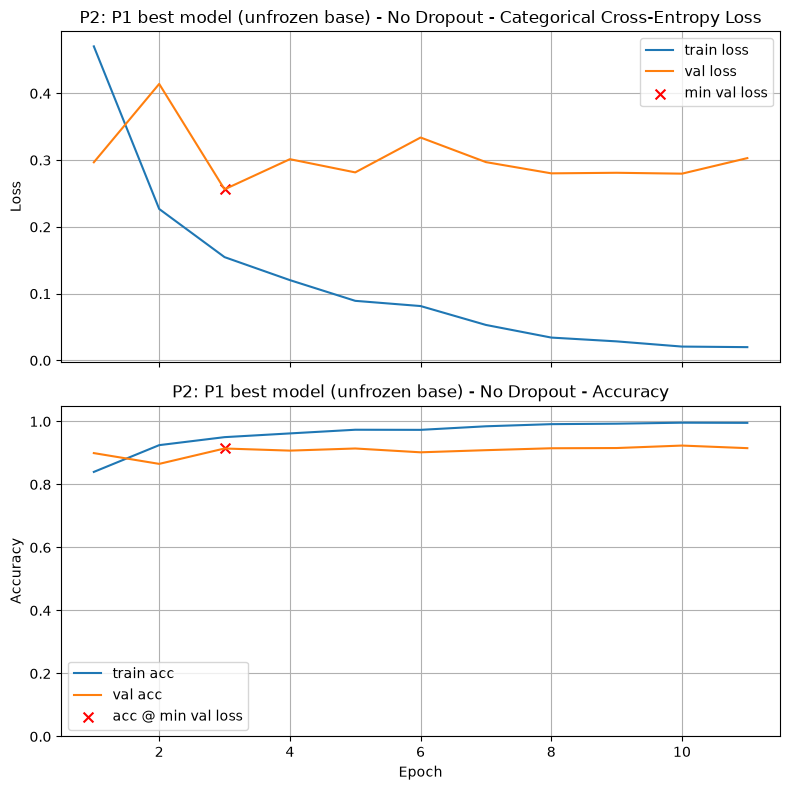

Final Training Loss:            0.0199
Final Training Accuracy:        0.9954
Final Validation Loss:          0.3030
Final Validation Accuracy:      0.9151
Minimum Validation Loss:        0.2563 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9141

Test Loss: 0.2710
Test Accuracy: 0.9070

Validation-Test Gap (accuracy): 0.007051

Execution Time: 00:23:43


In [42]:
model_unfrozen_baseline12 = make_base_model_pooled(trainable=True)

p1_best12 = models.Sequential([
    model_unfrozen_baseline12,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    # Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    # Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best12, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - No Dropout")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_6302/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P2: P1 best model (unfrozen base) - L2 reg, No Dropout

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 578s 1s/step - accuracy: 0.8359 - loss: 0.5676 - val_accuracy: 0.8292 - val_loss: 0.5481 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 99s 282ms/step - accuracy: 0.9228 - loss: 0.3255 - val_accuracy: 0.8616 - val_loss: 0.4718 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 284ms/step - accuracy: 0.9465 - loss: 0.2539 - val_accuracy: 0.8955 - val_loss: 0.4123 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 100s 282ms/step - accuracy: 0.9621 - loss: 0.2133 - val_accuracy: 0.9126 - val_loss: 0.3700 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 98s 278ms/step - accuracy: 0.9706 - loss: 0.1843 - val_accuracy: 0.8937 - val_loss: 0.4412 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 97s 277ms/step - accuracy: 0.9716 - loss: 0.1822 - val_accuracy: 0.8948 - val_loss: 0.4257 - learning_

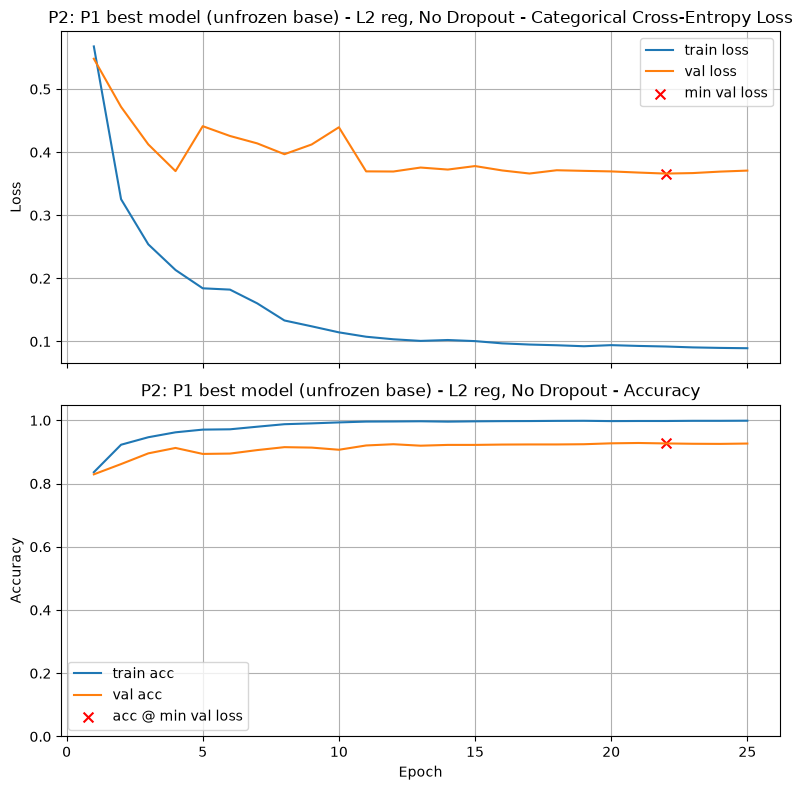

Final Training Loss:            0.0893
Final Training Accuracy:        0.9988
Final Validation Loss:          0.3708
Final Validation Accuracy:      0.9265
Minimum Validation Loss:        0.3661 (Epoch 22)
Validation Accuracy @ Min Loss: 0.9269

Test Loss: 0.3741
Test Accuracy: 0.9267

Validation-Test Gap (accuracy): 0.000223

Execution Time: 00:48:29


In [43]:
model_unfrozen_baseline13 = make_base_model_pooled(trainable=True)

p1_best13 = models.Sequential([
    model_unfrozen_baseline13,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    # Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    # Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p1_best13, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title="P2: P1 best model (unfrozen base) - L2 reg, No Dropout")

In [ ]:
# Updating results manually to save progress after kernel consistently crashing

results.update({
    'P2: P1 best model (unfrozen base) - L2 reg, No Dropout': (0.9269, 22),
    'P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau': (0.9255, 6),
    'P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg': (0.9240, 7),
    'P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg on Dense 512': (0.9208, 6),
    'P2: P1 best model (unfrozen base) - LR (3e-5)': (0.9205, 6),
    'P2: P1 best model (unfrozen base)': (0.9201, 4),
    'P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg, patience 3': (0.9198, 7),
    'P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512': (0.9194, 6),
    'P2: P1 best model (unfrozen base) - LR (1e-5)': (0.9162, 17),
    'P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg': (0.9158,	5),
    'P2: P1 best model (unfrozen base) - No Dropout': (0.9141, 3),
    'P2: P1 best model (unfrozen base) - LR (3e-4), no ReduceLROnPlateau, L2 reg, patience 3': (0.8531,	2),
    'P2: P1 best model (unfrozen base) - LR (3e-4), no ReduceLROnPlateau, patience 3': (0.7379,	1)
})

In [17]:
print_results()

P2: P1 best model (unfrozen base) - L2 reg, No Dropout	0.9269	22
P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau	0.9255	6
P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg	0.9240	7
P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg on Dense 512	0.9208	6
P2: P1 best model (unfrozen base) - LR (3e-5)	0.9205	6
P2: P1 best model (unfrozen base)       	0.9201	4
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg, patience 3	0.9198	7
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512	0.9194	6
P2: P1 best model (unfrozen base) - LR (1e-5)	0.9162	17
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg	0.9158	5
P1: Three Tier Funnel with l2reg, LR (5e-4), Patience (8), ReduceLROnPlateau	0.9148	6
P2: P1 best model (unfrozen base) - No Dropout	0.9141	3
P1: Two Tier Funnel (no reg), LR (1e-4), Patience (8)	0.9137	11
P1: Two Tier Funnel with l2reg, LR (1e-4), Patience (8), ReduceLROnPlatea

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which fully unfrozen configuration worked best for you, and what does that suggest about the role of head design and training hyperparameters when the MobileNetV2 backbone is trainable?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (e.g., dense layers, dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about training a model when the pretrained backbone is fully unfrozen.



**Your paragraph here (5pts):**

> 

**Validation accuracy here (15 pts):**

In [18]:
# Set a2 to the validation accuracy found by your best model for this problem. 

a2 = results['P2: P1 best model (unfrozen base) - L2 reg, No Dropout'][0]             # Replace 0.0 with your answer

In [19]:
# Graded Answer
# DO NOT change this cell in any way and do not make any other assignments to variable a1a in this problem       

print(f'a2 = {a2:.4f}') 

a2 = 0.9269


## Problem Three — Unfreezing Layers

**Goal.** Keep most of the pretrained MobileNetV2 backbone frozen and **unfreeze only the last \(N\) layers** for fine-tuning.

(In Problem 4, you will instead explore unfreezing the top **\(K\) MobileNetV2 blocks**.)

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a 1280-D feature vector. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the last \(N\) layers using the following approach:

```python
N = 20

base_model = make_base_model_pooled()
base_model.trainable = True

for layer in base_model.layers[:-N]:
    layer.trainable = False
```

### To Do

1. **Design at least three experiments** in which only the last \(N\) backbone layers are unfrozen. Vary one or more of the following:

   * \(N \in \{20, 40, 80\}\)
   * **Head architecture** (select one from Problem 1)
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the three experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more layers are unfrozen,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of partial unfreezing**, not to identify a single globally optimal configuration.

3. **Select one configuration** (choice of \(N\) and training strategy), set `DATA_FRACTION = 1.0`, and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* As more layers are unfrozen, the model typically becomes **more sensitive to the learning rate**.
* Learning rates around \(1\times10^{-5}\) to \(3\times10^{-5}\) are reasonable starting points for partial fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 20 Layers Unfrozen + Best P1 head

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 52ms/step - accuracy: 0.8011 - loss: 0.5779 - val_accuracy: 0.8727 - val_loss: 0.3870 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9019 - loss: 0.2916 - val_accuracy: 0.8894 - val_loss: 0.3287 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.9248 - loss: 0.2297 - val_accuracy: 0.8905 - val_loss: 0.3276 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9397 - loss: 0.1818 - val_accuracy: 0.8991 - val_loss: 0.3167 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.9540 - loss: 0.1429 - val_accuracy: 0.9073 - val_loss: 0.2966 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9636 - loss: 0.1145 - val_accuracy: 0.9158 - val_loss: 0.2696 - learning_rate: 1.0000e-04
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - a

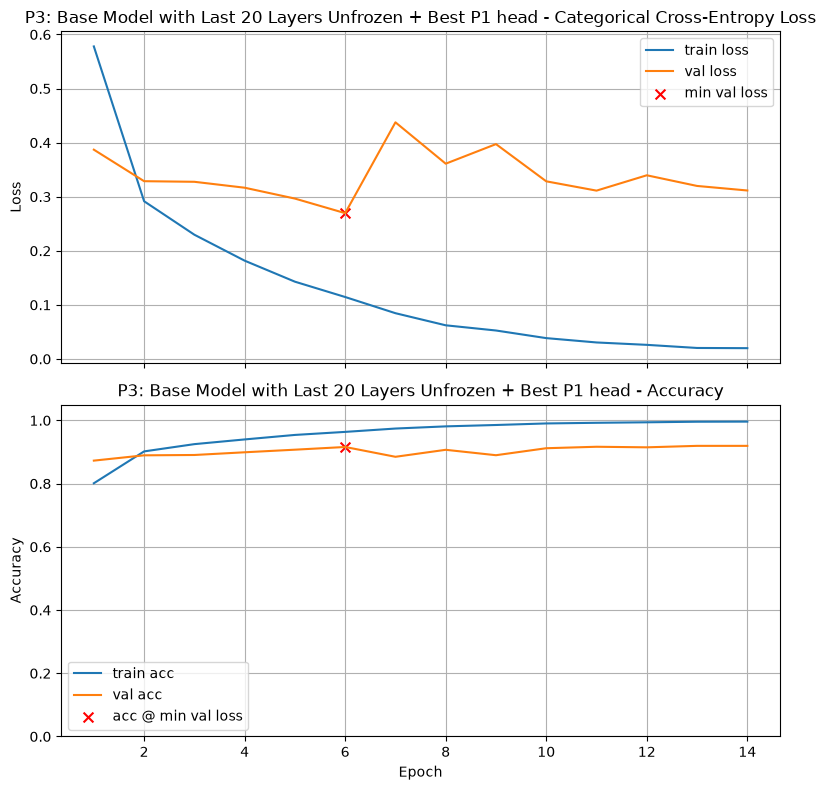

Final Training Loss:            0.0199
Final Training Accuracy:        0.9961
Final Validation Loss:          0.3115
Final Validation Accuracy:      0.9194
Minimum Validation Loss:        0.2696 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9158

Test Loss: 0.2544
Test Accuracy: 0.9143

Validation-Test Gap (accuracy): 0.001501

Execution Time: 00:03:51


In [20]:
N = 20

base = make_base_model_pooled()
base.trainable = True

for layer in base.layers[:-N]:
    layer.trainable = False


p3_model = models.Sequential([
    base,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 40 Layers Unfrozen + Best P1 head

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - accuracy: 0.7979 - loss: 0.5941 - val_accuracy: 0.8745 - val_loss: 0.3593 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.9102 - loss: 0.2841 - val_accuracy: 0.8984 - val_loss: 0.3032 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9352 - loss: 0.2005 - val_accuracy: 0.9055 - val_loss: 0.2789 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.9549 - loss: 0.1416 - val_accuracy: 0.9023 - val_loss: 0.3117 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.9731 - loss: 0.0939 - val_accuracy: 0.8994 - val_loss: 0.3427 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9770 - loss: 0.0755
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.

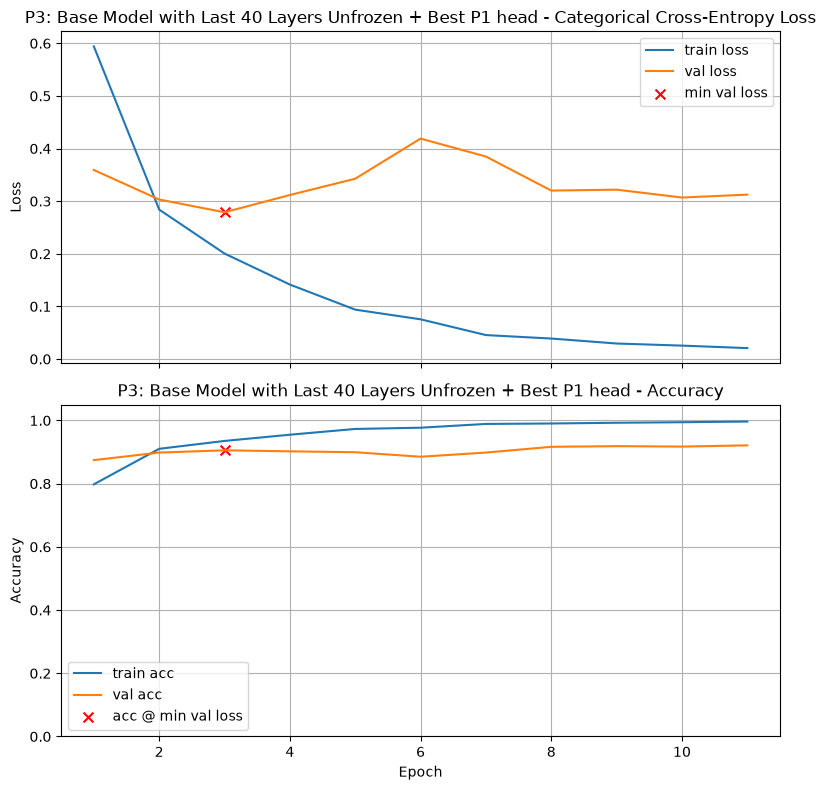

Final Training Loss:            0.0208
Final Training Accuracy:        0.9965
Final Validation Loss:          0.3124
Final Validation Accuracy:      0.9212
Minimum Validation Loss:        0.2789 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9055

Test Loss: 0.2562
Test Accuracy: 0.9127

Validation-Test Gap (accuracy): 0.007175

Execution Time: 00:06:16


In [21]:
N = 40

base2 = make_base_model_pooled()
base2.trainable = True

for layer in base2.layers[:-N]:
    layer.trainable = False


p3_model2 = models.Sequential([
    base2,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model2, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 80 Layers Unfrozen + Best P1 head

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 62s 153ms/step - accuracy: 0.7947 - loss: 0.5963 - val_accuracy: 0.8720 - val_loss: 0.3452 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 144ms/step - accuracy: 0.9093 - loss: 0.2841 - val_accuracy: 0.9201 - val_loss: 0.2489 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 143ms/step - accuracy: 0.9321 - loss: 0.2066 - val_accuracy: 0.9155 - val_loss: 0.2556 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 51s 144ms/step - accuracy: 0.9496 - loss: 0.1573 - val_accuracy: 0.9208 - val_loss: 0.2501 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9662 - loss: 0.1077
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
351/351 ━━━━━━━━━━━━━━━━━━━━ 51s 145ms/step - accuracy: 0.9662 - loss: 0.1077 - val_accuracy: 0.8994 - val_loss: 0.3477 - learning_rat

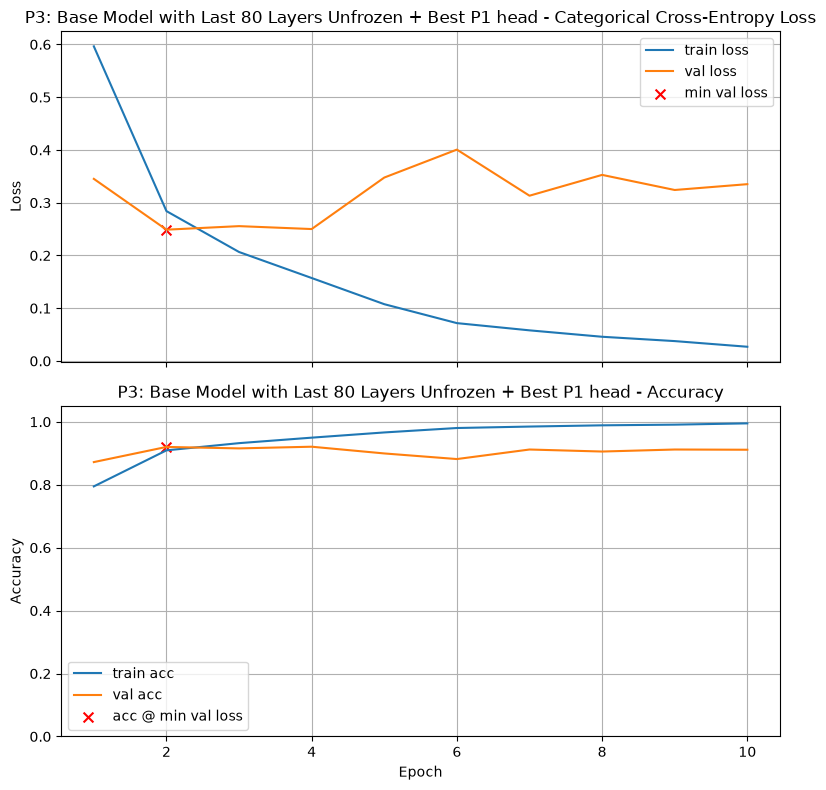

Final Training Loss:            0.0270
Final Training Accuracy:        0.9950
Final Validation Loss:          0.3351
Final Validation Accuracy:      0.9112
Minimum Validation Loss:        0.2489 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9201

Test Loss: 0.2307
Test Accuracy: 0.9127

Validation-Test Gap (accuracy): 0.007447

Execution Time: 00:08:40


In [22]:
N = 80

base3 = make_base_model_pooled()
base3.trainable = True

for layer in base3.layers[:-N]:
    layer.trainable = False


p3_model3 = models.Sequential([
    base3,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model3, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 20 Layers Unfrozen

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8680 - loss: 0.3803 - val_accuracy: 0.8866 - val_loss: 0.3675 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.9332 - loss: 0.1900 - val_accuracy: 0.8841 - val_loss: 0.3567 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.9617 - loss: 0.1156 - val_accuracy: 0.9123 - val_loss: 0.2931 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.9751 - loss: 0.0781 - val_accuracy: 0.9034 - val_loss: 0.3289 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.9855 - loss: 0.0516 - val_accuracy: 0.9137 - val_loss: 0.2838 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.9915 - loss: 0.0345 - val_accuracy: 0.9180 - val_loss: 0.2814 - learning_rate: 1.0000e-04


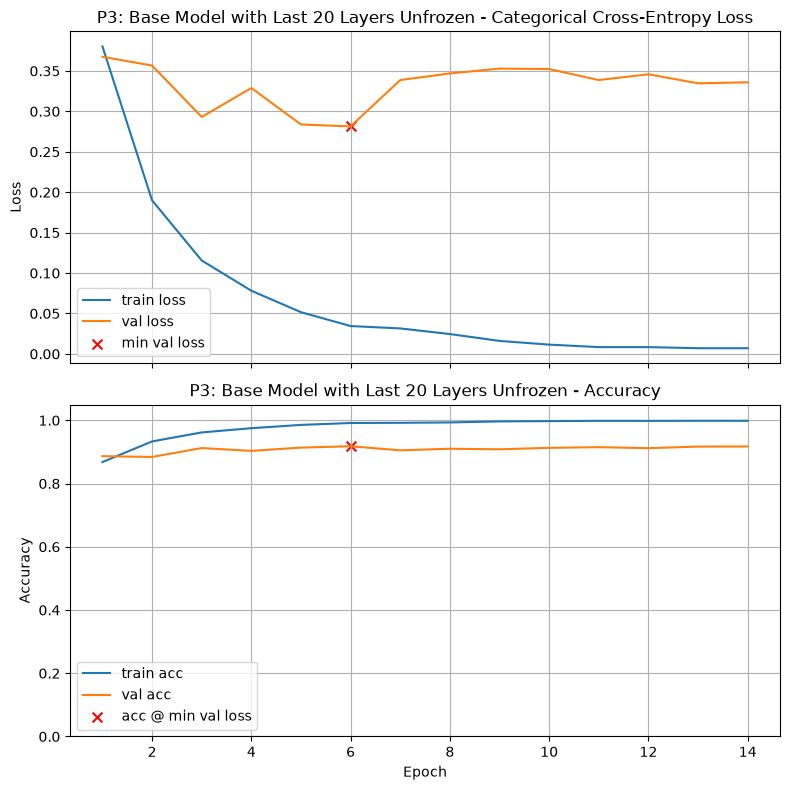

Final Training Loss:            0.0070
Final Training Accuracy:        0.9985
Final Validation Loss:          0.3359
Final Validation Accuracy:      0.9173
Minimum Validation Loss:        0.2814 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9180

Test Loss: 0.2768
Test Accuracy: 0.9230

Validation-Test Gap (accuracy): 0.005026

Execution Time: 00:03:21


In [23]:
N = 20

base4 = make_base_model_pooled()
base4.trainable = True

for layer in base4.layers[:-N]:
    layer.trainable = False


p3_model4 = models.Sequential([
    base4,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model4, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 40 Layers Unfrozen

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - accuracy: 0.8588 - loss: 0.3941 - val_accuracy: 0.8823 - val_loss: 0.3957 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9471 - loss: 0.1537 - val_accuracy: 0.8987 - val_loss: 0.3212 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9728 - loss: 0.0873 - val_accuracy: 0.9141 - val_loss: 0.2880 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9864 - loss: 0.0471 - val_accuracy: 0.9098 - val_loss: 0.3369 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9906 - loss: 0.0314 - val_accuracy: 0.9148 - val_loss: 0.3365 - learning_rate: 1.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9916 - loss: 0.0287
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e

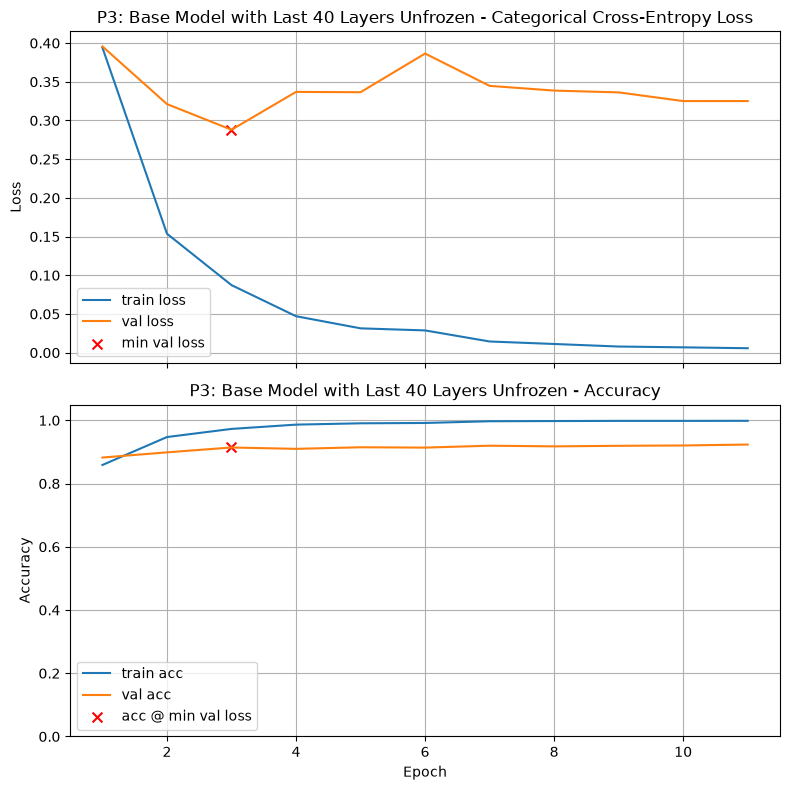

Final Training Loss:            0.0057
Final Training Accuracy:        0.9984
Final Validation Loss:          0.3251
Final Validation Accuracy:      0.9233
Minimum Validation Loss:        0.2880 (Epoch 3)
Validation Accuracy @ Min Loss: 0.9141

Test Loss: 0.2690
Test Accuracy: 0.9087

Validation-Test Gap (accuracy): 0.005385

Execution Time: 00:03:42


In [24]:
N = 40

base5 = make_base_model_pooled()
base5.trainable = True

for layer in base5.layers[:-N]:
    layer.trainable = False


p3_model5 = models.Sequential([
    base5,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model5, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 80 Layers Unfrozen

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 63s 153ms/step - accuracy: 0.8550 - loss: 0.4043 - val_accuracy: 0.8459 - val_loss: 0.5301 - learning_rate: 1.0000e-04
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 132ms/step - accuracy: 0.9435 - loss: 0.1658 - val_accuracy: 0.9123 - val_loss: 0.2835 - learning_rate: 1.0000e-04
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 133ms/step - accuracy: 0.9711 - loss: 0.0882 - val_accuracy: 0.9073 - val_loss: 0.3075 - learning_rate: 1.0000e-04
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 133ms/step - accuracy: 0.9809 - loss: 0.0605 - val_accuracy: 0.8937 - val_loss: 0.3684 - learning_rate: 1.0000e-04
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9850 - loss: 0.0466
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 134ms/step - accuracy: 0.9850 - loss: 0.0466 - val_accuracy: 0.9101 - val_loss: 0.3205 - learning_rate: 1.0000e-04
E

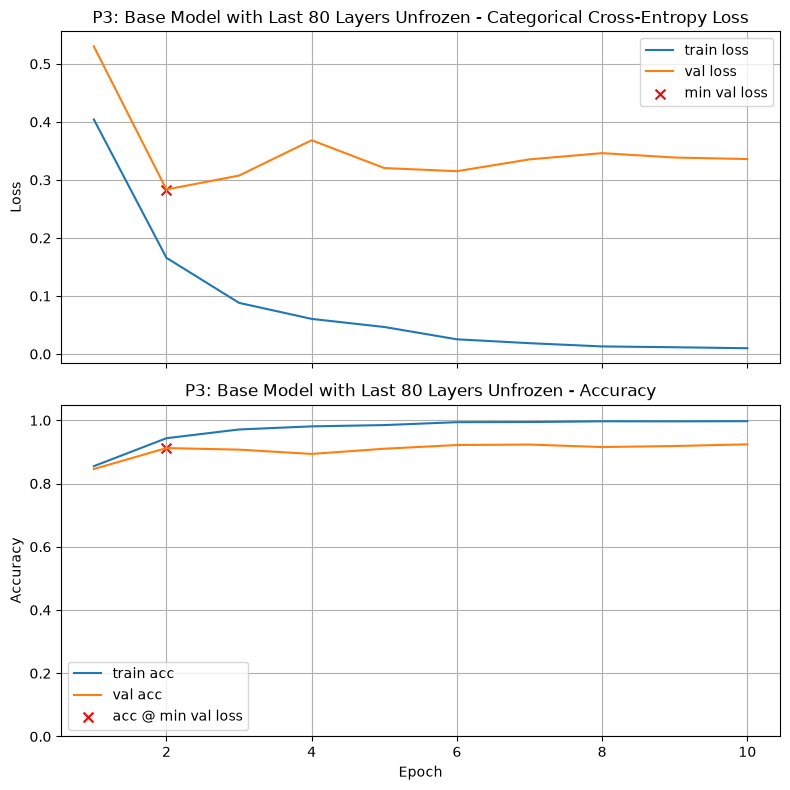

Final Training Loss:            0.0100
Final Training Accuracy:        0.9972
Final Validation Loss:          0.3360
Final Validation Accuracy:      0.9240
Minimum Validation Loss:        0.2835 (Epoch 2)
Validation Accuracy @ Min Loss: 0.9123

Test Loss: 0.2870
Test Accuracy: 0.9077

Validation-Test Gap (accuracy): 0.004601

Execution Time: 00:08:14


In [25]:
N = 80

base6 = make_base_model_pooled()
base6.trainable = True

for layer in base6.layers[:-N]:
    layer.trainable = False


p3_model6 = models.Sequential([
    base6,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model6, lr_schedule=1e-4, patience=8, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 20 Layers Unfrozen + Best P1 head + No ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.7931 - loss: 0.6090 - val_accuracy: 0.8645 - val_loss: 0.3842
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.8990 - loss: 0.3064 - val_accuracy: 0.8880 - val_loss: 0.3208
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9211 - loss: 0.2319 - val_accuracy: 0.8955 - val_loss: 0.3130
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9388 - loss: 0.1903 - val_accuracy: 0.9151 - val_loss: 0.2455
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.9548 - loss: 0.1411 - val_accuracy: 0.9151 - val_loss: 0.2592
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.9638 - loss: 0.1172 - val_accuracy: 0.9083 - val_loss: 0.2946
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.9755 - loss: 0.0863 - val_accuracy: 0.9151 - val_loss: 0.2843

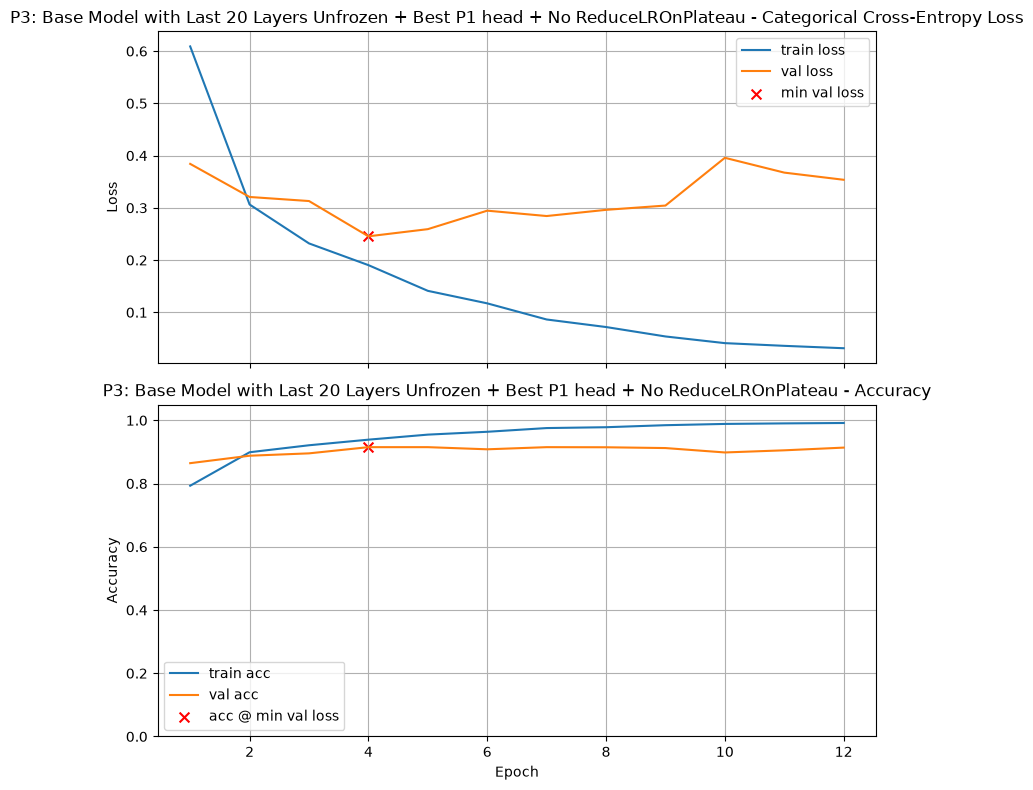

Final Training Loss:            0.0313
Final Training Accuracy:        0.9915
Final Validation Loss:          0.3537
Final Validation Accuracy:      0.9137
Minimum Validation Loss:        0.2455 (Epoch 4)
Validation Accuracy @ Min Loss: 0.9151

Test Loss: 0.2302
Test Accuracy: 0.9243

Validation-Test Gap (accuracy): 0.009212

Execution Time: 00:03:29


In [26]:
N = 20

base7 = make_base_model_pooled()
base7.trainable = True

for layer in base7.layers[:-N]:
    layer.trainable = False


p3_model7 = models.Sequential([
    base7,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model7, lr_schedule=1e-4, patience=8, title=f"P3: Base Model with Last {N} Layers Unfrozen + Best P1 head + No ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P3: Base Model with Last 20 Layers Unfrozen + Best P1 head, Patience (3), LR (1e-5)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.4473 - loss: 1.4379 - val_accuracy: 0.7222 - val_loss: 0.7607 - learning_rate: 1.0000e-05
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.7482 - loss: 0.7462 - val_accuracy: 0.8245 - val_loss: 0.4914 - learning_rate: 1.0000e-05
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.8246 - loss: 0.5547 - val_accuracy: 0.8638 - val_loss: 0.3894 - learning_rate: 1.0000e-05
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 46ms/step - accuracy: 0.8529 - loss: 0.4657 - val_accuracy: 0.8759 - val_loss: 0.3447 - learning_rate: 1.0000e-05
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.8631 - loss: 0.4188 - val_accuracy: 0.8887 - val_loss: 0.3131 - learning_rate: 1.0000e-05
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.8797 - loss: 0.3779 - val_accuracy: 0.8934 - val_l

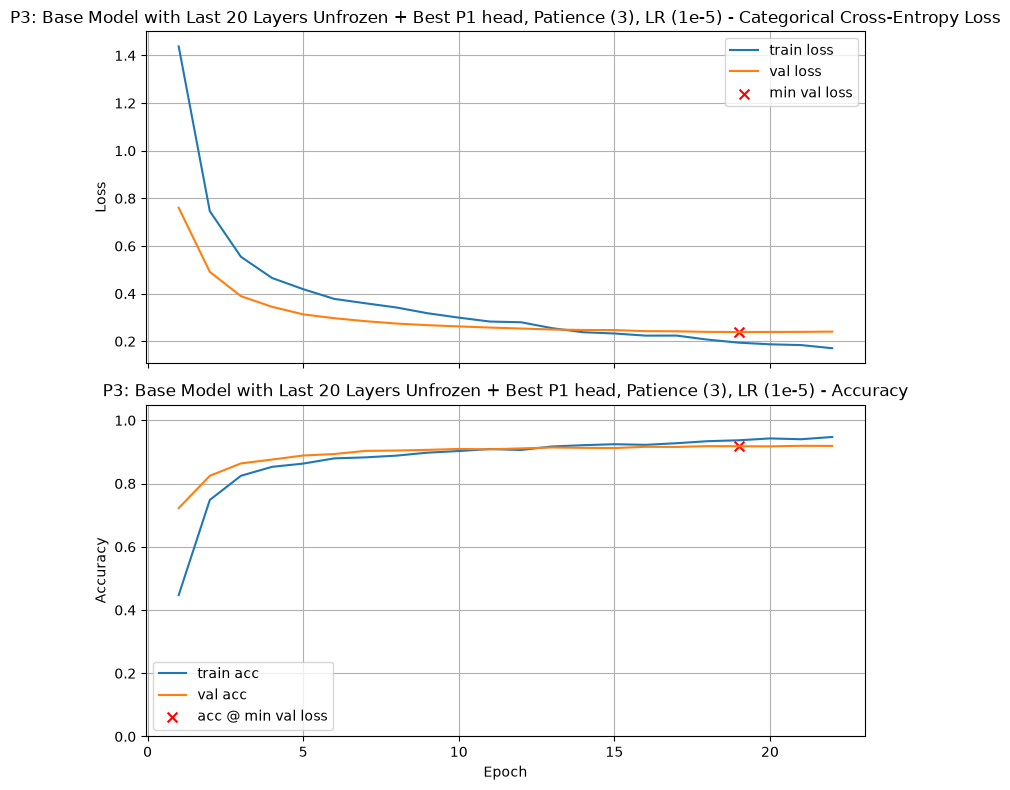

Final Training Loss:            0.1708
Final Training Accuracy:        0.9473
Final Validation Loss:          0.2406
Final Validation Accuracy:      0.9190
Minimum Validation Loss:        0.2390 (Epoch 19)
Validation Accuracy @ Min Loss: 0.9180

Test Loss: 0.2263
Test Accuracy: 0.9170

Validation-Test Gap (accuracy): 0.000974

Execution Time: 00:06:12


In [27]:
N = 20

base8 = make_base_model_pooled()
base8.trainable = True

for layer in base8.layers[:-N]:
    layer.trainable = False


p3_model8 = models.Sequential([
    base8,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p3_model8, lr_schedule=1e-5, patience=3, callbacks=[reduce_lr], title=f"P3: Base Model with Last {N} Layers Unfrozen + Best P1 head, Patience (3), LR (1e-5)")

In [31]:
print_results()

P2: P1 best model (unfrozen base) - L2 reg, No Dropout	0.9269	22
P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau	0.9255	6
P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg	0.9240	7
P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg on Dense 512	0.9208	6
P2: P1 best model (unfrozen base) - LR (3e-5)	0.9205	6
P3: Base Model with Last 80 Layers Unfrozen + Best P1 head	0.9201	2
P2: P1 best model (unfrozen base)       	0.9201	4
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg, patience 3	0.9198	7
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512	0.9194	6
P3: Base Model with Last 20 Layers Unfrozen	0.9180	6
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head, Patience (3), LR (1e-5)	0.9180	19
P2: P1 best model (unfrozen base) - LR (1e-5)	0.9162	17
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head	0.9158	6
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg	0.915

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which partial-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(N\) layers of MobileNetV2?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(N\) of unfrozen layers**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about how much of a pretrained backbone should be unfrozen during fine-tuning.



**Your paragraph here (5pts):**

> 

**Validation accuracy here (15 pts):**

In [32]:
# Set a3 to the validation accuracy found by your best model for this problem. 

a3 = results['P3: Base Model with Last 80 Layers Unfrozen + Best P1 head'][0]             # Replace 0.0 with your answer

In [33]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3 = {a3:.4f}') 

a3 = 0.9201


## Problem Four — Unfreezing Convolution Blocks

**Goal.** Fine-tune MobileNetV2 by unfreezing the **last $K$ convolutional stages/blocks** rather than the last $N$ individual layers, as in Problem 3. This provides a more meaningful way to control how much of the pretrained backbone is allowed to adapt.

**Setup.** The backbone is MobileNetV2 with `include_top=False` and `pooling="avg"`, so it outputs a **1280-D feature vector**. Do **not** add another pooling layer in the head.

After creating the backbone, unfreeze the top $K$ stages using the following approach:

```python
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 3

base_model = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_model.trainable = True

for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )
```

For example:

* $K=1$ unfreezes only `Conv_1`.
* $K=2$ unfreezes `block_16` and `Conv_1`.
* $K=3$ unfreezes `block_15`, `block_16`, and `Conv_1`.

### To Do

1. **Design at least three experiments** in which the **last $K$ stages are unfrozen**. Vary one or more of the following:

   * $K \in {1, 2, 3, 5}$
     *(Here, $K$ counts stages/blocks, not individual Keras layers.)*
   * **BatchNormalization strategy:** keep BN frozen vs. allow BN layers in the selected blocks to be trainable.
   * **Head architecture** (select one from Problem 1).
   * **Learning rate**
   * **EarlyStopping** parameters
   * **Regularization:** Dropout and/or L2
   * **ReduceLROnPlateau:** on vs. off

2. **Run and compare** the experiments using a reduced value of `DATA_FRACTION`, focusing on:

   * how performance changes as more blocks are unfrozen,
   * whether making BatchNormalization layers trainable helps or destabilizes training,
   * training stability and convergence,
   * and validation performance trends.

   Use these runs to **understand the effect of block-level fine-tuning** and to narrow down reasonable configurations, rather than to identify a single globally optimal setting.

3. **Select one configuration** (choice of $K$, BatchNormalization strategy, and training strategy), set:

```python
DATA_FRACTION = 1.0
```

and rerun the notebook on the full dataset. Use this run when answering the graded questions.

### Notes

* Your backbone was built with `pooling="avg"`, so **do not** add another `GlobalAveragePooling2D()` layer.
* Unfreezing more blocks generally makes training **more sensitive to the learning rate** and may increase instability; this is part of what you are investigating.
* Learning rates around $1\times10^{-5}$ to $3\times10^{-5}$ are reasonable starting points for block-level fine-tuning.
* Small shifts in relative performance between reduced-data experiments and the full dataset are expected.
* Construct a **new backbone/model for each experiment** so that experiments do not inherit weights from previous runs.



/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to Conv_1 Unfrozen + Best P1 head

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.8719 - loss: 0.3575 - val_accuracy: 0.9058 - val_loss: 0.2544 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9087 - loss: 0.2514 - val_accuracy: 0.9101 - val_loss: 0.2600 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9234 - loss: 0.2080 - val_accuracy: 0.9044 - val_loss: 0.2597 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9351 - loss: 0.1765
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9351 - loss: 0.1765 - val_accuracy: 0.9105 - val_loss: 0.2700 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9543 - loss: 0.1238 - val_accuracy: 0.9123 - val_loss: 0.2538 - learning_rate: 5.0000e-04
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9656 - loss:

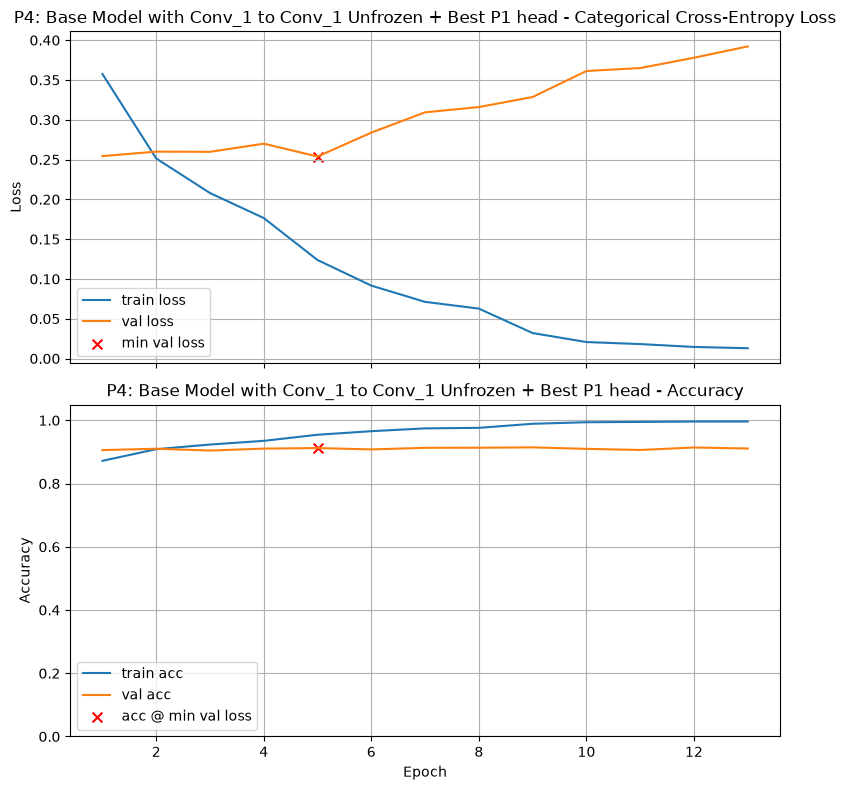

Final Training Loss:            0.0130
Final Training Accuracy:        0.9963
Final Validation Loss:          0.3921
Final Validation Accuracy:      0.9108
Minimum Validation Loss:        0.2538 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9123

Test Loss: 0.2377
Test Accuracy: 0.9163

Validation-Test Gap (accuracy): 0.004065

Execution Time: 00:02:31


In [34]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 1

base_mod = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod.trainable = True

for layer in base_mod.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model = models.Sequential([
    base_mod,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head

Epoch 1/500


/opt/anaconda3/envs/tensorflow_mac/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.8571 - loss: 0.4141 - val_accuracy: 0.7821 - val_loss: 0.6064 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9065 - loss: 0.2693 - val_accuracy: 0.8777 - val_loss: 0.3645 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9167 - loss: 0.2434 - val_accuracy: 0.7468 - val_loss: 0.8767 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9247 - loss: 0.2127 - val_accuracy: 0.8060 - val_loss: 0.5635 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9347 - loss: 0.1896
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9347 - loss: 0.1896 - val_accuracy: 0.8099 - val_loss: 0.5546 - learning_rate: 0.0010
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.9516 - loss: 0.1

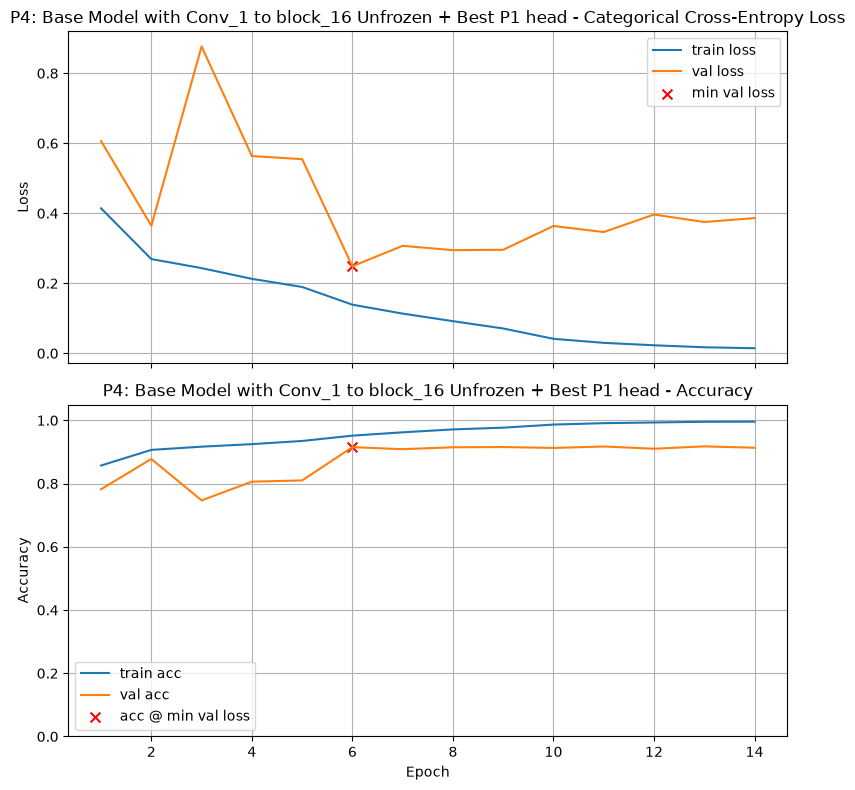

Final Training Loss:            0.0145
Final Training Accuracy:        0.9957
Final Validation Loss:          0.3863
Final Validation Accuracy:      0.9133
Minimum Validation Loss:        0.2488 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9151

Test Loss: 0.2350
Test Accuracy: 0.9220

Validation-Test Gap (accuracy): 0.006879

Execution Time: 00:02:43


In [35]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod2 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod2.trainable = True

for layer in base_mod2.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model2 = models.Sequential([
    base_mod2,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model2, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_15 Unfrozen + Best P1 head

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.3741 - loss: 1.4885 - val_accuracy: 0.1619 - val_loss: 136.5252 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.2148 - loss: 1.7147 - val_accuracy: 0.1619 - val_loss: 146.5576 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.1777 - loss: 1.7917 - val_accuracy: 0.1562 - val_loss: 36.3870 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.1783 - loss: 1.7912 - val_accuracy: 0.1619 - val_loss: 9.3265 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.1790 - loss: 1.7910 - val_accuracy: 0.1712 - val_loss: 2.3418 - learning_rate: 0.0010
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.1790 - loss: 1.7909 - val_accuracy: 0.1712 - val_loss: 1.7909 - learning_rate: 0.0010


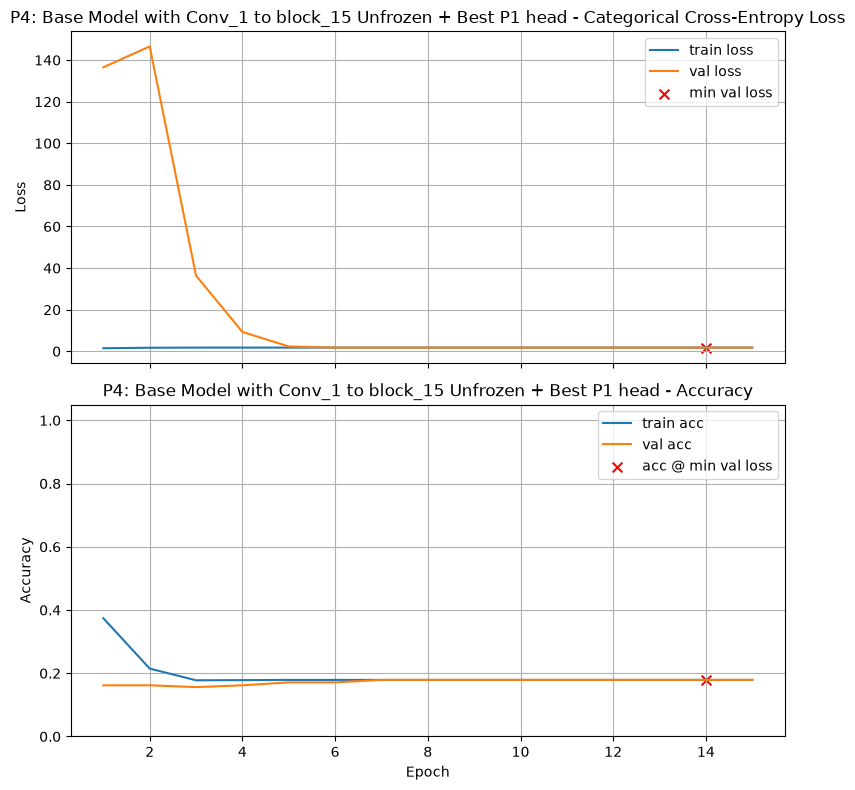

Final Training Loss:            1.7908
Final Training Accuracy:        0.1790
Final Validation Loss:          1.7908
Final Validation Accuracy:      0.1790
Minimum Validation Loss:        1.7908 (Epoch 14)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.7899
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 00:03:07


In [36]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 3

base_mod3 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod3.trainable = True

for layer in base_mod3.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model3 = models.Sequential([
    base_mod3,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model3, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_13 Unfrozen + Best P1 head

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.1899 - loss: 1.8256 - val_accuracy: 0.1698 - val_loss: 45.3290 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.1740 - loss: 1.7955 - val_accuracy: 0.1698 - val_loss: 44.4222 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.1718 - loss: 1.7918 - val_accuracy: 0.1712 - val_loss: 11.4704 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.1759 - loss: 1.7913 - val_accuracy: 0.1790 - val_loss: 31.8673 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.1784 - loss: 1.7911 - val_accuracy: 0.1698 - val_loss: 3.1298 - learning_rate: 0.0010
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - accuracy: 0.1788 - loss: 1.7911 - val_accuracy: 0.1790 - val_loss: 1.7908 - learning_rate: 0.0010
E

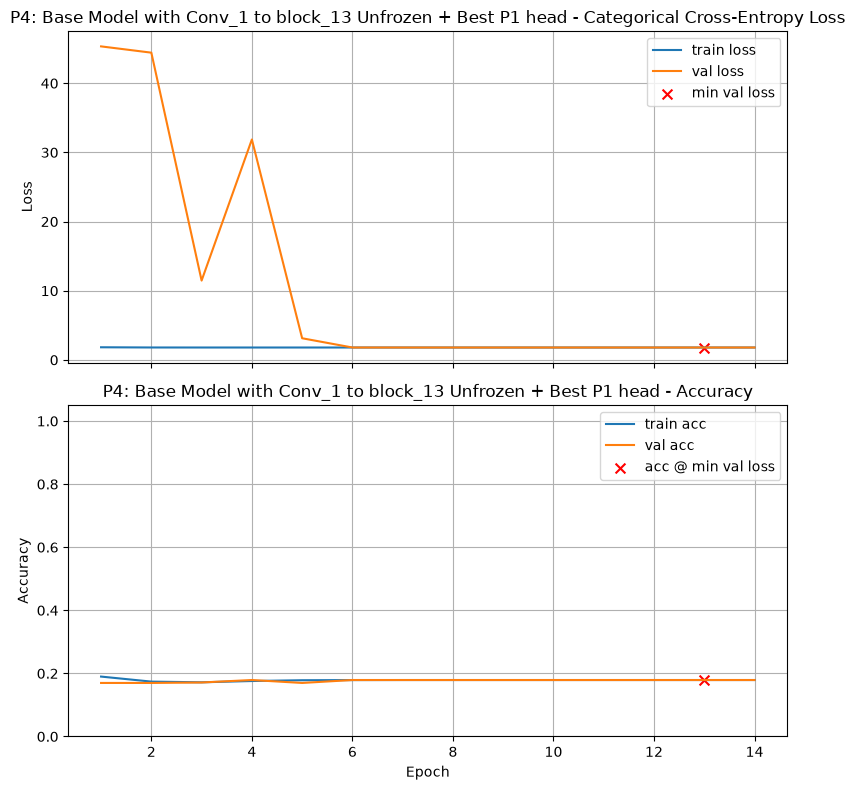

Final Training Loss:            1.7908
Final Training Accuracy:        0.1790
Final Validation Loss:          1.7908
Final Validation Accuracy:      0.1790
Minimum Validation Loss:        1.7908 (Epoch 13)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.7900
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 00:03:18


In [37]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 5

base_mod4 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod4.trainable = True

for layer in base_mod4.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model4 = models.Sequential([
    base_mod4,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model4, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_13 Unfrozen

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.1674 - loss: 1.8499 - val_accuracy: 0.1790 - val_loss: 1.7971 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.1663 - loss: 1.8090 - val_accuracy: 0.1712 - val_loss: 1.7973 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.1652 - loss: 1.8075 - val_accuracy: 0.1619 - val_loss: 1.8032 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1704 - loss: 1.8169
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.1704 - loss: 1.8169 - val_accuracy: 0.1562 - val_loss: 1.8129 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.1654 - loss: 1.8005 - val_accuracy: 0.1712 - val_loss: 1.8019 - learning_rate: 5.0000e-04
Epoch 6/500
351/351

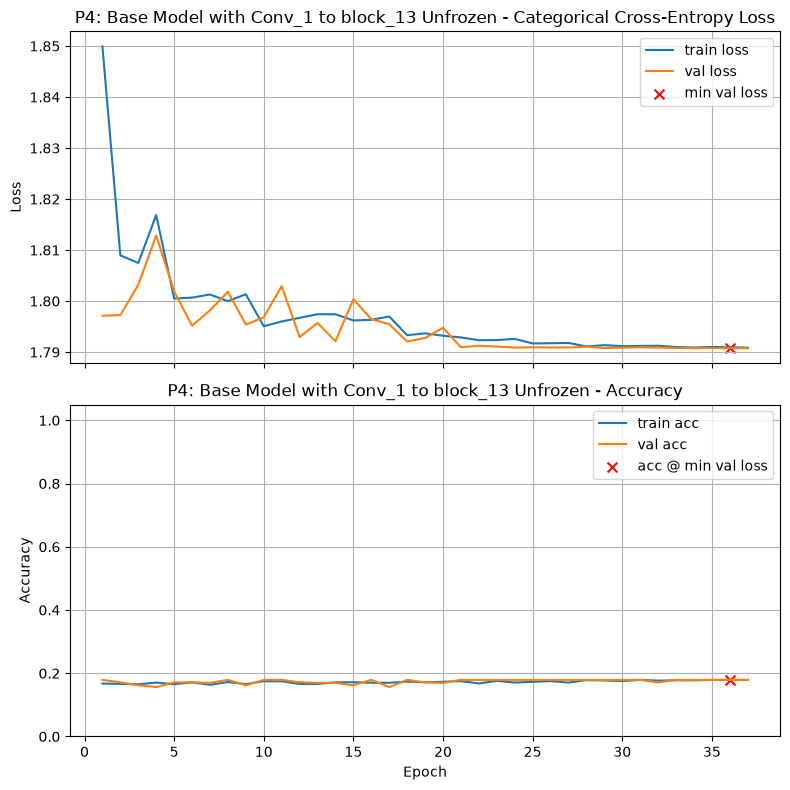

Final Training Loss:            1.7909
Final Training Accuracy:        0.1790
Final Validation Loss:          1.7908
Final Validation Accuracy:      0.1790
Minimum Validation Loss:        1.7908 (Epoch 36)
Validation Accuracy @ Min Loss: 0.1790

Test Loss: 1.7900
Test Accuracy: 0.1750

Validation-Test Gap (accuracy): 0.004030

Execution Time: 00:06:59


In [38]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 5

base_mod5 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod5.trainable = True

for layer in base_mod5.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model5 = models.Sequential([
    base_mod5,
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model5, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_15 Unfrozen + Best P1 head with L2 regularization

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.7061 - loss: 0.8524 - val_accuracy: 0.1698 - val_loss: 62.9675 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8370 - loss: 0.5398 - val_accuracy: 0.6355 - val_loss: 1.3036 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8653 - loss: 0.4640 - val_accuracy: 0.6173 - val_loss: 2.1641 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8996 - loss: 0.3713 - val_accuracy: 0.8584 - val_loss: 0.4689 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9081 - loss: 0.3415 - val_accuracy: 0.4708 - val_loss: 2.7369 - learning_rate: 0.0010
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8980 - loss: 0.3717 - val_accuracy: 0.1569 - val_loss: 28.1195 - le

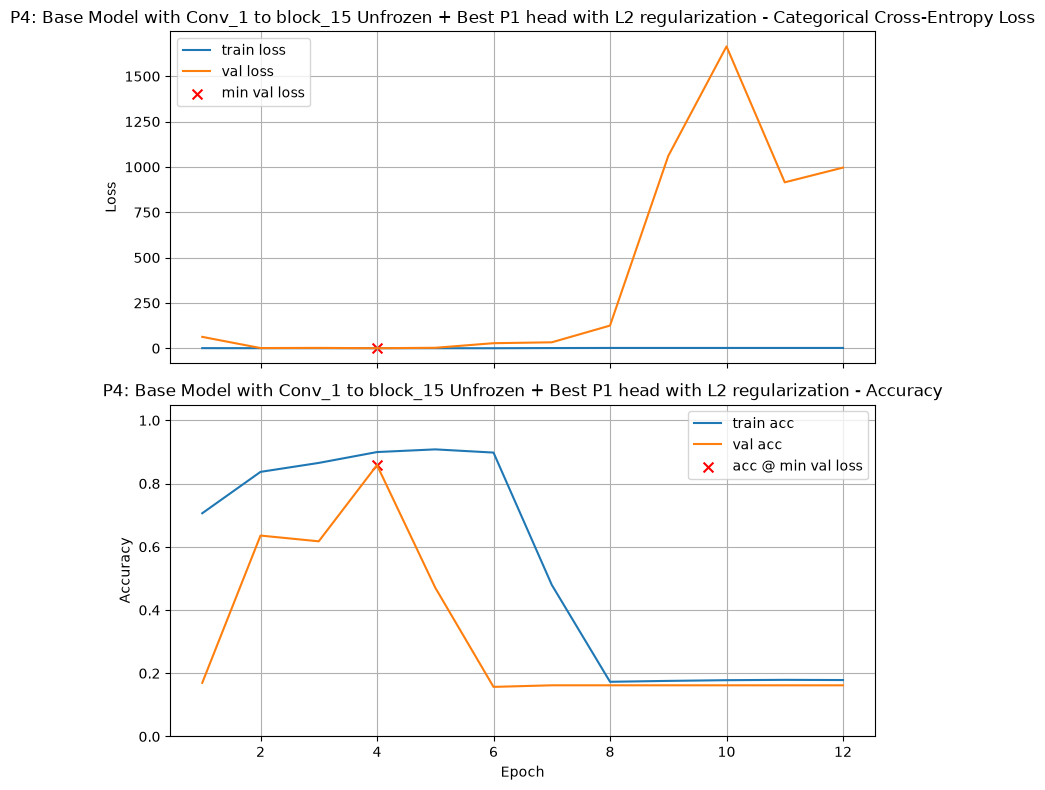

Final Training Loss:            1.8508
Final Training Accuracy:        0.1785
Final Validation Loss:          996.1608
Final Validation Accuracy:      0.1619
Minimum Validation Loss:        0.4689 (Epoch 4)
Validation Accuracy @ Min Loss: 0.8584

Test Loss: 0.4822
Test Accuracy: 0.8523

Validation-Test Gap (accuracy): 0.006083

Execution Time: 00:02:40


In [39]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 3

base_mod6 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod6.trainable = True

for layer in base_mod6.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model6 = models.Sequential([
    base_mod6,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model6, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with L2 regularization")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with L2 regularization

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.8424 - loss: 0.5341 - val_accuracy: 0.3306 - val_loss: 4.6407 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.8944 - loss: 0.3949 - val_accuracy: 0.4633 - val_loss: 2.7310 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9107 - loss: 0.3320 - val_accuracy: 0.6323 - val_loss: 1.6961 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9244 - loss: 0.2874 - val_accuracy: 0.7311 - val_loss: 0.7855 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9322 - loss: 0.2706 - val_accuracy: 0.7589 - val_loss: 0.8651 - learning_rate: 0.0010
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9413 - loss: 0.2384 - val_accuracy: 0.7414 - val_loss: 0.7442 - lear

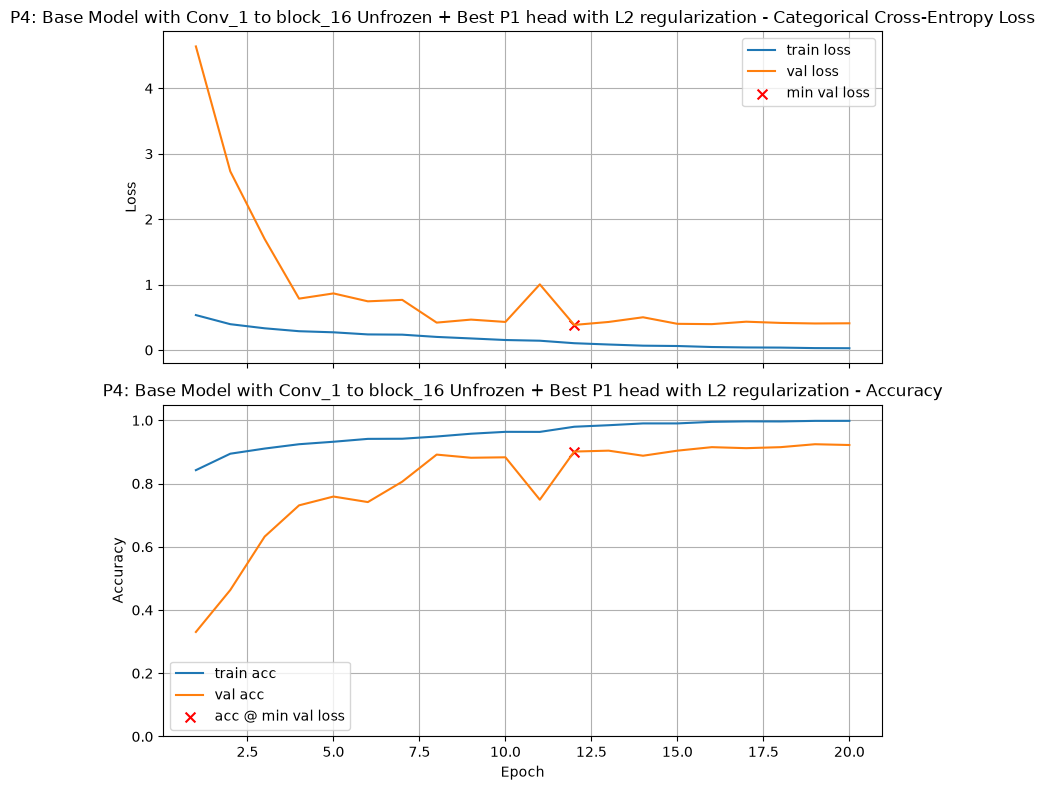

Final Training Loss:            0.0273
Final Training Accuracy:        0.9983
Final Validation Loss:          0.4085
Final Validation Accuracy:      0.9219
Minimum Validation Loss:        0.3836 (Epoch 12)
Validation Accuracy @ Min Loss: 0.9012

Test Loss: 0.3827
Test Accuracy: 0.8993

Validation-Test Gap (accuracy): 0.001879

Execution Time: 00:04:05


In [40]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod7 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod7.trainable = True

for layer in base_mod7.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model7 = models.Sequential([
    base_mod7,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model7, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with L2 regularization")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with L2 regularization, patience (6)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.8608 - loss: 0.5027 - val_accuracy: 0.2033 - val_loss: 4.6503 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9047 - loss: 0.3596 - val_accuracy: 0.8074 - val_loss: 0.5857 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9142 - loss: 0.3169 - val_accuracy: 0.8670 - val_loss: 0.4381 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9217 - loss: 0.2922 - val_accuracy: 0.9037 - val_loss: 0.3445 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9374 - loss: 0.2474 - val_accuracy: 0.8862 - val_loss: 0.4239 - learning_rate: 0.0010
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9469 - loss: 0.2143 - val_accuracy: 0.8969 - val_loss:

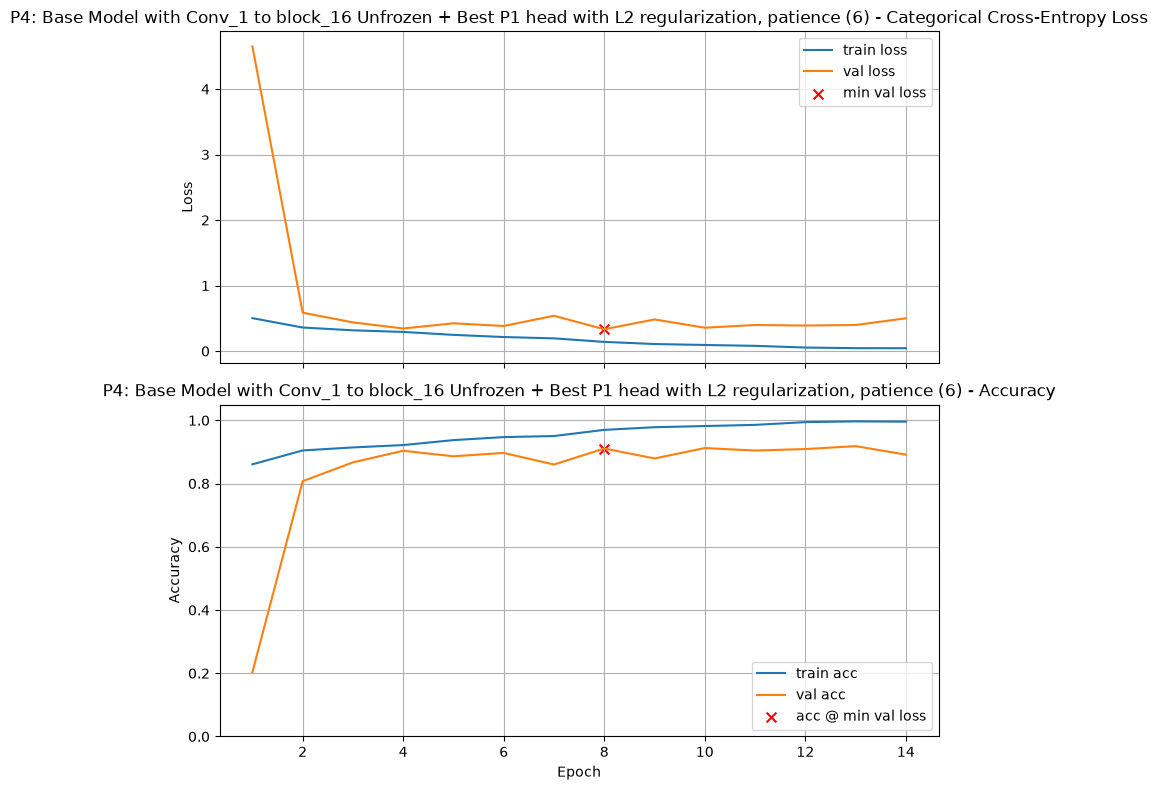

Final Training Loss:            0.0434
Final Training Accuracy:        0.9957
Final Validation Loss:          0.5000
Final Validation Accuracy:      0.8916
Minimum Validation Loss:        0.3328 (Epoch 8)
Validation Accuracy @ Min Loss: 0.9108

Test Loss: 0.3199
Test Accuracy: 0.9153

Validation-Test Gap (accuracy): 0.004492

Execution Time: 00:02:58


In [41]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod8 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod8.trainable = True

for layer in base_mod8.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model8 = models.Sequential([
    base_mod8,
    Dense(512, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128, kernel_regularizer=l2reg),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model8, patience=6, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with L2 regularization, patience (6)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with DO (0.45 -> 0.20)

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 61ms/step - accuracy: 0.8535 - loss: 0.4264 - val_accuracy: 0.3581 - val_loss: 6.1887 - learning_rate: 0.0010
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8990 - loss: 0.2941 - val_accuracy: 0.7033 - val_loss: 1.2037 - learning_rate: 0.0010
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9082 - loss: 0.2646 - val_accuracy: 0.7910 - val_loss: 0.7746 - learning_rate: 0.0010
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9229 - loss: 0.2231 - val_accuracy: 0.9037 - val_loss: 0.2936 - learning_rate: 0.0010
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9344 - loss: 0.1890 - val_accuracy: 0.9133 - val_loss: 0.2389 - learning_rate: 0.0010
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9470 - loss: 0.1619 - val_accuracy: 0.8374 - val_loss: 0.4833 - lear

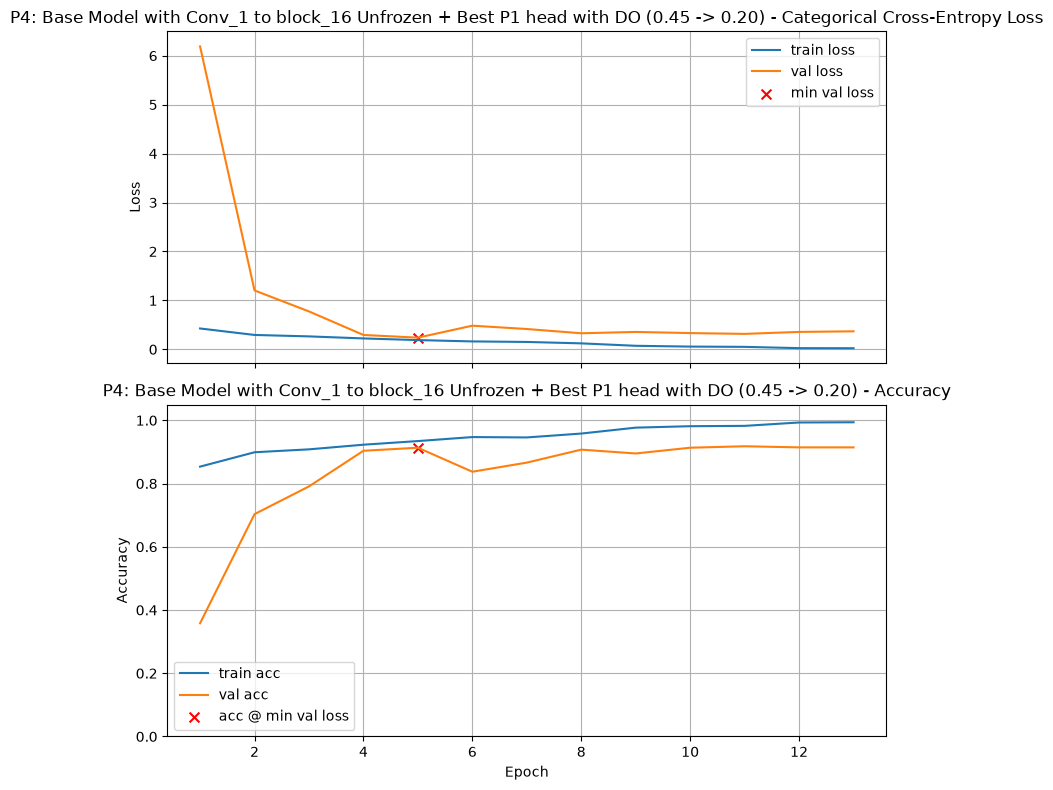

Final Training Loss:            0.0228
Final Training Accuracy:        0.9939
Final Validation Loss:          0.3683
Final Validation Accuracy:      0.9144
Minimum Validation Loss:        0.2389 (Epoch 5)
Validation Accuracy @ Min Loss: 0.9133

Test Loss: 0.2360
Test Accuracy: 0.9170

Validation-Test Gap (accuracy): 0.003662

Execution Time: 00:02:45


In [42]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod9 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod9.trainable = True

for layer in base_mod9.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model9 = models.Sequential([
    base_mod9,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.45),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model9, callbacks=[reduce_lr], title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with DO (0.45 -> 0.20)")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with no ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.8491 - loss: 0.4275 - val_accuracy: 0.7354 - val_loss: 0.7679
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9000 - loss: 0.2892 - val_accuracy: 0.6616 - val_loss: 1.2996
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9161 - loss: 0.2425 - val_accuracy: 0.8855 - val_loss: 0.3250
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.9286 - loss: 0.2092 - val_accuracy: 0.8738 - val_loss: 0.3978
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9333 - loss: 0.1929 - val_accuracy: 0.9130 - val_loss: 0.2534
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9490 - loss: 0.1520 - val_accuracy: 0.9173 - val_loss: 0.2443
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9550 - loss: 0.1309 - val_accuracy: 0.8688 - val_loss:

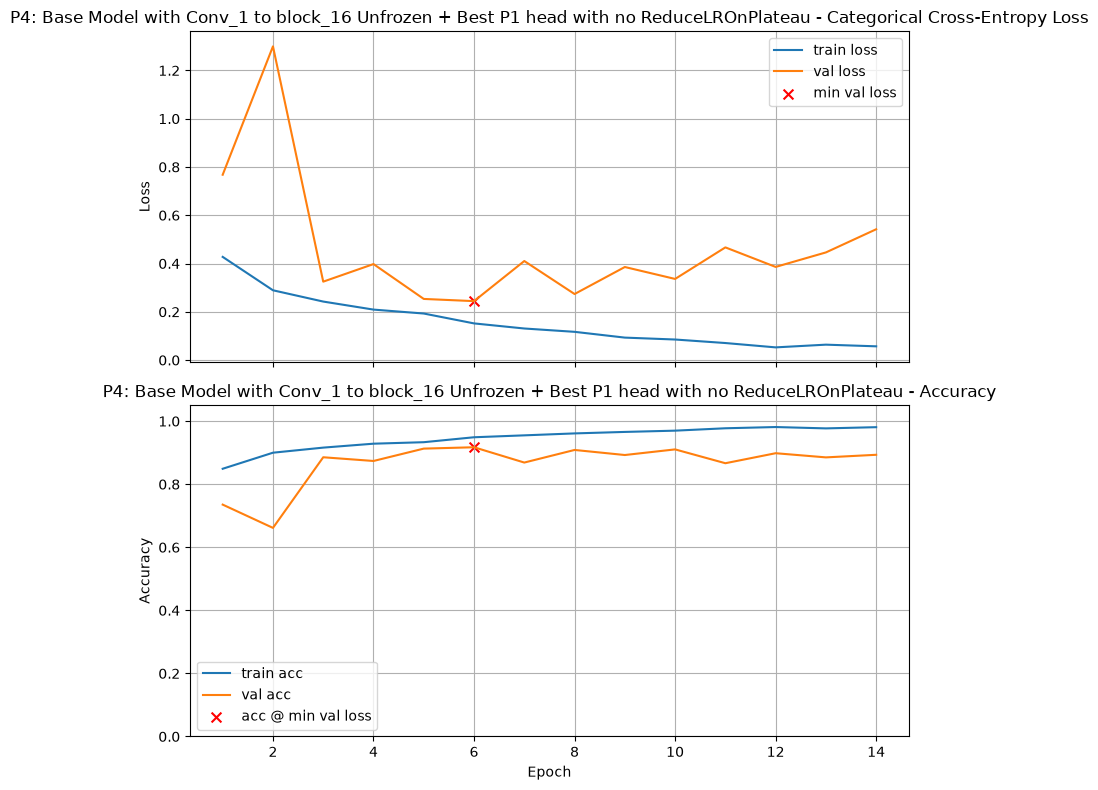

Final Training Loss:            0.0571
Final Training Accuracy:        0.9809
Final Validation Loss:          0.5420
Final Validation Accuracy:      0.8934
Minimum Validation Loss:        0.2443 (Epoch 6)
Validation Accuracy @ Min Loss: 0.9173

Test Loss: 0.2289
Test Accuracy: 0.9263

Validation-Test Gap (accuracy): 0.009072

Execution Time: 00:02:57


In [43]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod10 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod10.trainable = True

for layer in base_mod10.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model10 = models.Sequential([
    base_mod10,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.4),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model10, title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with no ReduceLROnPlateau")

/var/folders/n3/mxlkyfgd7jz62_nl3wrxbwrr0000gn/T/ipykernel_17478/3444387780.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = mobilenet_v2.MobileNetV2(



P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with DO (0.45 -> 0.20), no ReduceLROnPlateau

Epoch 1/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 27s 59ms/step - accuracy: 0.8476 - loss: 0.4424 - val_accuracy: 0.5389 - val_loss: 2.9716
Epoch 2/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8946 - loss: 0.3056 - val_accuracy: 0.6573 - val_loss: 1.0095
Epoch 3/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9138 - loss: 0.2513 - val_accuracy: 0.6466 - val_loss: 1.1334
Epoch 4/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9152 - loss: 0.2457 - val_accuracy: 0.8477 - val_loss: 0.4214
Epoch 5/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9246 - loss: 0.2167 - val_accuracy: 0.8951 - val_loss: 0.3025
Epoch 6/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9307 - loss: 0.2047 - val_accuracy: 0.7603 - val_loss: 0.6406
Epoch 7/500
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9308 - loss: 0.1953 - val_accuracy:

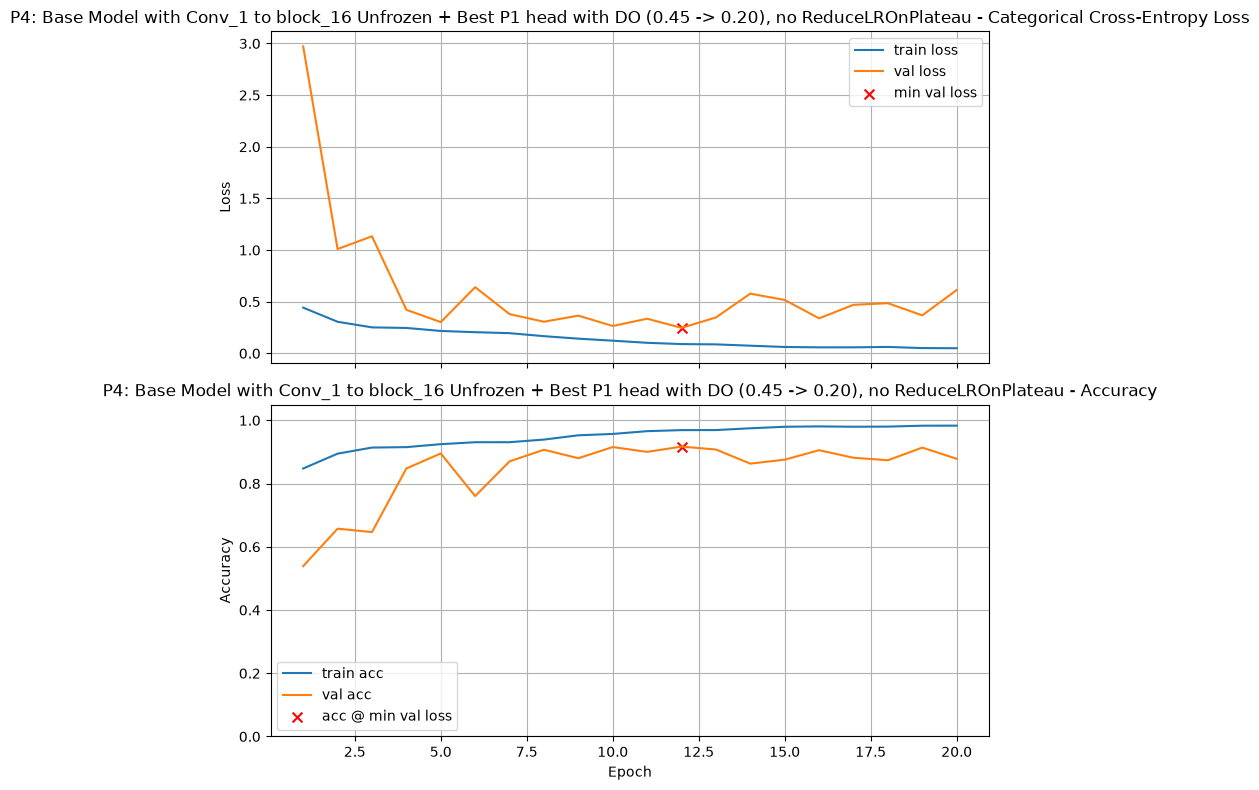

Final Training Loss:            0.0494
Final Training Accuracy:        0.9832
Final Validation Loss:          0.6130
Final Validation Accuracy:      0.8784
Minimum Validation Loss:        0.2466 (Epoch 12)
Validation Accuracy @ Min Loss: 0.9169

Test Loss: 0.2370
Test Accuracy: 0.9193

Validation-Test Gap (accuracy): 0.002429

Execution Time: 00:04:03


In [44]:
block_prefixes = [
    "block_1", "block_2", "block_3", "block_4",
    "block_5", "block_6", "block_7", "block_8",
    "block_9", "block_10", "block_11", "block_12",
    "block_13", "block_14", "block_15", "block_16",
    "Conv_1",   # final 1×1 convolution stage before pooling
]

K = 2

base_mod11 = make_base_model_pooled(trainable=False)

# Allow selected layers to be made trainable
base_mod11.trainable = True

for layer in base_mod11.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        # Often recommended to keep BN frozen during fine-tuning
        layer.trainable = False
    else:
        layer.trainable = any(
            layer.name.startswith(prefix)
            for prefix in block_prefixes[-K:]
        )

p4_model11 = models.Sequential([
    base_mod11,
    Dense(512),
    BatchNormalization(),
    ReLU(),
    Dropout(0.45),
    Dense(128),
    BatchNormalization(),
    ReLU(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')  # use your Intel num_classes (6)
])

train_and_test(p4_model11, title=f"P4: Base Model with {block_prefixes[-1]} to {block_prefixes[-K]} Unfrozen + Best P1 head with DO (0.45 -> 0.20), no ReduceLROnPlateau")

In [45]:
print_results()

P2: P1 best model (unfrozen base) - L2 reg, No Dropout	0.9269	22
P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau	0.9255	6
P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg	0.9240	7
P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg on Dense 512	0.9208	6
P2: P1 best model (unfrozen base) - LR (3e-5)	0.9205	6
P3: Base Model with Last 80 Layers Unfrozen + Best P1 head	0.9201	2
P2: P1 best model (unfrozen base)       	0.9201	4
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg, patience 3	0.9198	7
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512	0.9194	6
P3: Base Model with Last 20 Layers Unfrozen	0.9180	6
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head, Patience (3), LR (1e-5)	0.9180	19
P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with no ReduceLROnPlateau	0.9173	6
P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with DO (0.45 -> 0.20), no ReduceLROnPlateau

### Graded Questions

The reflection question is worth 5 points, and the validation accuracy question is worth 15 points. 

**Reflection Question:**

Which block-unfreezing configuration worked best for you, and what does that suggest about the effect of unfreezing the last \(K\) MobileNetV2 blocks?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Explain your reasoning in choosing your three experimental designs.
* Identify the experiment that performed best.
* Briefly compare it with the other experiments, referring to both architectural choices (especially the **number \(K\) of unfrozen blocks**, as well as dense layers or dropout) and training hyperparameters (e.g., learning rate, `ReduceLROnPlateau`).
* If you experimented with BatchNormalization, comment briefly on whether keeping BN frozen or allowing it to train appeared to help or destabilize training.
* Explain which differences you think were most important, based on the training and validation behavior you observed.
* Conclude with what your experiments suggest about selecting how many pretrained blocks to unfreeze during fine-tuning.



**Your paragraph here (5pts):**

> 

**Validation accuracy (15pts):**

In [46]:
# Set a4 to the validation accuracy found by your best model for this problem. 

a4 = results['P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with no ReduceLROnPlateau'][0]             # Replace 0.0 with your answer

In [47]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4 = {a4:.4f}') 

a4 = 0.9173


## Problem 5: Final Reflection

Run the next cell and consider all your experiments in this homework. 

This reflection question is worth 5 points. 

In [48]:
# Print out summary of validation accuracy for each experiment

print_results()

P2: P1 best model (unfrozen base) - L2 reg, No Dropout	0.9269	22
P2: P1 best model (unfrozen base) - LR (3e-5) no ReduceLROnPlateau	0.9255	6
P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg	0.9240	7
P2: P1 best model (unfrozen base) - LR (3e-5), L2 reg on Dense 512	0.9208	6
P2: P1 best model (unfrozen base) - LR (3e-5)	0.9205	6
P3: Base Model with Last 80 Layers Unfrozen + Best P1 head	0.9201	2
P2: P1 best model (unfrozen base)       	0.9201	4
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg, patience 3	0.9198	7
P2: P1 best model (unfrozen base) - LR (3e-5), no ReduceLROnPlateau, L2 reg on Dense 512	0.9194	6
P3: Base Model with Last 20 Layers Unfrozen	0.9180	6
P3: Base Model with Last 20 Layers Unfrozen + Best P1 head, Patience (3), LR (1e-5)	0.9180	19
P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with no ReduceLROnPlateau	0.9173	6
P4: Base Model with Conv_1 to block_16 Unfrozen + Best P1 head with DO (0.45 -> 0.20), no ReduceLROnPlateau

### Graded Question

### Final Reflection

Looking across the validation accuracies from your **full-dataset runs**, what patterns or lessons stand out from the different transfer-learning strategies you explored?

**Instructions:**

* Write a single paragraph (3–5 sentences).
* Compare the overall results from the frozen backbone, fully trainable backbone, partial layer unfreezing, and block-level unfreezing experiments.
* Highlight at least one design choice or training hyperparameter that appeared especially important.
* Mention any result that surprised you or differed from what you expected, if applicable.
* Conclude with a brief takeaway about what you learned about transfer learning from the homework.



**Your paragraph here (5pts):**

> Replace this sentence with your answer. 

## Appendix: What is MobileNetV2 (in plain English)?

`MobileNetV2` is a lightweight convolutional neural network (CNN) designed for efficient inference on resource-constrained devices while maintaining strong image-classification accuracy.

It achieves this with two important ideas:

1. **Depthwise-separable convolutions**

   Instead of using one expensive 3×3 convolution that mixes spatial information and channels at the same time, MobileNetV2 separates the operation into two steps:

   * a **depthwise 3×3 convolution**, which applies one spatial filter to each input channel separately, followed by
   * a **pointwise 1×1 convolution**, which mixes information across channels.

   This greatly reduces the number of parameters and computations compared with a standard convolution. ([arXiv][1])

2. **Inverted residual blocks with a linear bottleneck**

   A typical MobileNetV2 block has the following structure:

   * **Expand (1×1 convolution):** increase the number of channels, often by a factor of about 6, and apply a nonlinear activation.
   * **Depthwise (3×3 convolution):** process each channel separately and apply a nonlinear activation.
   * **Project (1×1 convolution):** reduce the number of channels again, but **without** applying a nonlinear activation. This is the **linear bottleneck**.

   If the input and output shapes match and the stride is 1, the block also adds a **skip connection**.

   The term **inverted residual** refers to the fact that the representation becomes wide inside the block and narrow again at the output, rather than the other way around.

   The final linear projection helps preserve information when the representation is compressed back to a lower-dimensional space. ([arXiv][1])

---

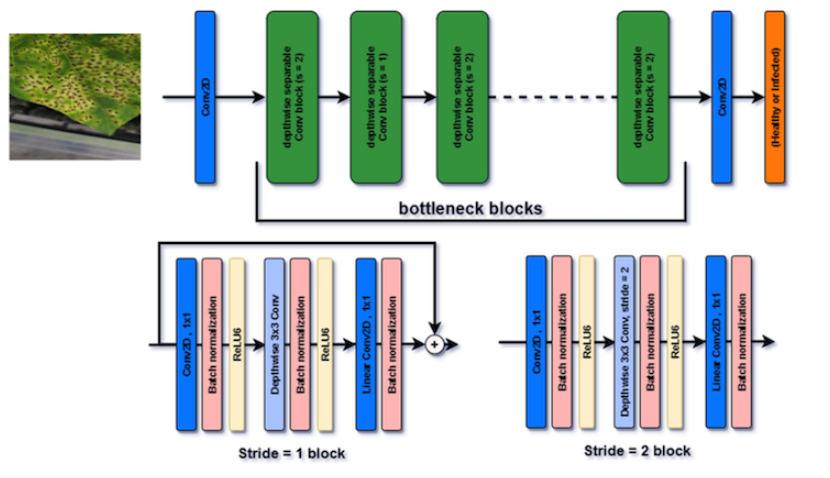

---

### What was MobileNetV2 trained on?

The Keras ImageNet weights for MobileNetV2 were trained on **ImageNet-1K**, a standard image-classification dataset containing:

* **1,281,167** training images
* **50,000** validation images
* **100,000** test images
* **1000 classes**

A common input size for MobileNetV2 is **224×224**. ([ImageNet][2])

For this homework, we use smaller **150×150** images to reduce training time.

Because we use:

```python
include_top=False
```

the pretrained convolutional backbone can operate on image sizes other than 224×224.

---

### Preprocessing

The preprocessing used for a pretrained network should match the preprocessing used when that network was originally trained.

For MobileNetV2, Keras provides:

```python
mobilenet_v2.preprocess_input
```

This function takes pixel values in their original approximately **0–255** range and scales them to approximately **[-1, 1]**.

In this homework, the image-loading pipeline applies this preprocessing before passing images to MobileNetV2. ([keras.io][3])

---

### How Keras exposes MobileNetV2

The following Keras call:

```python
tf.keras.applications.mobilenet_v2.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
```

returns a pretrained MobileNetV2 backbone with the original ImageNet classification head removed.

With:

```python
pooling="avg"
```

Keras applies **Global Average Pooling** to the final convolutional feature map. The result is a **1280-dimensional feature vector** for each image.

To use this backbone as a **frozen feature extractor**, we additionally set:

```python
base_model.trainable = False
```

The classification head that we add afterward can then be trained while the pretrained MobileNetV2 weights remain unchanged.

---

### What happens if `pooling="avg"` is omitted?

Without pooling, the backbone produces a spatial feature map rather than a single feature vector.

For a 224×224 input image, this feature map is typically:

```text
7 × 7 × 1280
```

Before connecting this to Dense layers, we would normally reduce the spatial dimensions using:

```python
GlobalAveragePooling2D()
```

which produces a 1280-dimensional vector.

`GlobalMaxPooling2D()` is another possible choice.

Using:

```python
Flatten()
```

is usually less attractive here because it would convert:

```text
7 × 7 × 1280
```

into:

```text
62,720
```

features, creating a much larger classification head.

In this homework, however, we use:

```python
pooling="avg"
```

inside MobileNetV2 itself, so **do not add another `GlobalAveragePooling2D()` layer**.

---

### How we use MobileNetV2 in this homework

We will experiment with several ways of using the pretrained backbone:

* **Frozen feature extraction:** keep all MobileNetV2 layers frozen and train only a new classification head.
* **Fully trainable backbone:** allow all MobileNetV2 layers to be updated during training.
* **Partial unfreezing:** keep most of the backbone frozen while allowing only selected upper layers or blocks to be updated.

These experiments let us investigate how much of the pretrained representation should be preserved and how much should be adapted to the Intel Image Classification dataset.

---

### TL;DR Summary

* Think of a MobileNetV2 block as:

  **expand → depthwise convolution → project (+ optional skip connection)**

* MobileNetV2 was pretrained to distinguish **1000 ImageNet classes**.

* In this homework, we reuse those learned visual features and train the model for our **6 Intel image classes**.

* With:

  ```python
  include_top=False,
  pooling="avg"
  ```

  the backbone outputs a **1280-D feature vector**.

* To use the backbone as a frozen feature extractor, set:

  ```python
  base_model.trainable = False
  ```

* Always match preprocessing to the pretrained backbone. For MobileNetV2, use:

  ```python
  mobilenet_v2.preprocess_input
  ```

  which scales the original pixel values to approximately **[-1, 1]**. ([keras.io][3])

---

### See also

* [https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/](https://www.analyticsvidhya.com/blog/2023/12/what-is-mobilenetv2/)

[1]: https://arxiv.org/abs/1801.04381
[2]: https://www.image-net.org/
[3]: https://keras.io/api/applications/mobilenet/mobilenet_models/


